# Supporting Figures A1–C2

Controlled-speed, eddy-SLP, and post-onset RWB robustness. Plotting functions are included in the notebook and executed directly.


In [1]:
from __future__ import annotations
import hashlib, importlib.metadata, io, json, math, os, re, shutil, sys, zipfile
from contextlib import redirect_stderr, redirect_stdout
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/james-mpl-cache")
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image as NotebookImage, SVG, display
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy import ndimage
from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.interpolate import interp1d

try:
    import cartopy.crs as ccrs
    HAVE_CARTOPY = True
except ImportError:
    HAVE_CARTOPY = False
try:
    import wavebreaking as wb
    HAVE_WAVEBREAKING = True
except ImportError:
    HAVE_WAVEBREAKING = False
try:
    from contrack import contrack as ConTrack
    HAVE_CONTRACK = True
except ImportError:
    HAVE_CONTRACK = False

def find_repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "ready_version").is_dir() and (candidate / "derived_data").is_dir():
            return candidate
    raise FileNotFoundError("Run from the repository or one of its subdirectories")

ROOT = find_repo_root()
RAW_DIR = ROOT
DERIVED_DIR = ROOT / "derived_data"
PUBLICATION_DIR = ROOT / "publication_notebooks"
FIGURE_DIR = PUBLICATION_DIR / "outputs"
TABLE_DIR = PUBLICATION_DIR / "outputs"
SI_DIR = ROOT / "paper_revision" / "supplemental_analysis"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RUN_HEAVY_PROCESSING = False
USE_PRECOMPUTED_DERIVED_DATA = True
SAVE_FIGURES = True
SHOW_FIGURES = False
REBUILD_FIGURES = os.environ.get(
    "PUBLICATION_REBUILD_FIGURES",
    os.environ.get("PUBLICATION_FULL_REBUILD", "1"),
) == "1"
FULL_REBUILD = REBUILD_FIGURES
EARTH_RADIUS_M = 6_371_229.0
EARTH_OMEGA = 7.2921e-5
GRAVITY = 9.80616
RD = 287.05
CP = 1004.0
KAPPA = RD / CP
mpl.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9})

def show_docx_media(docx_relative_path, members):
    members = [members] if isinstance(members, str) else list(members)
    with zipfile.ZipFile(ROOT / docx_relative_path) as archive:
        for member in members:
            payload = archive.read(member)
            display(SVG(data=payload.decode("utf-8")) if member.lower().endswith(".svg") else NotebookImage(data=payload))

def show_files(paths):
    paths = [paths] if isinstance(paths, str) else list(paths)
    for relative_path in paths:
        path = ROOT / relative_path
        if path.exists() and path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
            display(NotebookImage(filename=str(path)))

# Optional environment diagnostics are intentionally disabled in the public notebooks.
# print(f"Repository root: {ROOT.relative_to(ROOT)}")
# print(f"Rebuild figures: {REBUILD_FIGURES}")
# print(f"Cartopy={HAVE_CARTOPY}, WaveBreaking={HAVE_WAVEBREAKING}, ConTrack={HAVE_CONTRACK}")


## Figure A1

Original source: `eddy/controlled_umax30_bns_analysis_20260722/scripts/build_figure_a1_rwb_cross_sections.py`


In [2]:
# Consolidated from eddy/controlled_umax30_bns_analysis_20260722/scripts/build_figure_a1_rwb_cross_sections.py
REPO_ROOT = ROOT
__file__ = str(ROOT / 'eddy/controlled_umax30_bns_analysis_20260722/scripts/build_figure_a1_rwb_cross_sections.py')

import re
import warnings
from pathlib import Path
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
try:
    import netCDF4
except ImportError:
    netCDF4 = None
import numpy as np
import pandas as pd
ROOT = Path(__file__).resolve().parents[3]
OUT = ROOT / 'eddy' / 'controlled_umax30_bns_analysis_20260722'
UPPER_EVENTS = OUT / 'rwb_pressure_cross_sections' / 'case_events'
LOWER_EVENTS = OUT / 'rwb_theta_cross_sections' / 'lower_events'
EXTENDED_EVENTS = OUT / 'rwb_theta_cross_sections' / 'extended_events'
CONTROLLED_MANIFEST = ROOT / 'priority_revision_analysis_20260720' / 'simulations' / 'umax30_all_bns' / 'umax30_cases.csv'
CONTROLLED_SIMROOT = CONTROLLED_MANIFEST.parent
TABLES = OUT / 'tables'
FIGURES = OUT / 'figures'
PAIRED = TABLES / 'archive_vs_umax30_paired_responses.csv'
KAPPA = 287.05 / 1004.0
P0_HPA = 1000.0
G = 9.80665
EARTH_RADIUS = 6371000.0
OMEGA = 7.2921159e-05
PVU_FAC = 1e-06
B_VALUES = (1.0, 1.5, 2.0)
THETA_LEVELS = tuple(range(270, 381, 10))
THETA_GRID = np.arange(270.0, 381.0, 2.0)
THETA_BINS = np.arange(265.0, 386.0, 10.0)
THETA_CENTERS = 0.5 * (THETA_BINS[:-1] + THETA_BINS[1:])
LAT_BINS = np.arange(15.0, 75.1, 2.0)
LAT_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])
RESPONSES = (('peak_eke_m2s-2', 'archive_peak_eke_m2s-2', 'Peak EKE', 'm$^2$ s$^{-2}$'), ('post_onset_rwb_rate_per_hour', 'archive_post_onset_rwb_rate_per_hour', 'RWB rate', 'detections h$^{-1}$'), ('eddy_minus10_coalescence_count', 'archive_eddy_minus10_coalescence_count', 'Coalescence', 'events'), ('anticyclone_overlap_duration_hours', 'archive_anticyclone_overlap_duration_hours', 'Persistence', 'h'))

def original_manifest() -> pd.DataFrame:
    pattern = re.compile('^BCwave_b(?P<b>1|15|2)n(?P<n>1|3|6)(?:s(?P<s>-?\\d+))?\\.nc$')
    rows = []
    for path in sorted(ROOT.glob('BCwave_*.nc')):
        match = pattern.match(path.name)
        if match is None:
            continue
        rows.append({'archive': 'original', 'case': path.stem, 'b': 1.5 if match.group('b') == '15' else float(match.group('b')), 'n': int(match.group('n')), 's': int(match.group('s') or 0), 'source': str(path)})
    frame = pd.DataFrame(rows).sort_values(['b', 'n', 's']).reset_index(drop=True)
    if len(frame) != 45:
        raise RuntimeError(f'Expected 45 original cases, found {len(frame)}')
    return frame

def controlled_manifest() -> pd.DataFrame:
    frame = pd.read_csv(CONTROLLED_MANIFEST)[['case', 'b', 'n', 's']].copy()
    frame.insert(0, 'archive', 'controlled')
    frame['source'] = frame.case.map(lambda case: str(CONTROLLED_SIMROOT / case / 'atmos_4x_hourly.nc'))
    frame = frame.sort_values(['b', 'n', 's']).reset_index(drop=True)
    if len(frame) != 45:
        raise RuntimeError(f'Expected 45 controlled cases, found {len(frame)}')
    return frame

def load_events() -> pd.DataFrame:
    pieces = []
    inventory = []
    for archive in ('original', 'controlled'):
        upper_paths = sorted((UPPER_EVENTS / archive).glob('*.csv.gz'))
        lower_paths = sorted((LOWER_EVENTS / archive).glob('*.csv.gz'))
        extended_paths = sorted((EXTENDED_EVENTS / archive).glob('*.csv.gz'))
        if len(upper_paths) != 45 or len(lower_paths) != 45 or len(extended_paths) != 45:
            raise RuntimeError(f'Expected 45 upper, 45 lower, and 45 extended {archive} event files; found {len(upper_paths)}, {len(lower_paths)}, and {len(extended_paths)}')
        for source_group, paths in (('270-290K and 360-380K', extended_paths), ('300-310K', lower_paths), ('320-350K', upper_paths)):
            for path in paths:
                frame = pd.read_csv(path)
                if not frame.empty:
                    pieces.append(frame[['archive', 'case', 'b', 'n', 's', 'theta_k', 'time_hour', 'longitude_deg', 'latitude_deg', 'orientation']])
                in_domain = frame.latitude_deg.between(LAT_BINS[0], LAT_BINS[-1], inclusive='both') if not frame.empty else pd.Series(dtype=bool)
                inventory.append({'archive': archive, 'source_levels': source_group, 'case': path.name.removesuffix('.csv.gz'), 'total_events': len(frame), 'events_15_75n': int(in_domain.sum())})
    events = pd.concat(pieces, ignore_index=True)
    events = events[events.theta_k.isin(THETA_LEVELS)].copy()
    pd.DataFrame(inventory).to_csv(TABLES / 'A1_rwb_theta_event_inventory.csv', index=False)
    events.to_csv(TABLES / 'A1_rwb_theta_events_all.csv.gz', index=False, compression='gzip')
    domain = events[events.latitude_deg.between(LAT_BINS[0], LAT_BINS[-1], inclusive='both')].copy()
    summary = domain.groupby(['archive', 'b', 'theta_k', 'orientation'], as_index=False).agg(event_count=('case', 'size'), case_count=('case', 'nunique'), mean_latitude_deg=('latitude_deg', 'mean'))
    summary.to_csv(TABLES / 'A1_rwb_theta_event_summary.csv', index=False)
    return events

def filled(values) -> np.ndarray:
    return np.ma.filled(values, np.nan).astype(float)

def theta_from_t(temp: np.ndarray, plev_hpa: np.ndarray) -> np.ndarray:
    return temp * (P0_HPA / plev_hpa[:, None]) ** KAPPA

def central_p_gradient(values: np.ndarray, pressure_pa: np.ndarray) -> np.ndarray:
    output = np.empty_like(values, dtype=float)
    output[1:-1] = (values[2:] - values[:-2]) / (pressure_pa[2:, None] - pressure_pa[:-2, None])
    output[0] = (values[1] - values[0]) / (pressure_pa[1] - pressure_pa[0])
    output[-1] = (values[-1] - values[-2]) / (pressure_pa[-1] - pressure_pa[-2])
    return output

def central_lat_gradient(values: np.ndarray, latitude_rad: np.ndarray) -> np.ndarray:
    output = np.empty_like(values, dtype=float)
    output[:, 1:-1] = (values[:, 2:] - values[:, :-2]) / (latitude_rad[2:] - latitude_rad[:-2])
    output[:, 0] = (values[:, 1] - values[:, 0]) / (latitude_rad[1] - latitude_rad[0])
    output[:, -1] = (values[:, -1] - values[:, -2]) / (latitude_rad[-1] - latitude_rad[-2])
    return output

def zonal_mean_pv_pvu(u_zm: np.ndarray, temp_zm: np.ndarray, plev_hpa: np.ndarray, lat_deg: np.ndarray) -> np.ndarray:
    pressure_pa = np.asarray(plev_hpa, dtype=float) * 100.0
    latitude_rad = np.deg2rad(lat_deg)
    meridional_distance = EARTH_RADIUS * latitude_rad
    theta = theta_from_t(temp_zm, plev_hpa)
    dtheta_dp = np.gradient(theta, pressure_pa, axis=0, edge_order=2)
    dtheta_dy = np.gradient(theta, meridional_distance, axis=1, edge_order=2)
    du_dp = np.gradient(u_zm, pressure_pa, axis=0, edge_order=2)
    cosine_latitude = np.cos(latitude_rad)
    relative_vorticity = -(np.gradient(u_zm * cosine_latitude[None, :], latitude_rad, axis=1, edge_order=2) / (EARTH_RADIUS * cosine_latitude[None, :]))
    absolute_vorticity = 2.0 * OMEGA * np.sin(latitude_rad)[None, :] + relative_vorticity
    return -G * (absolute_vorticity * dtheta_dp + du_dp * dtheta_dy) / PVU_FAC

def pv_tropopause_theta(pv_pvu: np.ndarray, theta: np.ndarray, plev_hpa: np.ndarray, pv_target: float=2.0) -> np.ndarray:
    output = np.full(theta.shape[1], np.nan, dtype=float)
    for column in range(theta.shape[1]):
        pv_column = pv_pvu[:, column]
        theta_column = theta[:, column]
        valid = np.isfinite(pv_column) & np.isfinite(theta_column) & np.isfinite(plev_hpa)
        if valid.sum() >= 2:
            pv_column = pv_column[valid]
            theta_column = theta_column[valid]
            pressure_column = np.asarray(plev_hpa, dtype=float)[valid]
            difference = pv_column - pv_target
            candidates: list[tuple[float, float]] = []
            for index in range(len(difference) - 1):
                if np.isclose(difference[index], 0.0):
                    candidates.append((float(pressure_column[index]), float(theta_column[index])))
                elif difference[index] * difference[index + 1] < 0.0:
                    denominator = pv_column[index + 1] - pv_column[index]
                    weight = (pv_target - pv_column[index]) / denominator
                    crossing_pressure = pressure_column[index] + weight * (pressure_column[index + 1] - pressure_column[index])
                    crossing_theta = theta_column[index] + weight * (theta_column[index + 1] - theta_column[index])
                    candidates.append((float(crossing_pressure), float(crossing_theta)))
            if np.isclose(difference[-1], 0.0):
                candidates.append((float(pressure_column[-1]), float(theta_column[-1])))
            if candidates:
                output[column] = max(candidates, key=lambda candidate: candidate[0])[1]
    return output

def interp_column_to_theta(theta_column, value_column, plev_hpa, theta_targets):
    valid = np.isfinite(theta_column) & np.isfinite(value_column) & np.isfinite(plev_hpa)
    if valid.sum() < 2:
        return (np.full_like(theta_targets, np.nan), np.full_like(theta_targets, np.nan))
    theta_values = np.asarray(theta_column[valid], dtype=float)
    field_values = np.asarray(value_column[valid], dtype=float)
    pressure_values = np.asarray(plev_hpa[valid], dtype=float)
    order = np.argsort(theta_values)
    theta_values = theta_values[order]
    field_values = field_values[order]
    pressure_values = pressure_values[order]
    theta_values, unique_indices = np.unique(theta_values, return_index=True)
    field_values = field_values[unique_indices]
    pressure_values = pressure_values[unique_indices]
    valid_targets = (theta_targets >= theta_values.min()) & (theta_targets <= theta_values.max())
    output_field = np.full_like(theta_targets, np.nan, dtype=float)
    output_pressure = np.full_like(theta_targets, np.nan, dtype=float)
    output_field[valid_targets] = np.interp(theta_targets[valid_targets], theta_values, field_values)
    output_pressure[valid_targets] = np.exp(np.interp(theta_targets[valid_targets], theta_values, np.log(pressure_values)))
    return (output_field, output_pressure)

def read_case_initial(path: Path):
    with netCDF4.Dataset(path) as dataset:
        latitude = filled(dataset.variables['grid_yt'][:])
        plev = filled(dataset.variables['plev'][:])
        u = filled(dataset.variables['u_plev'][0]).mean(axis=-1)
        temp = filled(dataset.variables['t_plev'][0]).mean(axis=-1)
    if plev[0] > plev[-1]:
        plev = plev[::-1]
        u = u[::-1]
        temp = temp[::-1]
    theta = theta_from_t(temp, plev)
    pv = zonal_mean_pv_pvu(u, temp, plev, latitude)
    tropopause = pv_tropopause_theta(pv, theta, plev)
    u_theta = np.full((len(THETA_GRID), len(latitude)), np.nan)
    p_theta = np.full_like(u_theta, np.nan)
    for column in range(len(latitude)):
        u_theta[:, column], p_theta[:, column] = interp_column_to_theta(theta[:, column], u[:, column], plev, THETA_GRID)
    return (latitude, u_theta, p_theta, tropopause)

def build_environment(manifest: pd.DataFrame):
    environments = {}
    rows = []
    for archive in ('original', 'controlled'):
        for b_value in B_VALUES:
            subset = manifest[(manifest.archive == archive) & np.isclose(manifest.b, b_value)]
            if len(subset) != 15:
                raise RuntimeError(f'Expected 15 cases for {archive}, b={b_value}; found {len(subset)}')
            u_parts = []
            p_parts = []
            tropopause_parts = []
            latitude_reference = None
            for record in subset.itertuples(index=False):
                latitude, u_theta, p_theta, tropopause = read_case_initial(Path(record.source))
                if latitude_reference is None:
                    latitude_reference = latitude
                elif not np.allclose(latitude_reference, latitude):
                    raise RuntimeError(f'Latitude mismatch in {record.source}')
                u_parts.append(u_theta)
                p_parts.append(p_theta)
                tropopause_parts.append(tropopause)
            tropopause_stack = np.stack(tropopause_parts)
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', category=RuntimeWarning)
                u_theta_mean = np.nanmean(np.stack(u_parts), axis=0)
                p_theta_mean = np.nanmean(np.stack(p_parts), axis=0)
                tropopause_mean = np.nanmean(tropopause_stack, axis=0)
                tropopause_std = np.nanstd(tropopause_stack, axis=0)
            environment = {'latitude': latitude_reference, 'u_theta': u_theta_mean, 'p_theta': p_theta_mean, 'tropopause_mean': tropopause_mean, 'tropopause_std': tropopause_std}
            environments[archive, b_value] = environment
            for theta_index, theta_value in enumerate(THETA_GRID):
                for latitude_index, latitude_value in enumerate(latitude_reference):
                    rows.append({'archive': archive, 'b': b_value, 'theta_k': theta_value, 'latitude_deg': latitude_value, 'mean_u_ms-1': environment['u_theta'][theta_index, latitude_index], 'mean_pressure_hpa': environment['p_theta'][theta_index, latitude_index], 'tropopause_theta_mean_k': environment['tropopause_mean'][latitude_index], 'tropopause_theta_std_k': environment['tropopause_std'][latitude_index]})
    pd.DataFrame(rows).to_csv(TABLES / 'A1_initial_theta_environment.csv.gz', index=False, compression='gzip')
    return environments

def smooth_grid(grid: np.ndarray) -> np.ndarray:
    kernel = np.array([[0.06, 0.1, 0.06], [0.1, 0.36, 0.1], [0.06, 0.1, 0.06]])
    padded = np.pad(grid, ((1, 1), (1, 1)), mode='edge')
    output = np.zeros_like(grid, dtype=float)
    for row in range(grid.shape[0]):
        for column in range(grid.shape[1]):
            output[row, column] = np.sum(padded[row:row + 3, column:column + 3] * kernel)
    return output

def event_grid(events: pd.DataFrame, archive: str, b_value: float, orientation: str) -> np.ndarray:
    subset = events[(events.archive == archive) & np.isclose(events.b, b_value) & events.orientation.str.startswith(orientation) & events.latitude_deg.between(LAT_BINS[0], LAT_BINS[-1], inclusive='both')]
    histogram, _, _ = np.histogram2d(subset.theta_k, subset.latitude_deg, bins=(THETA_BINS, LAT_BINS))
    return smooth_grid(histogram / (15.0 * 15.0))

def add_density_contours(axis, grid: np.ndarray, color: str):
    maximum = float(np.nanmax(grid)) if grid.size else 0.0
    if maximum <= 0:
        return
    lower = max(0.3 * maximum, np.finfo(float).eps)
    levels = np.linspace(lower, maximum, 4)
    axis.contour(LAT_CENTERS, THETA_CENTERS, grid, levels=levels, colors=color, linewidths=1.45)

def make_cross_section_figure(events: pd.DataFrame, environments) -> None:
    figure = plt.figure(figsize=(9.25, 11.2))
    grid = figure.add_gridspec(4, 2, height_ratios=[1.0, 1.0, 1.0, 0.055], left=0.085, right=0.865, bottom=0.045, top=0.9, hspace=0.24, wspace=0.07)
    axes = np.empty((3, 2), dtype=object)
    for row in range(3):
        for column in range(2):
            axes[row, column] = figure.add_subplot(grid[row, column], sharex=axes[0, 0] if row or column else None, sharey=axes[0, 0] if row or column else None)
    legend_axis = figure.add_subplot(grid[3, :])
    legend_axis.axis('off')
    archives = (('original', 'Original archive'), ('controlled', 'Fixed $U_{max}=30$'))
    wind_levels = np.arange(0, 34, 2)
    pressure_levels = [100, 200, 300, 400, 500, 700, 850, 925]
    panel_labels = iter('abcdef')
    image = None
    density_rows = []
    for row, b_value in enumerate(B_VALUES):
        for column, (archive, archive_label) in enumerate(archives):
            axis = axes[row, column]
            environment = environments[archive, b_value]
            latitude = environment['latitude']
            latitude_mask = (latitude >= LAT_BINS[0]) & (latitude <= LAT_BINS[-1])
            latitude_plot = latitude[latitude_mask]
            image = axis.contourf(latitude_plot, THETA_GRID, environment['u_theta'][:, latitude_mask], levels=wind_levels, cmap='YlGnBu', extend='max')
            pressure = axis.contour(latitude_plot, THETA_GRID, environment['p_theta'][:, latitude_mask], levels=pressure_levels, colors='0.34', linestyles='--', linewidths=0.78)
            axis.clabel(pressure, fmt='%d', fontsize=6.2, inline=True)
            tropopause_mean = environment['tropopause_mean'][latitude_mask]
            tropopause_std = environment['tropopause_std'][latitude_mask]
            axis.fill_between(latitude_plot, tropopause_mean - tropopause_std, tropopause_mean + tropopause_std, color='black', alpha=0.08, linewidth=0, zorder=6)
            axis.plot(latitude_plot, tropopause_mean, color='black', linewidth=2.15, zorder=7)
            awb_grid = event_grid(events, archive, b_value, 'anti')
            cwb_grid = event_grid(events, archive, b_value, 'cyclo')
            add_density_contours(axis, awb_grid, '#d7301f')
            add_density_contours(axis, cwb_grid, '#2166ac')
            domain = events[(events.archive == archive) & np.isclose(events.b, b_value) & events.latitude_deg.between(LAT_BINS[0], LAT_BINS[-1], inclusive='both')]
            awb_count = int(domain.orientation.str.startswith('anti').sum())
            cwb_count = int(domain.orientation.str.startswith('cyclo').sum())
            axis.set_title(f'{archive_label}, $b={b_value:g}$\nAWB={awb_count:,}, CWB={cwb_count:,}', fontsize=9.2)
            axis.set_xlim(LAT_BINS[0], LAT_BINS[-1])
            axis.set_ylim(268, 382)
            axis.set_yticks([270, 280, 300, 320, 340, 360, 380])
            axis.tick_params(labelbottom=row == 2, labelleft=column == 0)
            axis.grid(True, alpha=0.16)
            axis.text(0.02, 0.96, next(panel_labels), transform=axis.transAxes, ha='left', va='top', weight='bold', fontsize=11)
            for theta_index, theta_center in enumerate(THETA_CENTERS):
                for latitude_index, latitude_center in enumerate(LAT_CENTERS):
                    density_rows.extend([{'archive': archive, 'b': b_value, 'orientation': 'anticyclonic', 'theta_center_k': theta_center, 'latitude_center_deg': latitude_center, 'detections_per_case_day': awb_grid[theta_index, latitude_index]}, {'archive': archive, 'b': b_value, 'orientation': 'cyclonic', 'theta_center_k': theta_center, 'latitude_center_deg': latitude_center, 'detections_per_case_day': cwb_grid[theta_index, latitude_index]}])
    for axis in axes[:, 0]:
        axis.set_ylabel('Isentropic level $\\theta$ (K)')
    for axis in axes[-1, :]:
        axis.set_xlabel('Latitude (deg N)')
    handles = [plt.Line2D([0], [0], color='#d7301f', lw=1.6, label='AWB density'), plt.Line2D([0], [0], color='#2166ac', lw=1.6, label='CWB density'), plt.Line2D([0], [0], color='black', lw=2.15, label='deepest initial 2-PVU branch'), plt.Line2D([0], [0], color='0.34', lw=0.9, linestyle='--', label='pressure contours (hPa)')]
    legend_axis.legend(handles=handles, loc='center', ncol=4, frameon=False, fontsize=8)
    colorbar_axis = figure.add_axes([0.89, 0.16, 0.025, 0.64])
    colorbar = figure.colorbar(image, cax=colorbar_axis)
    colorbar.set_label('Initial zonal wind on $\\theta$ surfaces (m s$^{-1}$)')
    figure.suptitle('RWB occurrence across $b$: original versus fixed jet strength', fontsize=14, weight='bold', y=0.975)
    figure.savefig(FIGURES / 'F1a_rwb_theta_lat_environment_by_b.png', dpi=320, bbox_inches='tight')
    figure.savefig(FIGURES / 'F1a_rwb_theta_lat_environment_by_b.pdf', bbox_inches='tight')
    plt.close(figure)
    pd.DataFrame(density_rows).to_csv(TABLES / 'A1_rwb_theta_lat_binned_rates.csv', index=False)

def group_mean_sem(frame: pd.DataFrame, parameter: str, value: float, column: str):
    values = frame[np.isclose(frame[parameter].astype(float), float(value))][column].dropna().astype(float)
    mean = float(values.mean())
    sem = float(values.std(ddof=1) / np.sqrt(len(values))) if len(values) > 1 else 0.0
    return (mean, sem)

def make_ns_figure(paired: pd.DataFrame) -> None:
    figure, axes = plt.subplots(4, 2, figsize=(9.25, 8.6), constrained_layout=True, sharey='row')
    colors = {'archive': '#555555', 'controlled': '#c43c2f'}
    labels = iter('abcdefgh')
    for column, (parameter, values) in enumerate((('n', [1, 3, 6]), ('s', [-10, -5, 0, 5, 10]))):
        positions = np.arange(len(values), dtype=float)
        for row, (controlled_name, archive_name, response_label, unit) in enumerate(RESPONSES):
            axis = axes[row, column]
            archive_stats = [group_mean_sem(paired, parameter, value, archive_name) for value in values]
            controlled_stats = [group_mean_sem(paired, parameter, value, controlled_name) for value in values]
            archive_mean, archive_sem = np.array(archive_stats).T
            controlled_mean, controlled_sem = np.array(controlled_stats).T
            axis.fill_between(positions, archive_mean - archive_sem, archive_mean + archive_sem, color=colors['archive'], alpha=0.1)
            axis.fill_between(positions, controlled_mean - controlled_sem, controlled_mean + controlled_sem, color=colors['controlled'], alpha=0.12)
            axis.plot(positions, archive_mean, 'o--', color=colors['archive'], linewidth=1.55, markersize=4.6, label='Original archive')
            axis.plot(positions, controlled_mean, 'o-', color=colors['controlled'], linewidth=1.7, markersize=4.6, label='Fixed $U_{max}=30$')
            axis.set_xticks(positions, [f'{value:g}' for value in values])
            axis.set_ylabel(f'{response_label}\n({unit})', fontsize=8.7)
            axis.tick_params(axis='y', labelleft=True)
            axis.grid(axis='y', alpha=0.2)
            axis.spines[['top', 'right']].set_visible(False)
            axis.text(0.01, 0.97, next(labels), transform=axis.transAxes, ha='left', va='top', weight='bold')
            if row == 0:
                axis.set_title(f'Group means by ${parameter}$', fontsize=11)
            if row == 3:
                axis.set_xlabel(f'${parameter}$')
    figure.legend(*axes[0, 0].get_legend_handles_labels(), loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.015))
    figure.suptitle('Response relationships across $n$ and $s$', fontsize=14, weight='bold', y=1.04)
    figure.savefig(FIGURES / 'F1b_original_vs_controlled_ns_group_means.png', dpi=320, bbox_inches='tight')
    figure.savefig(FIGURES / 'F1b_original_vs_controlled_ns_group_means.pdf', bbox_inches='tight')
    plt.close(figure)

def main() -> None:
    TABLES.mkdir(parents=True, exist_ok=True)
    FIGURES.mkdir(parents=True, exist_ok=True)
    events = load_events()
    manifest = pd.concat([original_manifest(), controlled_manifest()], ignore_index=True)
    environments = build_environment(manifest)
    make_cross_section_figure(events, environments)
    make_ns_figure(pd.read_csv(PAIRED))
    print(FIGURES / 'F1a_rwb_theta_lat_environment_by_b.png')
    print(FIGURES / 'F1b_original_vs_controlled_ns_group_means.png')


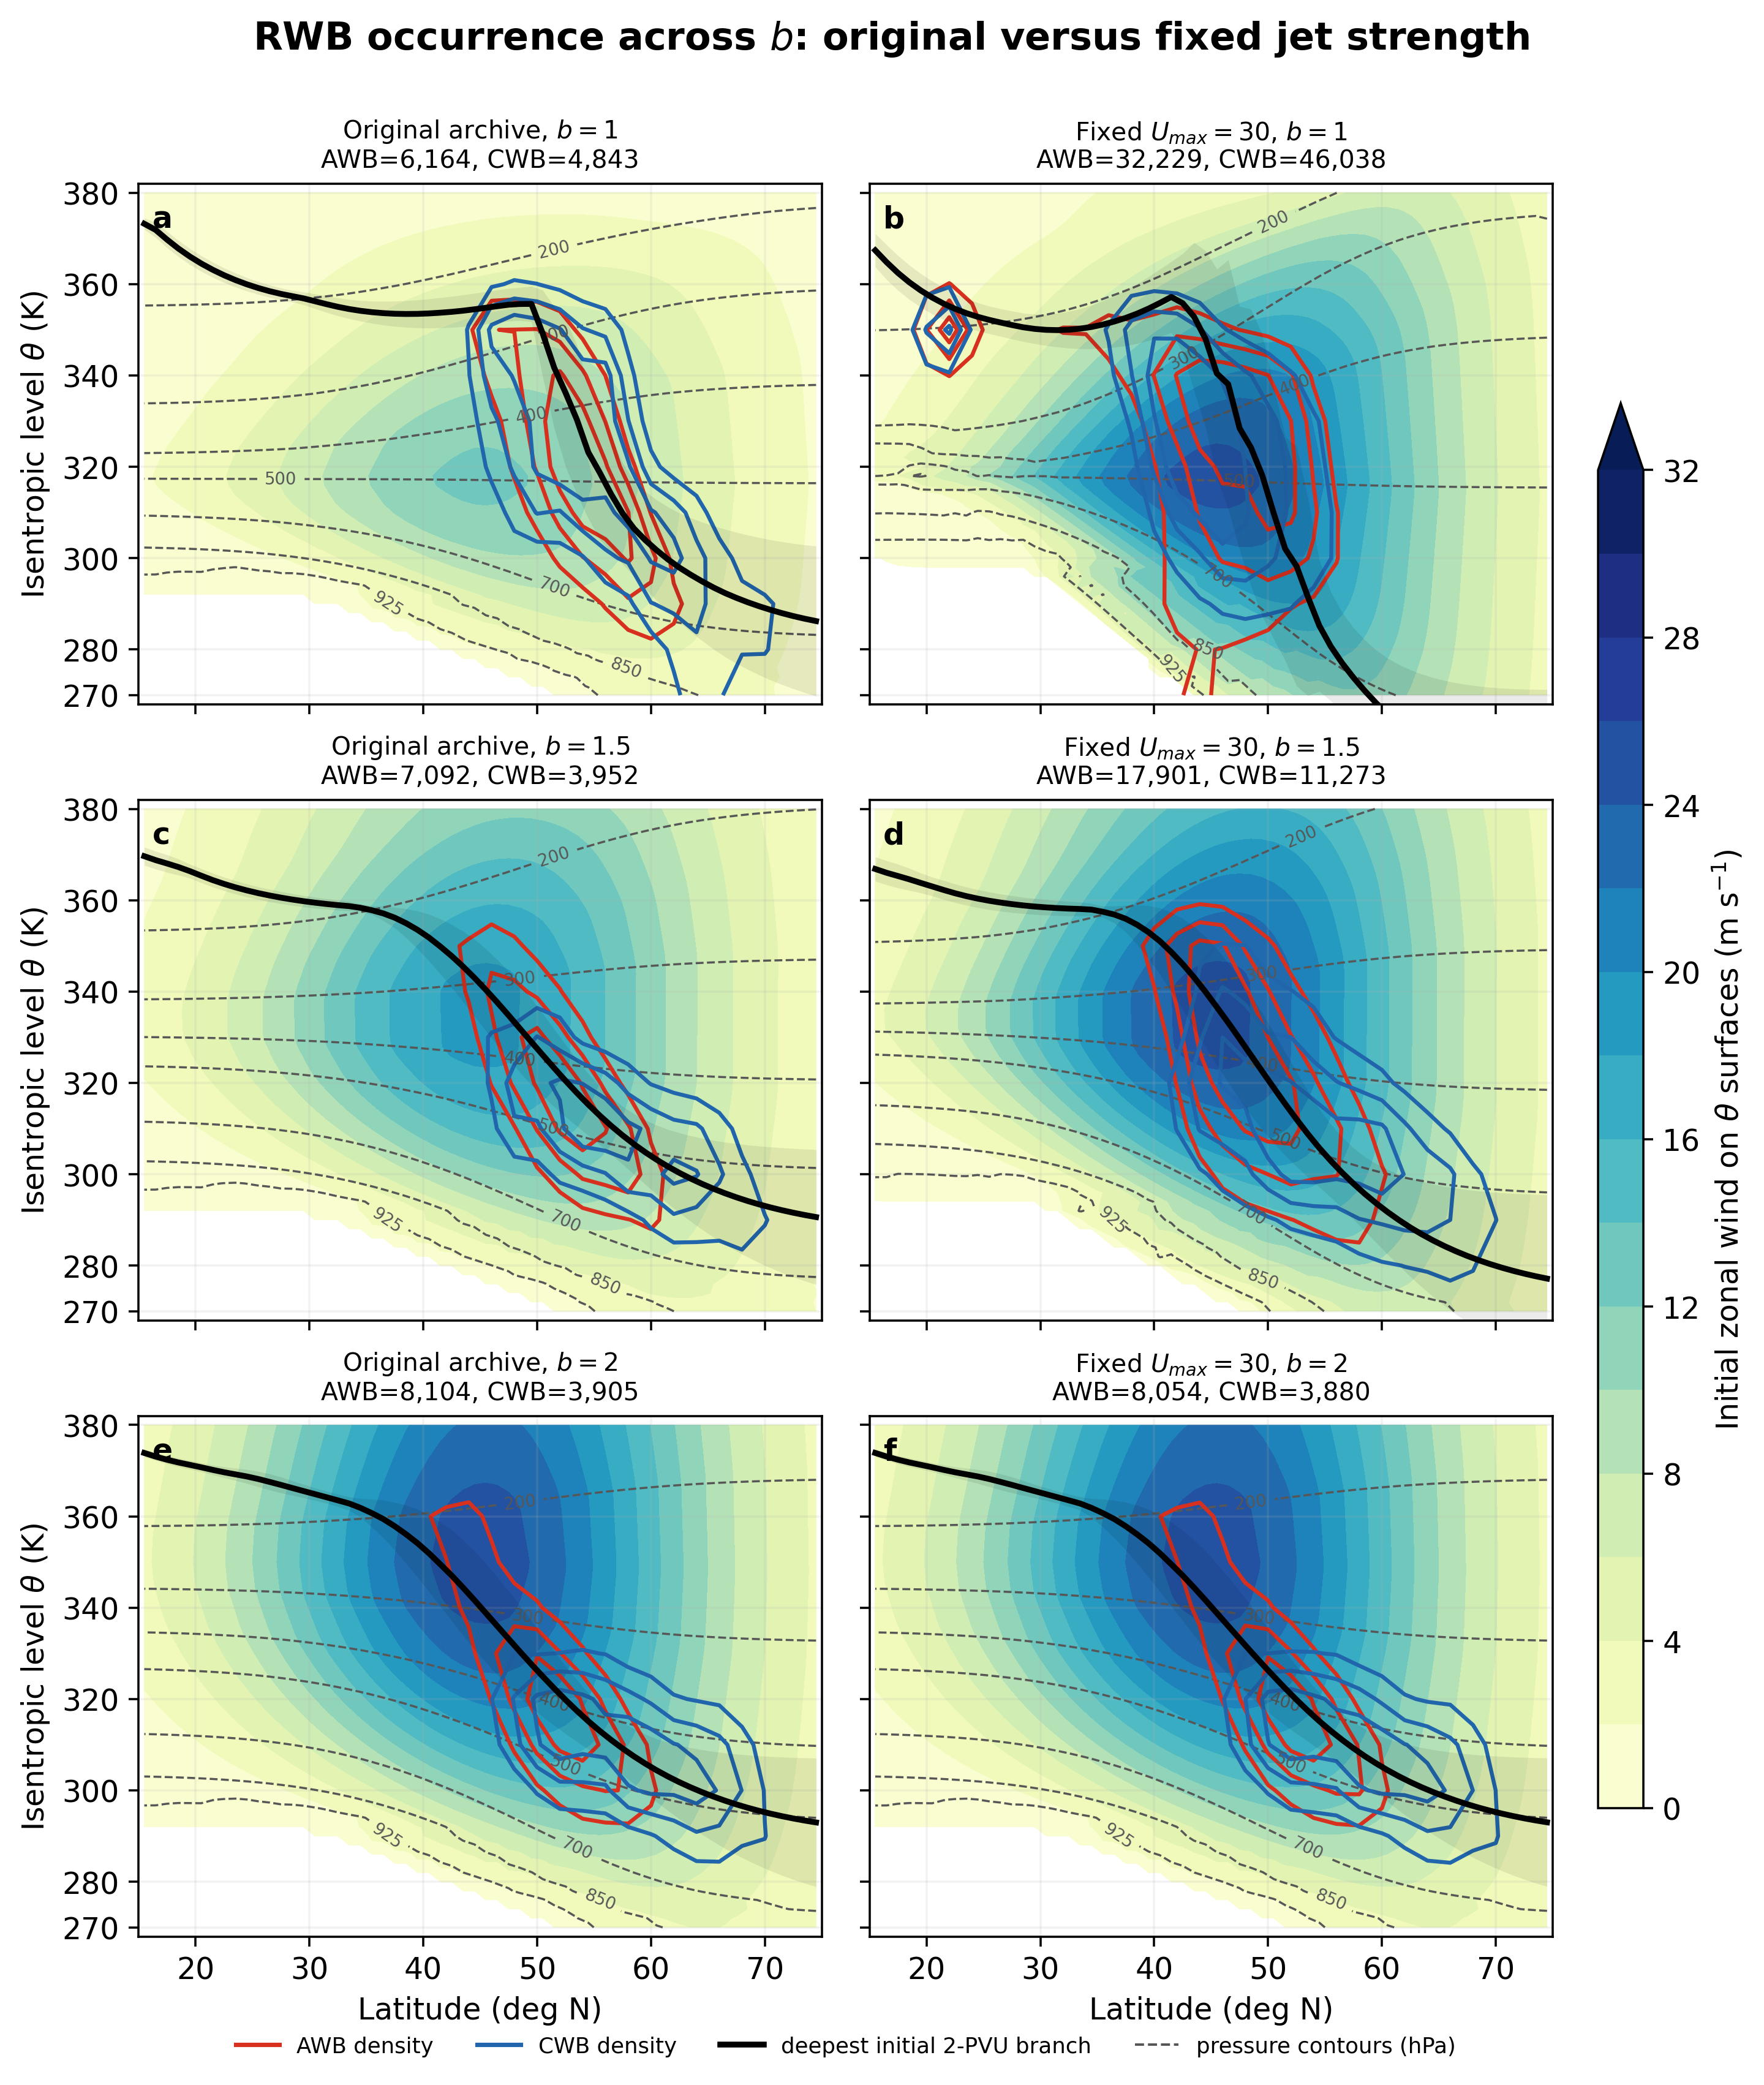

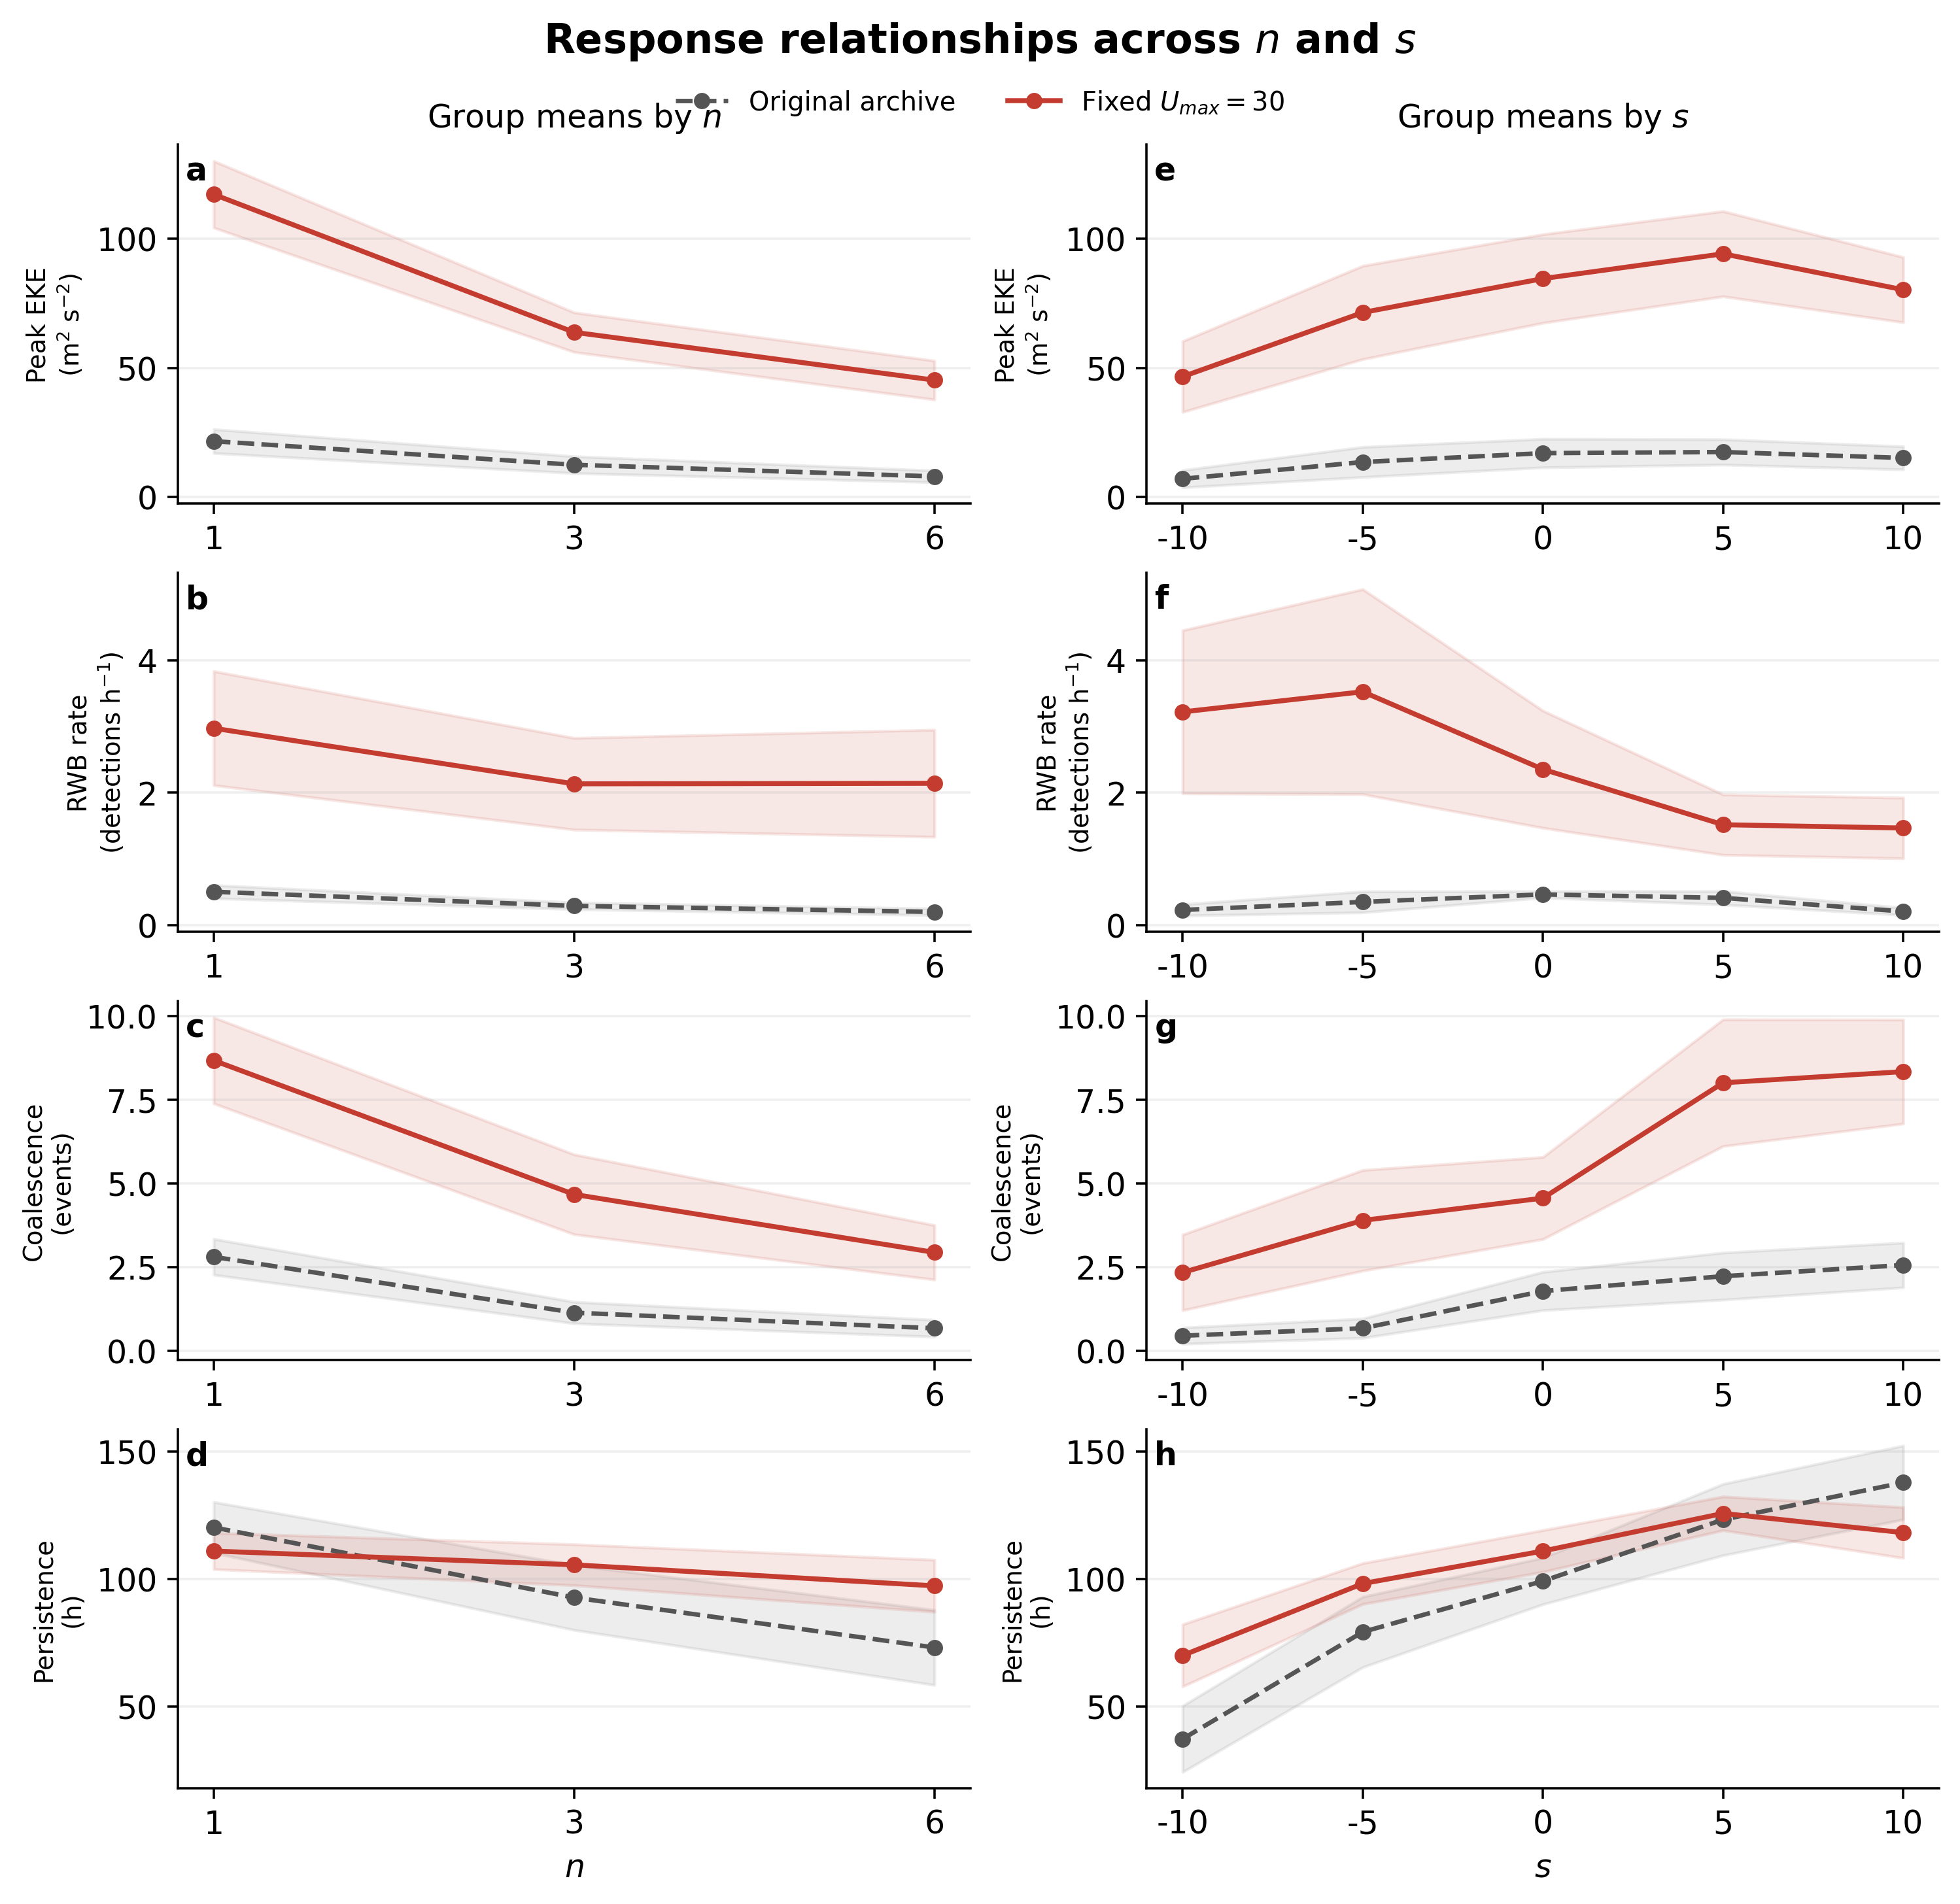

In [3]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            main()
finally:
    sys.argv = _original_argv
show_files(['eddy/controlled_umax30_bns_analysis_20260722/figures/F1a_rwb_theta_lat_environment_by_b.png', 'eddy/controlled_umax30_bns_analysis_20260722/figures/F1b_original_vs_controlled_ns_group_means.png'])


## Figures A2–A4

Original source: `eddy/controlled_umax30_bns_analysis_20260722/scripts/build_umax30_all45_section_f.py`


In [4]:
# Consolidated from eddy/controlled_umax30_bns_analysis_20260722/scripts/build_umax30_all45_section_f.py
REPO_ROOT = ROOT
__file__ = str(ROOT / 'eddy/controlled_umax30_bns_analysis_20260722/scripts/build_umax30_all45_section_f.py')

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
ROOT = Path(__file__).resolve().parents[3]
OUT = ROOT / 'eddy' / 'controlled_umax30_bns_analysis_20260722'
FIGURES = OUT / 'figures'
TABLES = OUT / 'tables'
REFERENCE = ROOT / 'eddy' / 'Supplementary_Material_AGU_Manuscript_FV3_Mingfei_final.docx'
PARAMETERS = [('b', [1, 1.5, 2]), ('n', [1, 3, 6]), ('s', [-10, -5, 0, 5, 10])]
RESPONSES = [('peak_eke_m2s-2', 'archive_peak_eke_m2s-2', 'Peak EKE', 'm$^2$ s$^{-2}$'), ('post_onset_rwb_rate_per_hour', 'archive_post_onset_rwb_rate_per_hour', 'RWB rate', 'detections h$^{-1}$'), ('eddy_minus10_coalescence_count', 'archive_eddy_minus10_coalescence_count', 'Coalescence', 'events'), ('anticyclone_overlap_duration_hours', 'archive_anticyclone_overlap_duration_hours', 'Persistence', 'h')]

def classify(original: float, controlled: float) -> str:
    original_clear = abs(original) >= 0.2
    controlled_clear = abs(controlled) >= 0.2
    if original_clear and controlled_clear and (np.sign(original) == np.sign(controlled)):
        return 'direction retained'
    if original_clear and (not controlled_clear):
        return 'weakened after strength control'
    if original_clear and controlled_clear:
        return 'direction reversed'
    if not original_clear and controlled_clear:
        return 'emerges after strength control'
    return 'weak in both ensembles'

def summarize(paired: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    correlations = []
    grouped = []
    for parameter, values in PARAMETERS:
        for controlled_name, archive_name, label, _ in RESPONSES:
            valid = paired[archive_name].notna()
            original_rho, original_p = spearmanr(paired.loc[valid, parameter], paired.loc[valid, archive_name])
            controlled_rho, controlled_p = spearmanr(paired[parameter], paired[controlled_name])
            correlations.append({'parameter': parameter, 'response': label, 'archive_rho': original_rho, 'archive_p': original_p, 'archive_n': int(valid.sum()), 'controlled_rho': controlled_rho, 'controlled_p': controlled_p, 'controlled_n': len(paired), 'classification': classify(original_rho, controlled_rho)})
        for value in values:
            subset = paired[np.isclose(paired[parameter].astype(float), float(value))]
            row = {'parameter': parameter, 'value': value, 'n_cases': len(subset)}
            for controlled_name, archive_name, label, _ in RESPONSES:
                key = label.lower().replace(' ', '_')
                row[f'archive_{key}'] = subset[archive_name].mean()
                row[f'controlled_{key}'] = subset[controlled_name].mean()
            grouped.append(row)
    return (pd.DataFrame(correlations), pd.DataFrame(grouped))

def make_heatmaps(controlled: pd.DataFrame) -> None:
    s_values = [-10, -5, 0, 5, 10]
    b_values = [2, 1.5, 1]
    n_values = [1, 3, 6]
    figure, axes = plt.subplots(4, 5, figsize=(12.5, 9.5), constrained_layout=True)
    for row, (name, _, label, _) in enumerate(RESPONSES):
        arrays = []
        for s_value in s_values:
            arrays.append(controlled[np.isclose(controlled.s, s_value)].pivot(index='b', columns='n', values=name).reindex(index=b_values, columns=n_values).to_numpy(float))
        finite = np.concatenate([array[np.isfinite(array)] for array in arrays])
        vmin, vmax = (float(finite.min()), float(finite.max()))
        for column, (s_value, array) in enumerate(zip(s_values, arrays)):
            axis = axes[row, column]
            image = axis.imshow(array, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
            for i in range(3):
                for j in range(3):
                    value = array[i, j]
                    fraction = 0.5 if vmax == vmin else (value - vmin) / (vmax - vmin)
                    text = f'{value:.2f}' if label in {'Peak EKE', 'RWB rate'} else f'{value:.0f}'
                    axis.text(j, i, text, ha='center', va='center', fontsize=7, color='white' if fraction < 0.35 else 'black')
            if row == 0:
                axis.set_title(f'$s={s_value:g}°$')
            axis.set_xticks(range(3), n_values if row == 3 else [])
            axis.set_yticks(range(3), [f'{value:g}' for value in b_values] if column == 0 else [])
            if row == 3:
                axis.set_xlabel('$n$')
            if column == 0:
                axis.set_ylabel(f'{label}\n$b$')
            figure.colorbar(image, ax=axis, shrink=0.68, pad=0.02)
    figure.suptitle('Case-level responses in the 45-member fixed-$U_{max}$ ensemble', fontsize=13)
    figure.savefig(FIGURES / 'F2_controlled_all45_heatmaps.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'F2_controlled_all45_heatmaps.pdf', bbox_inches='tight')
    plt.close(figure)

def make_paired_figure(paired: pd.DataFrame) -> None:
    figure, axes = plt.subplots(2, 2, figsize=(9, 7.5), constrained_layout=True)
    colors = {-10: '#313695', -5: '#74add1', 0: '#fdae61', 5: '#f46d43', 10: '#a50026'}
    markers = {1: 'o', 3: 's', 6: '^'}
    for axis, (controlled_name, archive_name, label, _) in zip(axes.flat, RESPONSES):
        subset = paired[paired[archive_name].notna() & paired[controlled_name].notna()]
        for _, record in subset.iterrows():
            axis.scatter(record[archive_name], record[controlled_name], color=colors[int(record.s)], marker=markers[int(record.n)], s=44 + 22 * (record.b - 1), edgecolor='black', linewidth=0.35)
        lower = min(subset[archive_name].min(), subset[controlled_name].min())
        upper = max(subset[archive_name].max(), subset[controlled_name].max())
        margin = 0.06 * max(upper - lower, 1)
        axis.plot([lower - margin, upper + margin], [lower - margin, upper + margin], '--', color='#777777')
        axis.set_xlabel('Original archive')
        axis.set_ylabel('Fixed $U_{max}=30$')
        axis.set_title(label)
        axis.grid(alpha=0.2)
    figure.suptitle('Paired response changes for matching $(b,n,s)$ cases', fontsize=13)
    figure.savefig(FIGURES / 'F3_archive_controlled_paired.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'F3_archive_controlled_paired.pdf', bbox_inches='tight')
    plt.close(figure)

def make_correlation_figure(correlations: pd.DataFrame) -> None:
    labels = [item[2] for item in RESPONSES]
    figure, axes = plt.subplots(1, 3, figsize=(11.2, 4.2), sharey=True, constrained_layout=True)
    positions = np.arange(len(labels))
    for axis, (parameter, _) in zip(axes, PARAMETERS):
        subset = correlations[correlations.parameter.eq(parameter)].set_index('response').reindex(labels)
        axis.bar(positions - 0.18, subset.archive_rho, 0.36, color='#777777', label='Original archive')
        axis.bar(positions + 0.18, subset.controlled_rho, 0.36, color='#d62728', label='Fixed $U_{max}=30$')
        axis.axhline(0, color='black', linewidth=0.8)
        axis.set_xticks(positions, labels, rotation=30, ha='right')
        axis.set_ylim(-1, 1)
        axis.set_title(f'Association with ${parameter}$')
        axis.grid(axis='y', alpha=0.22)
    axes[0].set_ylabel('Spearman $\\rho$')
    axes[0].legend(frameon=False, fontsize=8)
    figure.suptitle('Parameter-response relationships before and after strength control', fontsize=13)
    figure.savefig(FIGURES / 'F4_parameter_spearman_comparison.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'F4_parameter_spearman_comparison.pdf', bbox_inches='tight')
    plt.close(figure)

def build_figures_a2_a4():
    FIGURES.mkdir(parents=True, exist_ok=True)
    TABLES.mkdir(parents=True, exist_ok=True)
    paired = pd.read_csv(TABLES / 'archive_vs_umax30_paired_responses.csv').sort_values(['b', 'n', 's'])
    controlled = pd.read_csv(TABLES / 'umax30_all45_headline_responses.csv').sort_values(['b', 'n', 's'])
    if len(paired) != 45 or len(controlled) != 45 or paired[['b', 'n', 's']].duplicated().any():
        raise RuntimeError('The complete 45-case matrix is not available')
    correlations, grouped = summarize(paired)
    correlations.to_csv(TABLES / 'F1_archive_controlled_parameter_correlations.csv', index=False)
    grouped.to_csv(TABLES / 'F2_archive_controlled_group_means.csv', index=False)
    make_heatmaps(controlled)
    make_paired_figure(paired)
    make_correlation_figure(correlations)
    return [
        FIGURES / 'F2_controlled_all45_heatmaps.png',
        FIGURES / 'F3_archive_controlled_paired.png',
        FIGURES / 'F4_parameter_spearman_comparison.png',
    ]


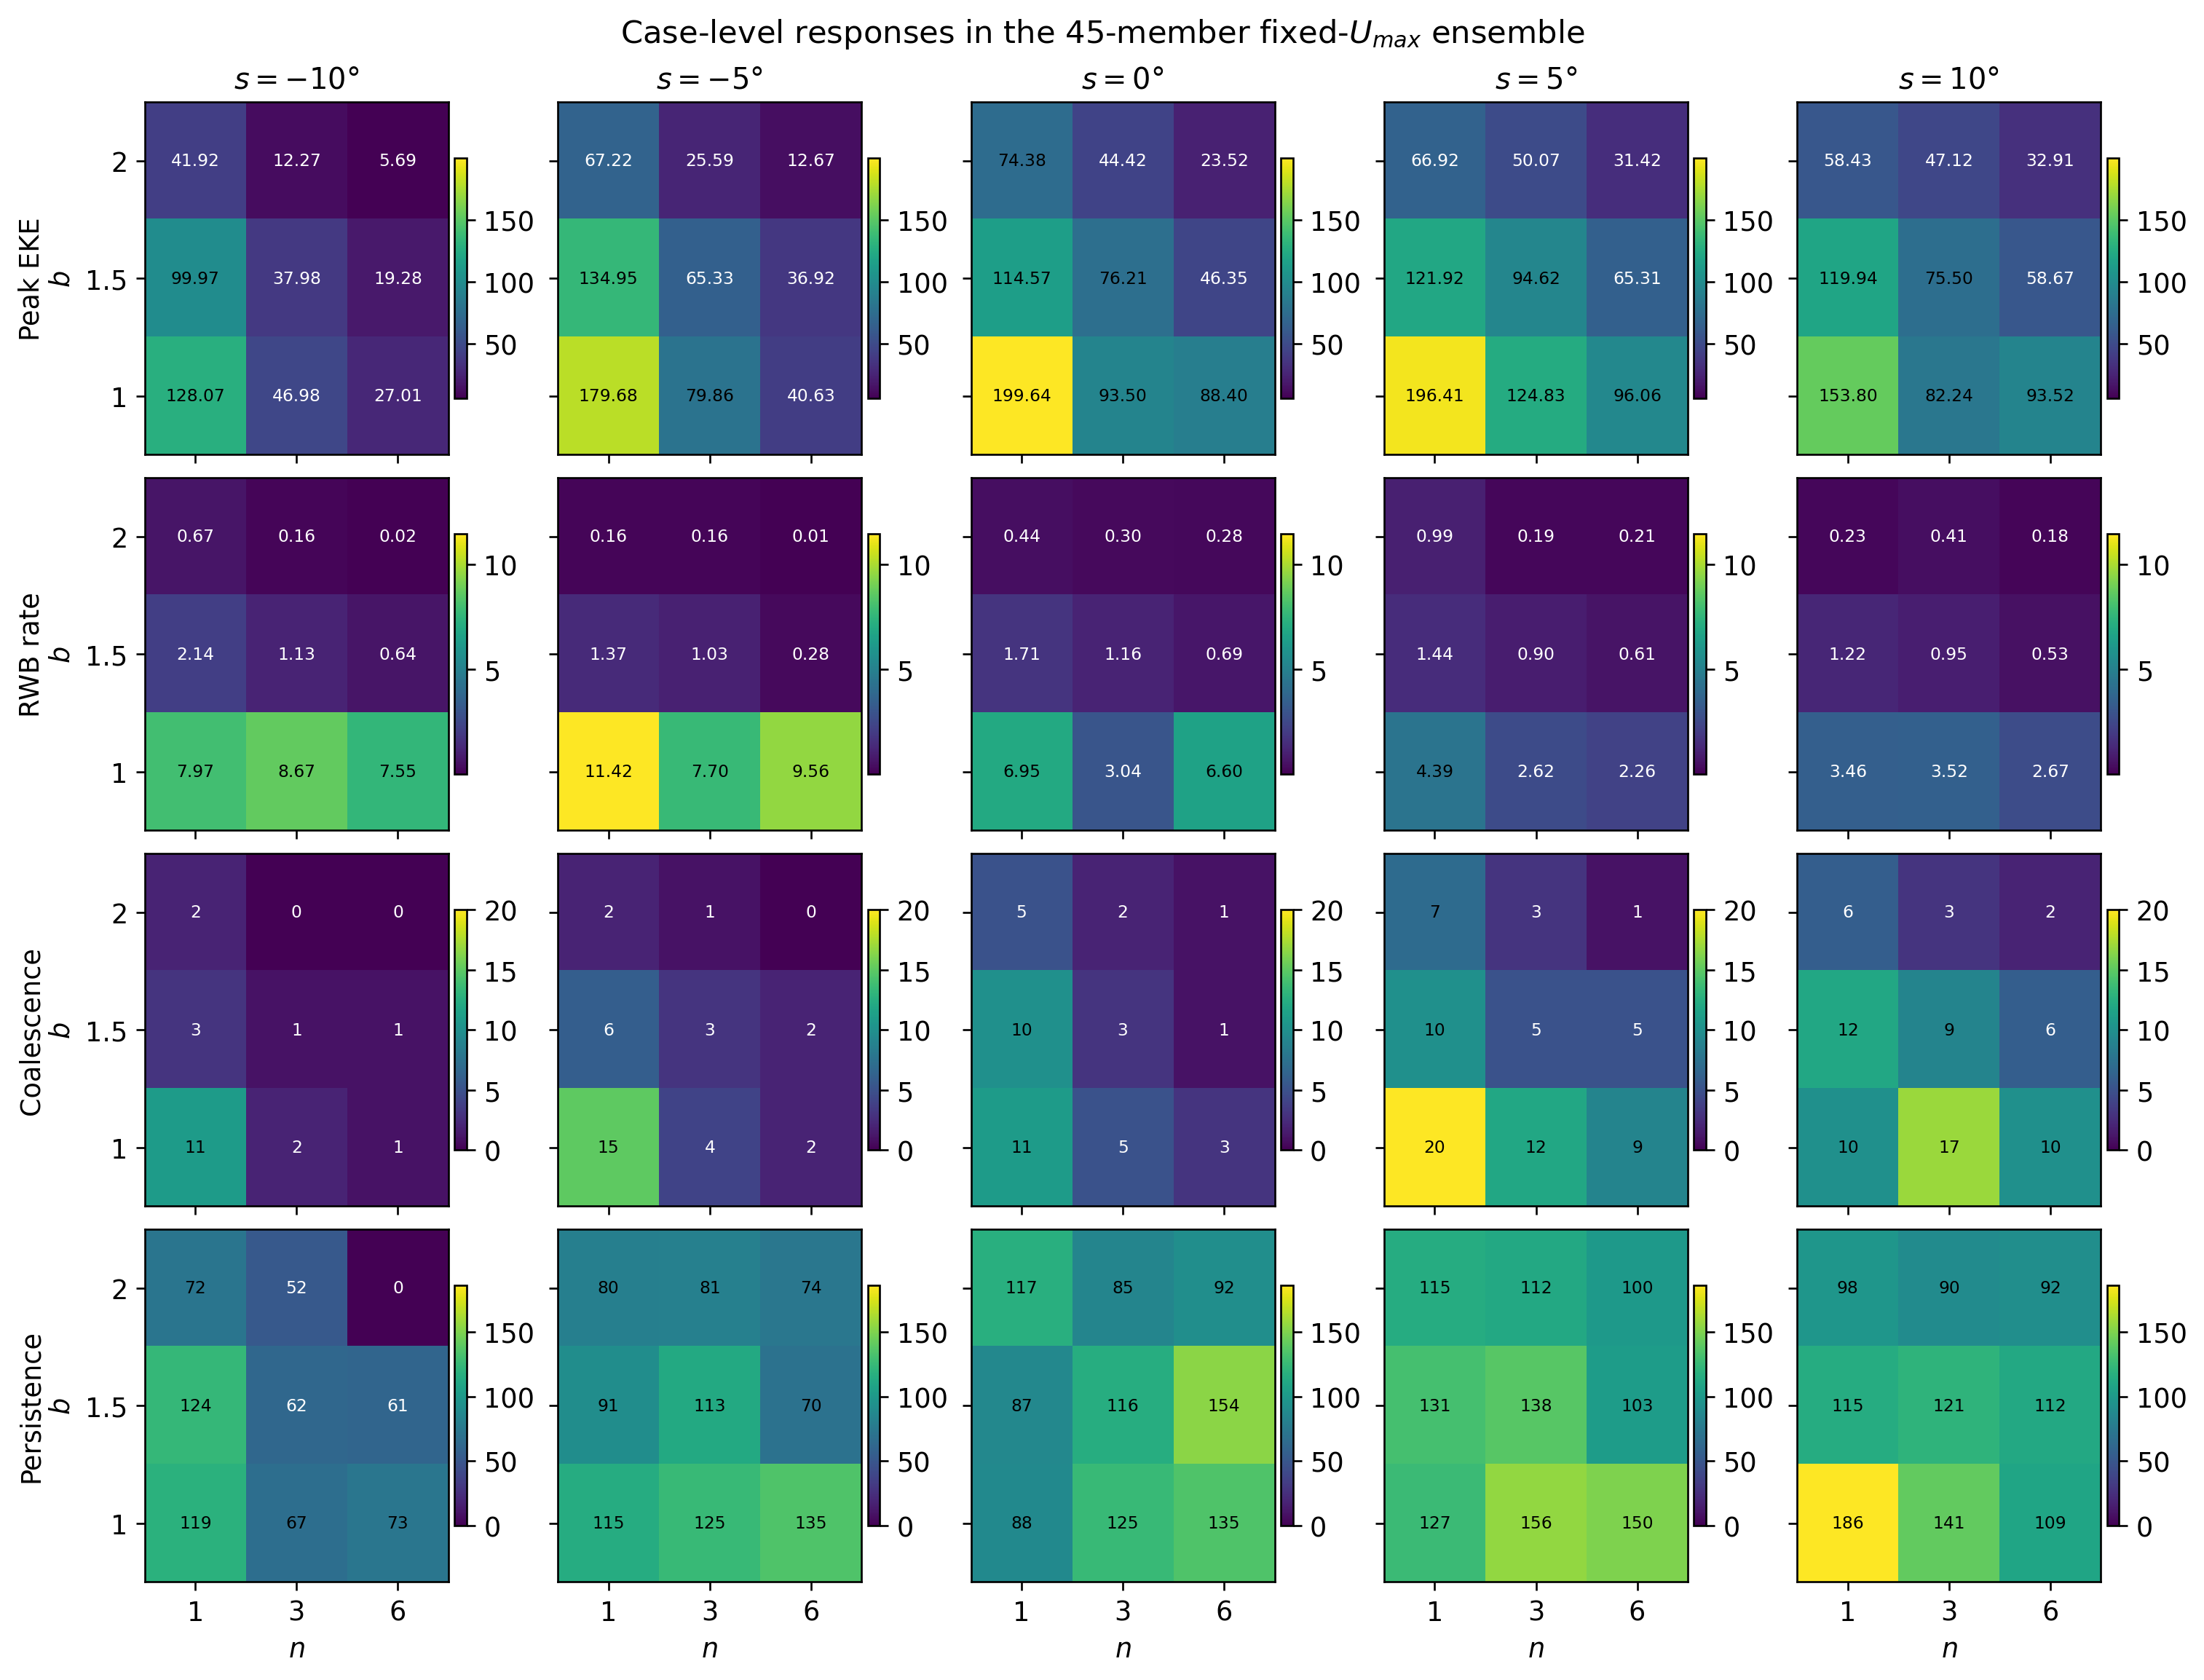

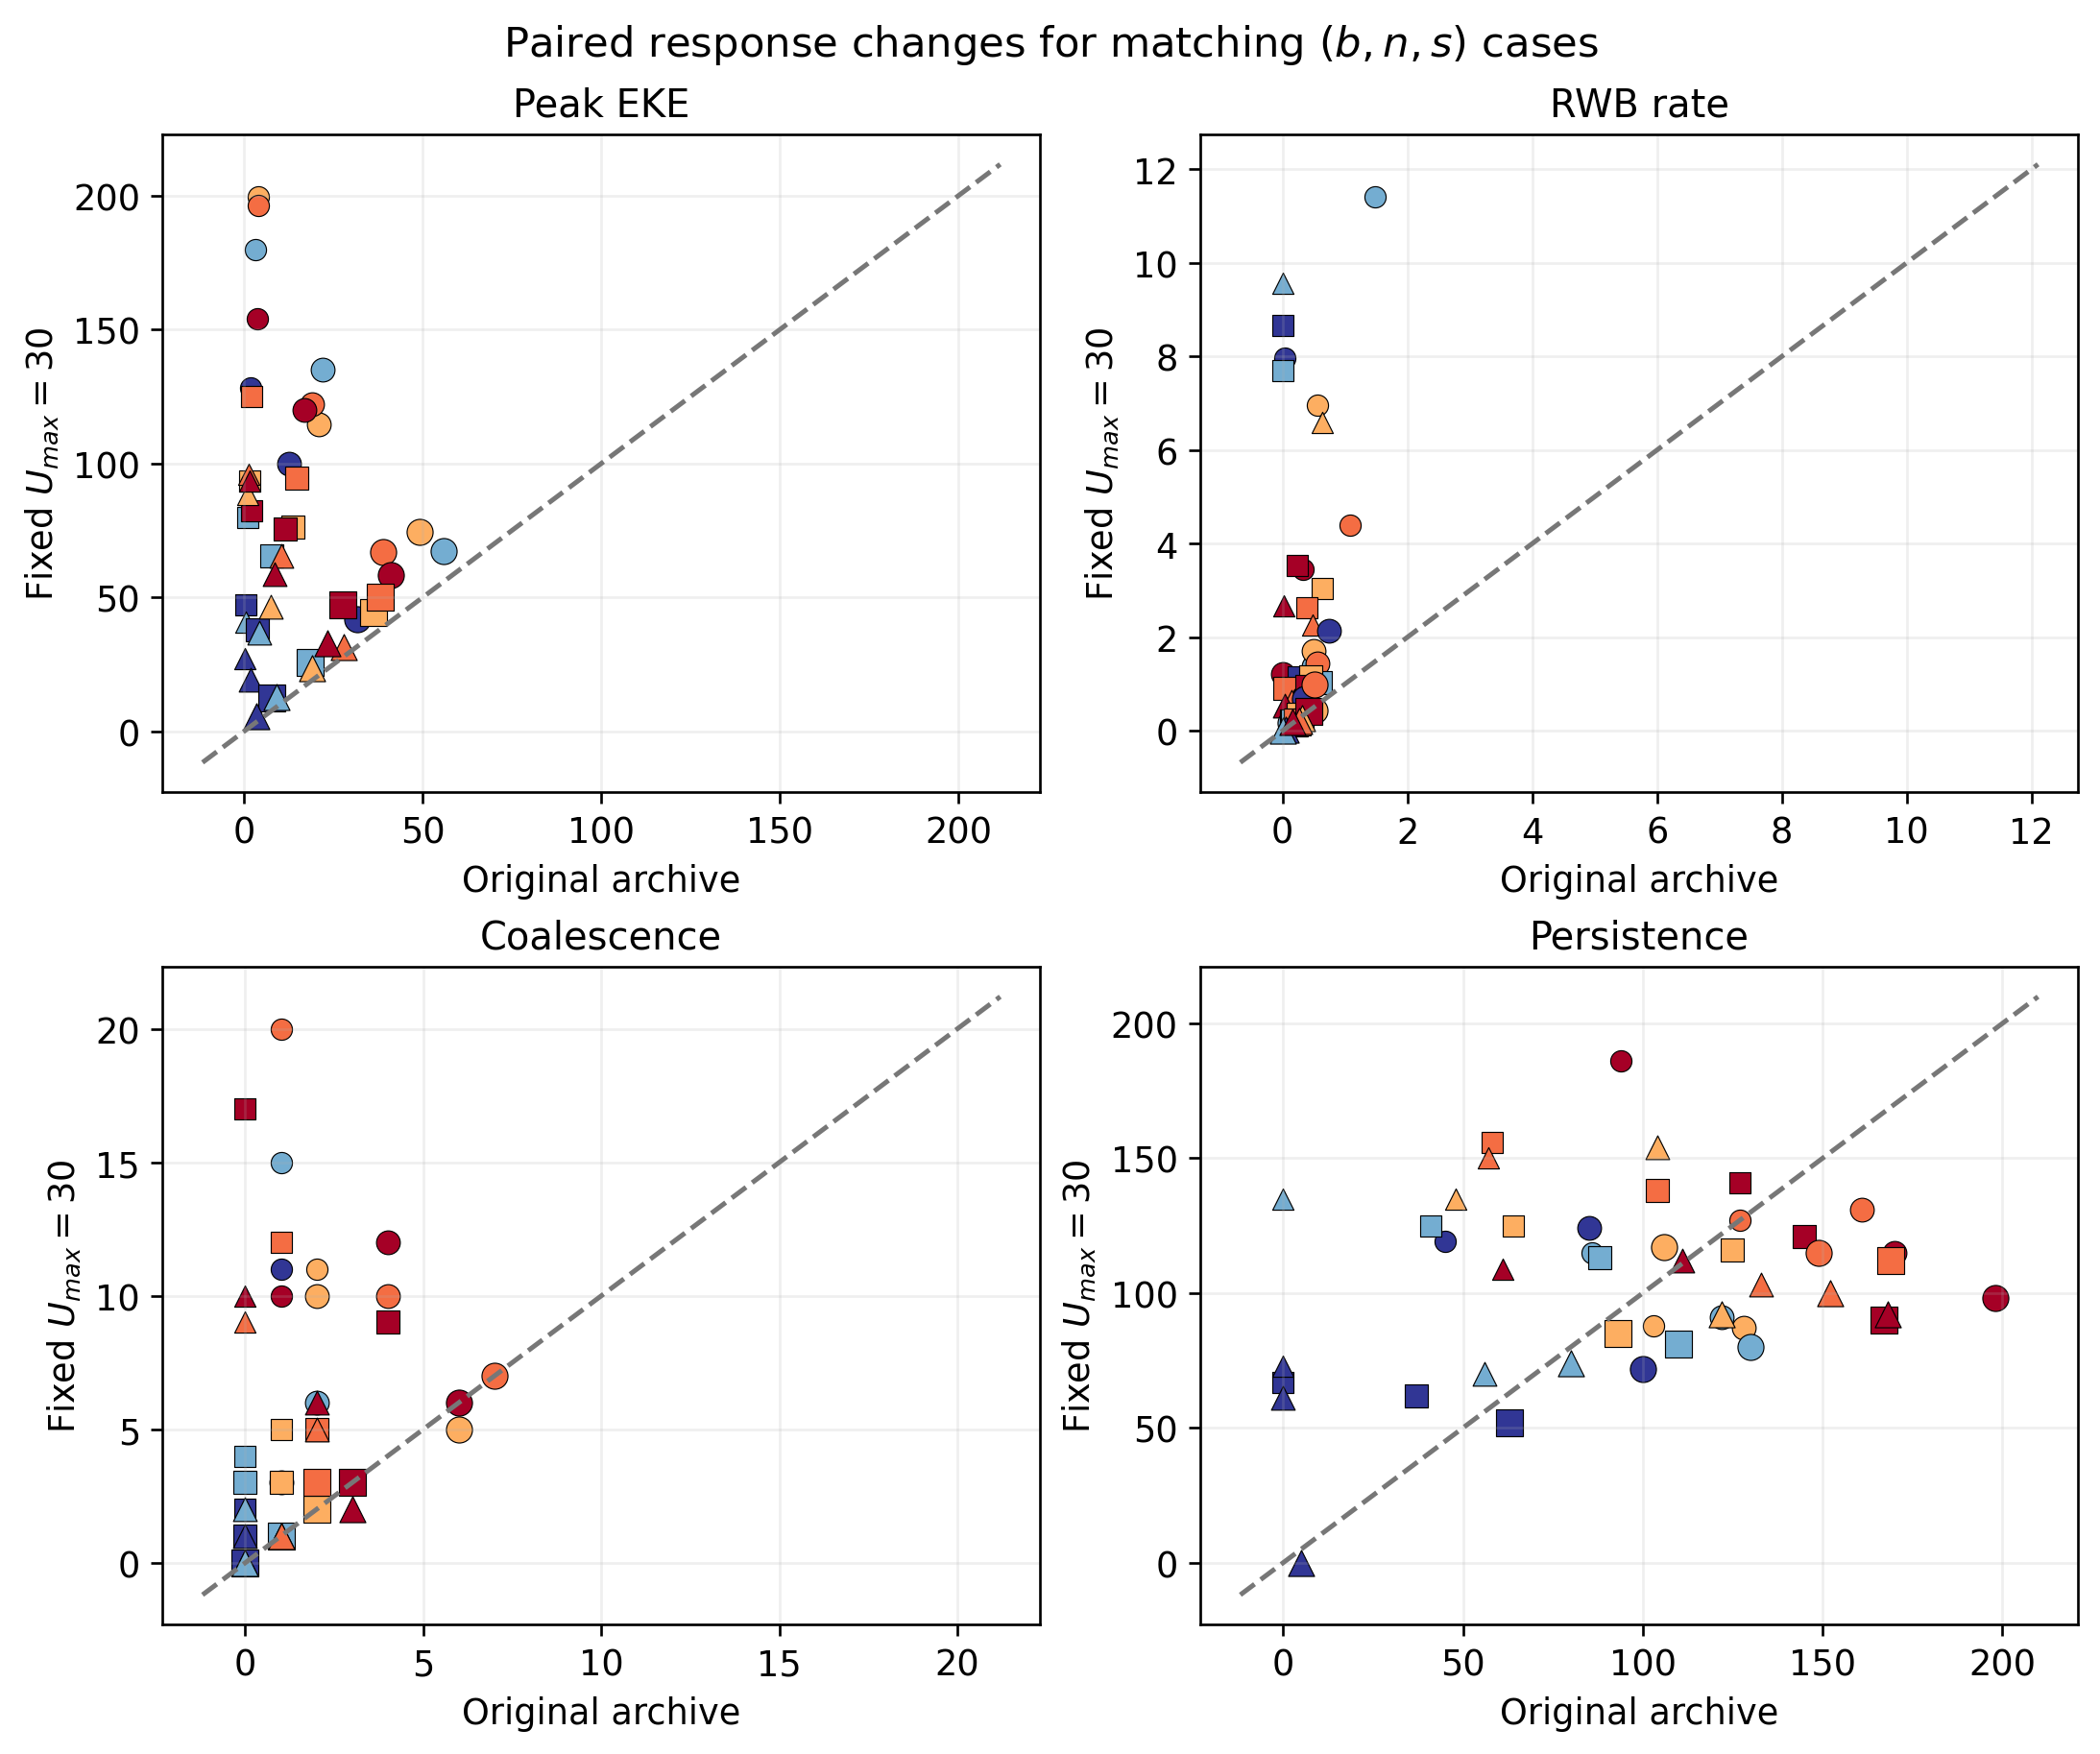

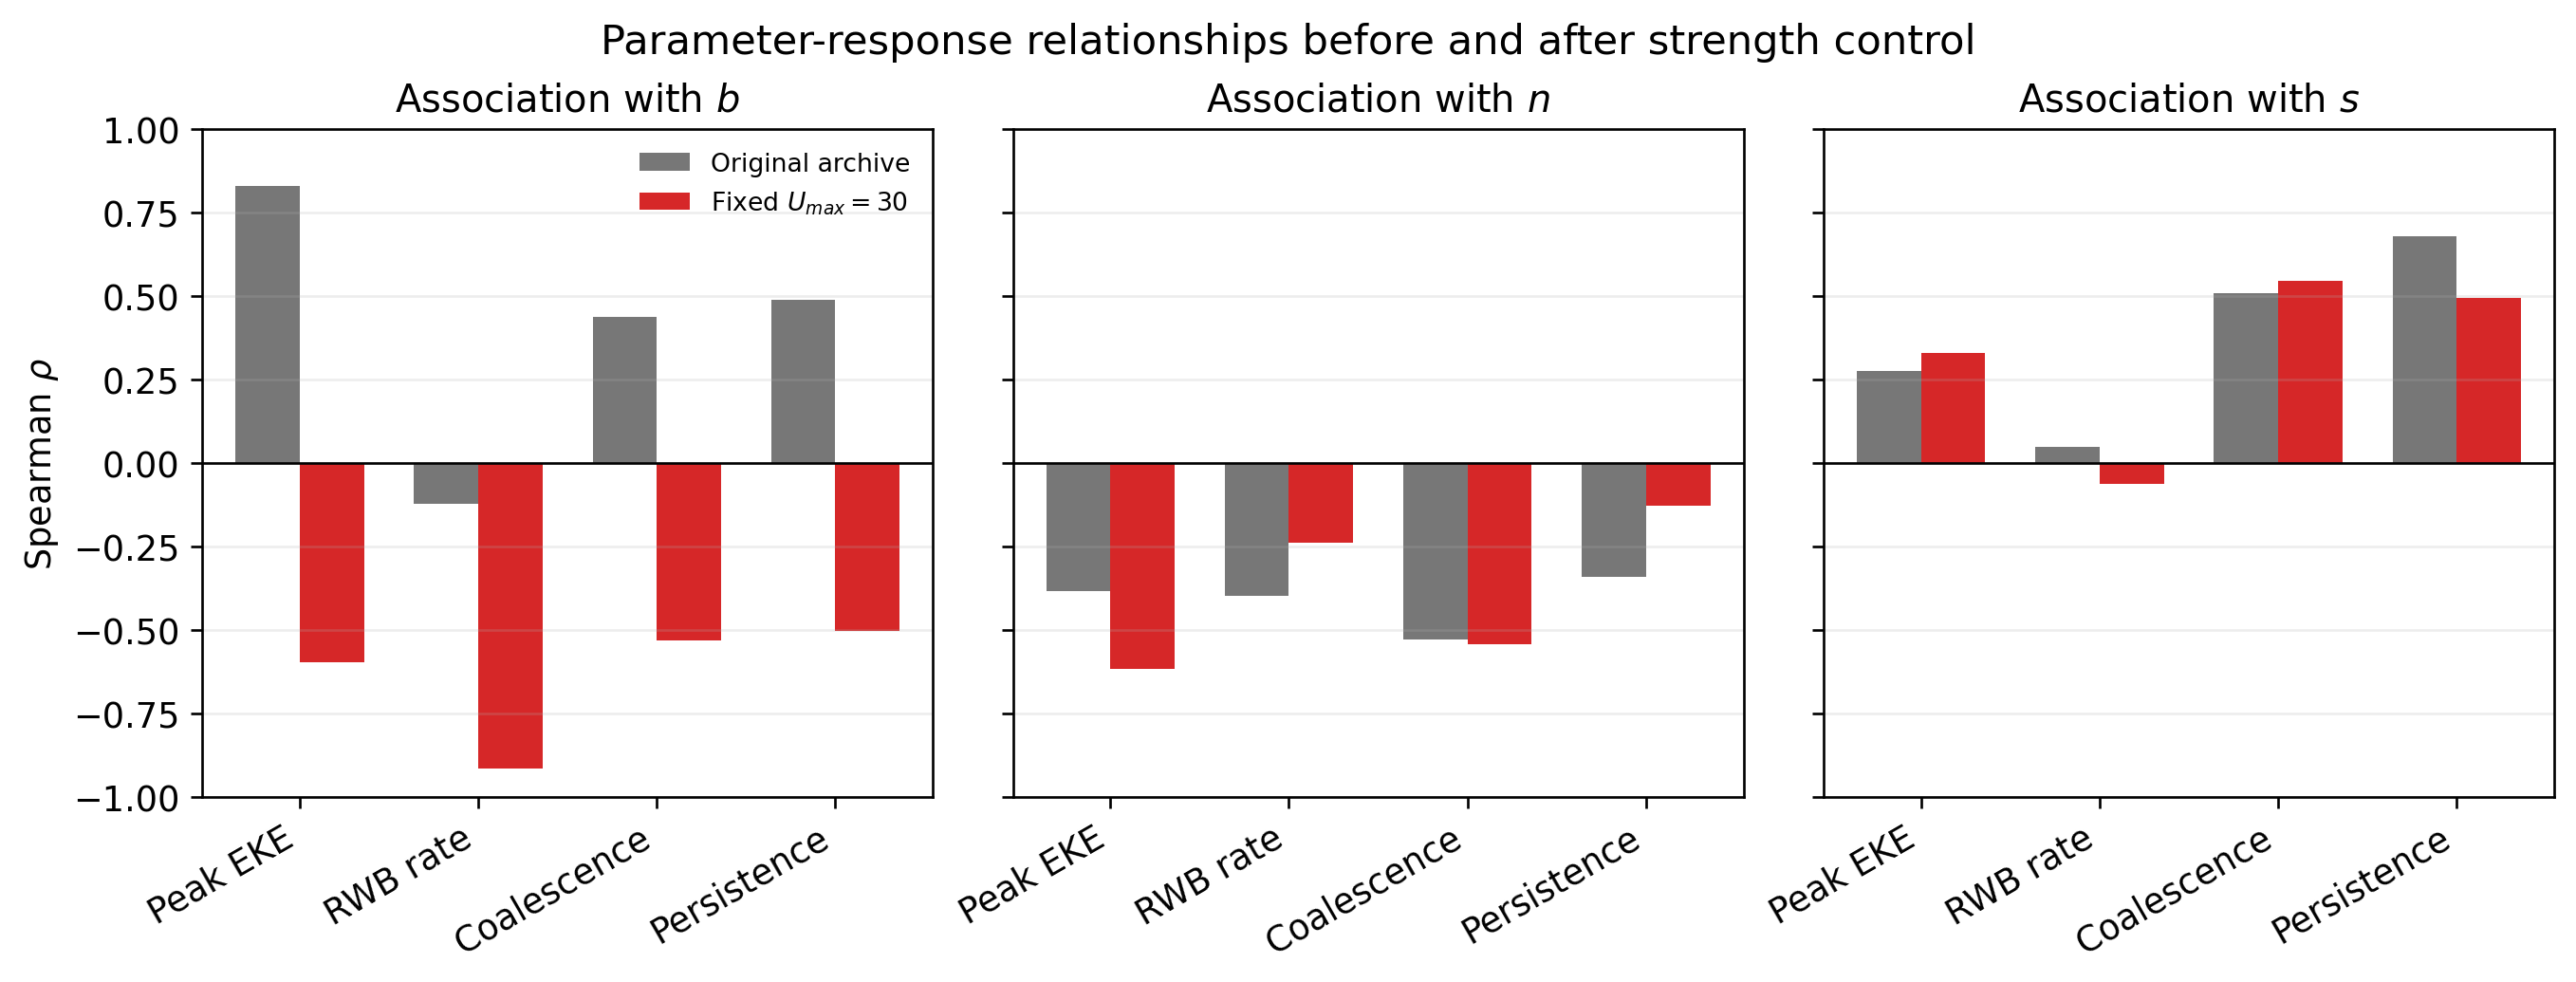

In [5]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            build_figures_a2_a4()
finally:
    sys.argv = _original_argv
show_files(['eddy/controlled_umax30_bns_analysis_20260722/figures/F2_controlled_all45_heatmaps.png', 'eddy/controlled_umax30_bns_analysis_20260722/figures/F3_archive_controlled_paired.png', 'eddy/controlled_umax30_bns_analysis_20260722/figures/F4_parameter_spearman_comparison.png'])


## Figure A5

Original source: `eddy/controlled_umax30_bns_analysis_20260722/original_style_comparison/scripts/make_original_style_comparison_figures.py`


In [6]:
# Consolidated from eddy/controlled_umax30_bns_analysis_20260722/original_style_comparison/scripts/make_original_style_comparison_figures.py
REPO_ROOT = ROOT
__file__ = str(ROOT / 'eddy/controlled_umax30_bns_analysis_20260722/original_style_comparison/scripts/make_original_style_comparison_figures.py')

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, PercentFormatter
ROOT = REPO_ROOT
BASE = ROOT / 'eddy' / 'controlled_umax30_bns_analysis_20260722'
OUT = BASE / 'original_style_comparison'
FIGURES = OUT / 'figures'
TABLES = OUT / 'tables'
ARCHIVE_HEADLINE = ROOT / 'priority_revision_analysis_20260720' / 'tables' / 'headline_responses_and_initial_predictors.csv'
CONTROLLED_HEADLINE = BASE / 'tables' / 'umax30_all45_headline_responses.csv'
CONTROLLED_RWB = TABLES / 'controlled_rwb_direct_counts_all45.csv'
ARCHIVE_PERSISTENCE = TABLES / 'archive_anticyclone_persistence_coarse5_all45.csv'
COLOR_CYC = '#fc9274'
COLOR_ANT = '#9ecae1'
B_VALUES = [1.0, 1.5, 2.0]
N_VALUES = [1, 3, 6]
S_VALUES = [-10, -5, 0, 5, 10]

def original_rwb_counts() -> pd.DataFrame:
    rows = []
    values = {'n': {6: (388, 501), 3: (446, 839), 1: (269, 1678)}, 'b': {1.0: (622, 867), 1.5: (311, 979), 2.0: (170, 1172)}, 's': {-10: (355, 53), -5: (358, 277), 0: (270, 611), 5: (120, 994), 10: (0, 1083)}}
    for parameter, groups in values.items():
        for value, (cyclonic, anticyclonic) in groups.items():
            rows.append({'ensemble': 'Original archive', 'parameter': parameter, 'value': value, 'cyclonic': cyclonic, 'anticyclonic': anticyclonic, 'total': cyclonic + anticyclonic})
    return pd.DataFrame(rows)

def controlled_rwb_counts() -> pd.DataFrame:
    data = pd.read_csv(CONTROLLED_RWB)
    rows = []
    for parameter, order in [('n', [6, 3, 1]), ('b', B_VALUES), ('s', S_VALUES)]:
        grouped = data.groupby(parameter)[['cyclonic', 'anticyclonic']].sum().reindex(order)
        for value, row in grouped.iterrows():
            rows.append({'ensemble': 'Fixed Umax=30 m s-1', 'parameter': parameter, 'value': value, 'cyclonic': int(row.cyclonic), 'anticyclonic': int(row.anticyclonic), 'total': int(row.sum())})
    return pd.DataFrame(rows)

def rwb_layout(data: pd.DataFrame):
    order = [('n', [6, 3, 1]), ('b', B_VALUES), ('s', S_VALUES)]
    y = []
    labels = []
    cyclonic = []
    anticyclonic = []
    group_spans = []
    position = 0.0
    for parameter, values in order:
        start = len(y)
        for value in values:
            row = data[(data.parameter == parameter) & np.isclose(data.value.astype(float), float(value))].iloc[0]
            total = row.cyclonic + row.anticyclonic
            y.append(position)
            labels.append(f'${parameter}$ = {value:g}')
            cyclonic.append(row.cyclonic / total if total else 0)
            anticyclonic.append(row.anticyclonic / total if total else 0)
            position += 1.0
        group_spans.append((parameter, start, len(y)))
        position += 0.7
    return (np.array(y), labels, np.array(cyclonic), np.array(anticyclonic), group_spans)

def draw_rwb_panel(axis, data: pd.DataFrame, title: str, show_y: bool=True, show_arrows: bool=True):
    y, labels, cyclonic, anticyclonic, spans = rwb_layout(data)
    counts = []
    for parameter, values in [('n', [6, 3, 1]), ('b', B_VALUES), ('s', S_VALUES)]:
        for value in values:
            row = data[(data.parameter == parameter) & np.isclose(data.value.astype(float), float(value))].iloc[0]
            counts.append((int(row.cyclonic), int(row.anticyclonic)))
    axis.barh(y, cyclonic, height=0.7, color=COLOR_CYC, edgecolor='white')
    axis.barh(y, anticyclonic, height=0.7, left=cyclonic, color=COLOR_ANT, edgecolor='white')
    for position, left, right, (left_count, right_count) in zip(y, cyclonic, anticyclonic, counts):
        if left_count > 0:
            axis.text(left / 2, position, str(left_count), ha='center', va='center', fontsize=10)
        if right_count > 0:
            axis.text(left + right / 2, position, str(right_count), ha='center', va='center', fontsize=10)
    for (_, _, end), (_, next_start, _) in zip(spans[:-1], spans[1:]):
        axis.axhline(0.5 * (y[end - 1] + y[next_start]), color='black', linewidth=1.2)
    axis.set_xlim(0, 1)
    axis.xaxis.set_major_formatter(PercentFormatter(1.0))
    axis.xaxis.set_major_locator(MultipleLocator(0.25))
    axis.grid(axis='x', linestyle=':', alpha=0.45)
    axis.set_yticks(y)
    if show_y:
        axis.set_yticklabels(labels)
    else:
        axis.tick_params(axis='y', labelleft=False)
    axis.set_xlabel('Fraction of Events')
    axis.set_title(title, fontsize=14)
    if show_arrows:
        directions = [('broader jet →', spans[0]), ('higher jet →', spans[1]), ('poleward-shifted jet →', spans[2])]
        for text, (_, start, end) in directions:
            center = 0.5 * (y[start] + y[end - 1])
            axis.text(1.015, center, text, rotation=-90, va='center', ha='left', transform=axis.get_yaxis_transform(), fontsize=10, fontweight='bold')

def make_rwb_figures(original: pd.DataFrame, controlled: pd.DataFrame):
    figure, axis = plt.subplots(figsize=(8.2, 10.2), dpi=220)
    draw_rwb_panel(axis, controlled, 'Fixed-$U_{max}$ RWB Frequency\n($\\theta=330$ K, $|PV|=2.0$ PVU)')
    axis.invert_yaxis()
    figure.legend([Patch(color=COLOR_CYC), Patch(color=COLOR_ANT)], ['Cyclonic', 'Anticyclonic'], loc='lower center', ncol=2, frameon=False)
    figure.subplots_adjust(bottom=0.1, right=0.88)
    figure.savefig(FIGURES / 'Figure5_controlled_original_style.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'Figure5_controlled_original_style.pdf', bbox_inches='tight')
    plt.close(figure)
    figure, axes = plt.subplots(1, 2, figsize=(15.2, 10.2), sharey=True, dpi=220)
    draw_rwb_panel(axes[0], original, '(a) Original archive', show_y=True, show_arrows=False)
    draw_rwb_panel(axes[1], controlled, '(b) Fixed $U_{max}=30$ m s$^{-1}$', show_y=False, show_arrows=True)
    axes[0].invert_yaxis()
    figure.suptitle('Relative Frequency of Cyclonic vs Anticyclonic Wave Breaking\n($\\theta=330$ K, $|PV|=2.0$ PVU)', fontsize=19)
    figure.legend([Patch(color=COLOR_CYC), Patch(color=COLOR_ANT)], ['Cyclonic', 'Anticyclonic'], loc='lower center', ncol=2, frameon=False, fontsize=12)
    figure.subplots_adjust(bottom=0.1, right=0.93, top=0.88, wspace=0.06)
    figure.savefig(FIGURES / 'Figure5_original_vs_controlled_same_style.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'Figure5_original_vs_controlled_same_style.pdf', bbox_inches='tight')
    plt.close(figure)

def heatmap_arrays(data: pd.DataFrame, value: str):
    return [data[np.isclose(data.s, s)].pivot(index='b', columns='n', values=value).reindex(index=B_VALUES, columns=N_VALUES).to_numpy(float) for s in S_VALUES]

def annotate_heatmap(axis, array, vmin, vmax, integer=True):
    for i in range(array.shape[0]):
        for j in range(array.shape[1]):
            value = array[i, j]
            fraction = 0.5 if vmax == vmin else (value - vmin) / (vmax - vmin)
            axis.text(j, i, f'{value:.0f}' if integer else f'{value:.1f}', ha='center', va='center', fontsize=9, color='white' if fraction < 0.32 else 'black')

def make_single_heatmap_figure(data, value, title, colorbar_label, stem, integer=True):
    arrays = heatmap_arrays(data, value)
    finite = np.concatenate([array.ravel() for array in arrays])
    vmin, vmax = (float(np.nanmin(finite)), float(np.nanmax(finite)))
    figure, axes = plt.subplots(1, 5, figsize=(15.7, 3.6), sharex=True, sharey=True, constrained_layout=True)
    image = None
    for axis, s, array in zip(axes, S_VALUES, arrays):
        image = axis.imshow(array, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        annotate_heatmap(axis, array, vmin, vmax, integer)
        axis.set_title(f'$s={s}°$')
        axis.set_xticks(range(3), N_VALUES)
        axis.set_yticks(range(3), [f'{b:g}' for b in B_VALUES])
        axis.set_xlabel('$n$')
    axes[0].set_ylabel('$b$')
    figure.colorbar(image, ax=axes, label=colorbar_label, shrink=0.84)
    figure.suptitle(title, fontsize=14)
    figure.savefig(FIGURES / f'{stem}.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / f'{stem}.pdf', bbox_inches='tight')
    plt.close(figure)

def make_comparison_heatmap(original, controlled, original_value, controlled_value, title, colorbar_label, stem, integer=True):
    original_arrays = heatmap_arrays(original, original_value)
    controlled_arrays = heatmap_arrays(controlled, controlled_value)
    finite = np.concatenate([array.ravel() for array in original_arrays + controlled_arrays])
    vmin, vmax = (float(np.nanmin(finite)), float(np.nanmax(finite)))
    figure, axes = plt.subplots(2, 5, figsize=(15.8, 6.5), sharex=True, sharey=True, constrained_layout=True)
    image = None
    for row, (label, arrays) in enumerate([('Original archive', original_arrays), ('Fixed $U_{max}=30$ m s$^{-1}$', controlled_arrays)]):
        for column, (s, array) in enumerate(zip(S_VALUES, arrays)):
            axis = axes[row, column]
            image = axis.imshow(array, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
            annotate_heatmap(axis, array, vmin, vmax, integer)
            if row == 0:
                axis.set_title(f'$s={s}°$')
            axis.set_xticks(range(3), N_VALUES)
            axis.set_yticks(range(3), [f'{b:g}' for b in B_VALUES])
            if row == 1:
                axis.set_xlabel('$n$')
            if column == 0:
                axis.set_ylabel(f'{label}\n$b$')
    figure.colorbar(image, ax=axes, label=colorbar_label, shrink=0.85)
    figure.suptitle(title, fontsize=15)
    figure.savefig(FIGURES / f'{stem}.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / f'{stem}.pdf', bbox_inches='tight')
    plt.close(figure)

def markdown_table(frame: pd.DataFrame) -> str:
    columns = [str(column) for column in frame.columns]
    lines = ['| ' + ' | '.join(columns) + ' |', '| ' + ' | '.join(['---'] * len(columns)) + ' |']
    for row in frame.itertuples(index=False, name=None):
        values = []
        for value in row:
            if isinstance(value, float):
                values.append(f'{value:.3f}')
            else:
                values.append(str(value))
        lines.append('| ' + ' | '.join(values) + ' |')
    return '\n'.join(lines)

def write_report(original_rwb, controlled_rwb, archive, controlled, archive_persistence):
    combined_rwb = pd.concat([original_rwb, controlled_rwb], ignore_index=True)
    combined_rwb.to_csv(TABLES / 'Figure5_original_controlled_group_counts.csv', index=False)
    archive_coalescence = archive[['case', 'b', 'n', 's', 'eddy_minus10_coalescence_count']].copy()
    controlled_coalescence = controlled[['case', 'b', 'n', 's', 'eddy_minus10_coalescence_count']].copy()
    archive_coalescence.to_csv(TABLES / 'Figure10_archive_eddy_minus10_counts.csv', index=False)
    controlled_coalescence.to_csv(TABLES / 'Figure10_controlled_eddy_minus10_counts.csv', index=False)
    controlled_persistence = controlled[['case', 'b', 'n', 's', 'anticyclone_overlap_duration_hours']].copy()
    controlled_persistence.to_csv(TABLES / 'Figure13_controlled_persistence_coarse5.csv', index=False)
    rwb_summary = combined_rwb.copy()
    rwb_summary['cyclonic_fraction'] = rwb_summary.cyclonic / rwb_summary.total
    rwb_summary['anticyclonic_fraction'] = rwb_summary.anticyclonic / rwb_summary.total
    report = ['# Original-Style Figure Comparison for the Complete Fixed-$U_{max}$ Ensemble', '', 'This package reproduces the visual forms of manuscript Figures 5, 10, and 13 using the complete 45-member fixed-$U_{max}=30$ m s$^{-1}$ ensemble and places them beside consistently calculated archive results.', '', '## Figure 5: RWB orientation fractions', '', 'The controlled RWB counts are recomputed directly from the hourly 330-K PV fields with the same WaveBreaking settings used by the original notebook: five smoothing passes, $|PV|=2$ PVU, `range_group=5`, and `min_exp=1`. They are therefore not inferred from the linked-track subset.', '', '![Figure 5 comparison](figures/Figure5_original_vs_controlled_same_style.png)', '', '## Figure 10: eddy-pressure coalescence', '', 'The Figure-10 layout is retained, but both rows use the revised closed $-10$-hPa eddy-pressure contour criterion. This makes the archive-versus-controlled comparison robust to the zonal-mean-pressure objection; it should not be labeled as the original full-field 980/990-hPa criterion.', '', '![Figure 10 comparison](figures/Figure10_original_vs_controlled_eddy_minus10_same_style.png)', '', '## Figure 13: anticyclone persistence', '', 'Both rows use the same hourly 5° tracker, $p_s\\ge1010$ hPa, minimum area $10^5$ km$^2$, and consecutive-overlap threshold 0.8. The archive persistence was recomputed specifically for this comparison.', '', '![Figure 13 comparison](figures/Figure13_original_vs_controlled_persistence_same_style.png)', '', '## RWB grouped counts', '', markdown_table(rwb_summary[['ensemble', 'parameter', 'value', 'cyclonic', 'anticyclonic', 'total', 'cyclonic_fraction', 'anticyclonic_fraction']]), '', '## Interpretation', '', '- The original-style RWB plot directly shows whether strength control changes both the total number of overturning detections and their cyclonic–anticyclonic partition.', '- The Figure-10-style comparison shows the reversal of the $b$ relationship for revised eddy-pressure coalescence while retaining the strong $n$ and $s$ structure.', '- The Figure-13-style comparison isolates persistence changes from tracker-resolution differences because both ensembles use the same coarse overlap definition.', '']
    (OUT / 'original_style_figure_comparison_report.md').write_text('\n'.join(report), encoding='utf-8')

def main():
    FIGURES.mkdir(parents=True, exist_ok=True)
    TABLES.mkdir(parents=True, exist_ok=True)
    archive = pd.read_csv(ARCHIVE_HEADLINE)
    controlled = pd.read_csv(CONTROLLED_HEADLINE)
    archive_persistence = pd.read_csv(ARCHIVE_PERSISTENCE)
    original_rwb = original_rwb_counts()
    controlled_rwb = controlled_rwb_counts()
    make_rwb_figures(original_rwb, controlled_rwb)
    make_single_heatmap_figure(controlled, 'eddy_minus10_coalescence_count', 'Fixed-$U_{max}$ Eddy-Pressure Coalescence', 'Closed $-10$-hPa eddy-contour events', 'Figure10_controlled_original_style_eddy_minus10')
    make_comparison_heatmap(archive, controlled, 'eddy_minus10_coalescence_count', 'eddy_minus10_coalescence_count', 'Eddy-Pressure Coalescence Before and After Jet-Strength Control', 'Closed $-10$-hPa eddy-contour events', 'Figure10_original_vs_controlled_eddy_minus10_same_style')
    make_single_heatmap_figure(controlled, 'anticyclone_overlap_duration_hours', 'Fixed-$U_{max}$ Anticyclone Persistence', 'Overlap-connected duration (h)', 'Figure13_controlled_original_style_persistence')
    make_comparison_heatmap(archive_persistence, controlled, 'anticyclone_overlap_duration_hours_coarse5', 'anticyclone_overlap_duration_hours', 'Anticyclone Persistence Before and After Jet-Strength Control', 'Overlap-connected duration (h)', 'Figure13_original_vs_controlled_persistence_same_style')
    write_report(original_rwb, controlled_rwb, archive, controlled, archive_persistence)
    print(f'Wrote original-style comparison package to {OUT}')


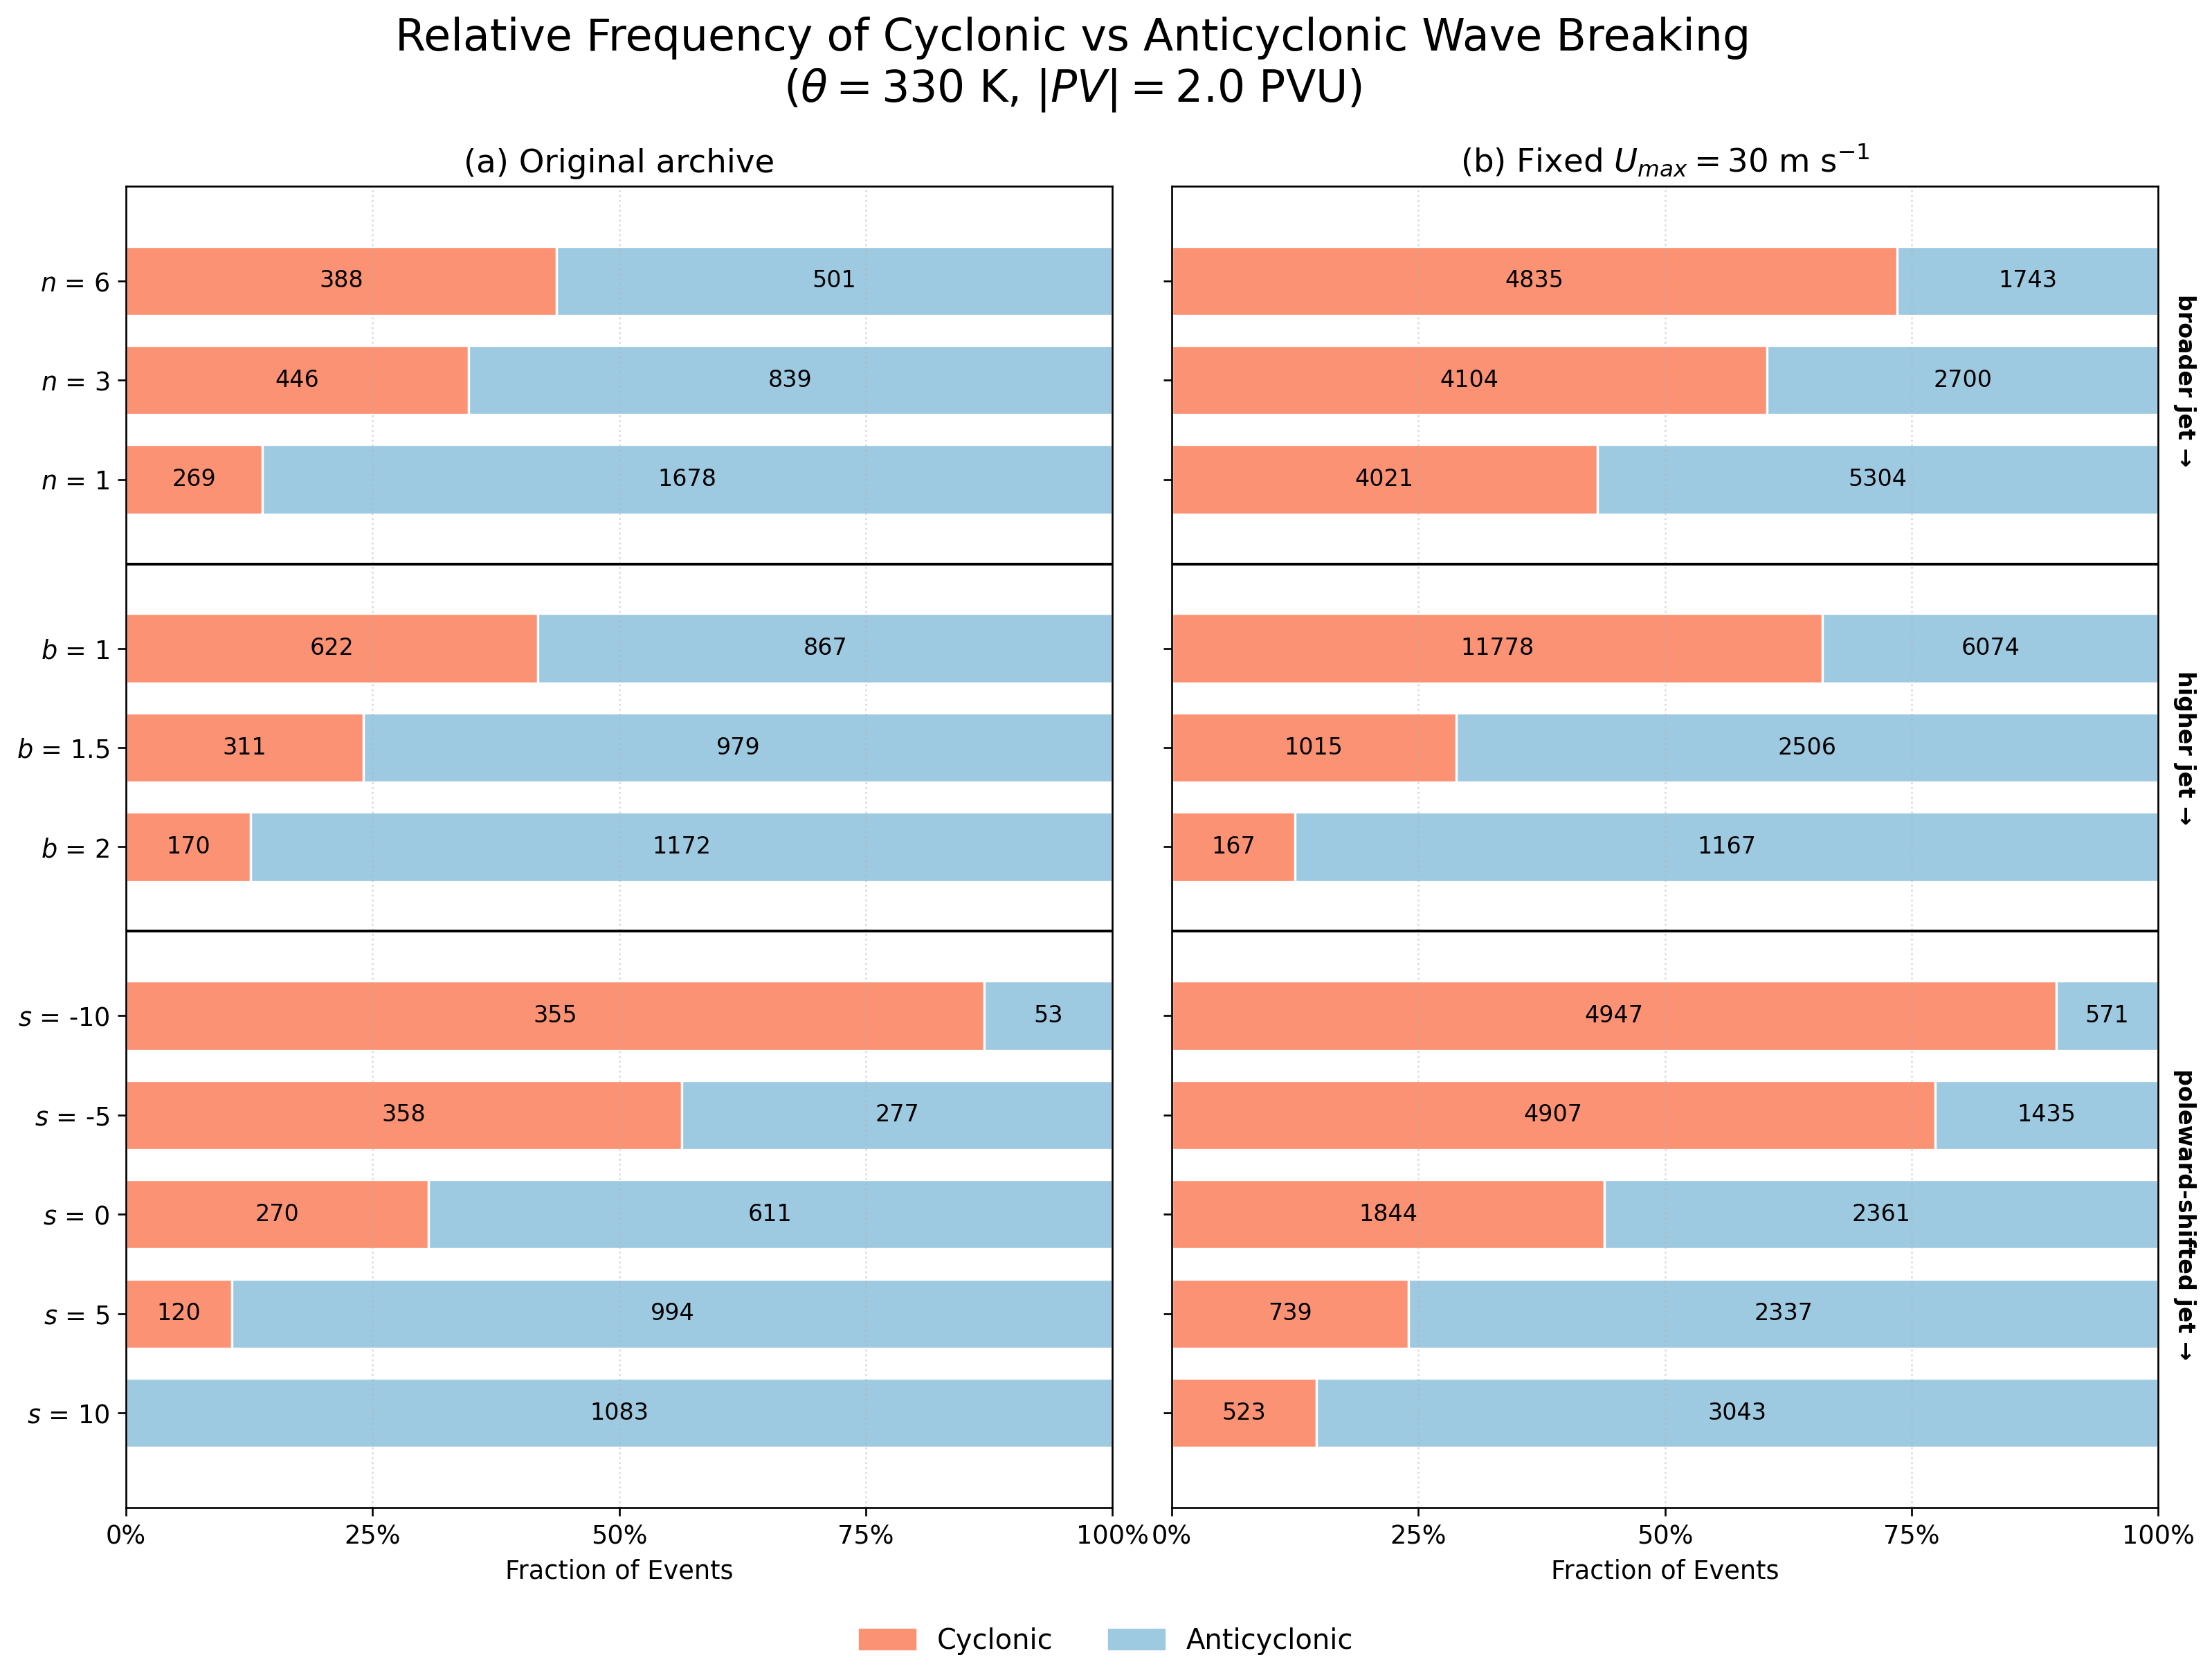

In [7]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            main()
finally:
    sys.argv = _original_argv
show_files(['eddy/controlled_umax30_bns_analysis_20260722/original_style_comparison/figures/Figure5_original_vs_controlled_same_style.png'])


## Figures B1–B4

Original source: `eddy/eddy_full_coalescence_review_analysis_20260723/scripts/aggregate_and_plot.py`


In [8]:
# Consolidated from eddy/eddy_full_coalescence_review_analysis_20260723/scripts/aggregate_and_plot.py
REPO_ROOT = ROOT
__file__ = str(ROOT / 'eddy/eddy_full_coalescence_review_analysis_20260723/scripts/aggregate_and_plot.py')

import math
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
ROOT = REPO_ROOT
BASE = ROOT / 'eddy' / 'eddy_full_coalescence_review_analysis_20260723'
CASE_RESULTS = BASE / 'case_results'
TABLES = BASE / 'tables'
FIGURES = BASE / 'figures'
REFERENCE = ROOT / 'eddy' / 'controlled_umax30_bns_analysis_20260722' / 'original_style_comparison' / 'tables' / 'Figure10_archive_exact_original_event_counts.csv'
B_VALUES = [1.0, 1.5, 2.0]
N_VALUES = [6, 3, 1]
S_VALUES = [-10, -5, 0, 5, 10]

def load_case_outputs():
    summary_files = sorted((path for path in CASE_RESULTS.glob('*_summary.csv') if 'vorticity' not in path.name))
    event_files = sorted(CASE_RESULTS.glob('*_events.csv'))
    partition_files = sorted(CASE_RESULTS.glob('*_full_to_eddy_partition.csv'))
    if len(summary_files) != 45 or len(event_files) != 45 or len(partition_files) != 45:
        raise RuntimeError(f'Incomplete exact diagnostics: summary={len(summary_files)}, events={len(event_files)}, partition={len(partition_files)}')
    summaries = pd.concat([pd.read_csv(path) for path in summary_files], ignore_index=True)
    events = pd.concat([pd.read_csv(path) for path in event_files], ignore_index=True)
    partitions = pd.concat([pd.read_csv(path) for path in partition_files if path.stat().st_size > 0], ignore_index=True)
    return (summaries, events, partitions)

def case_metrics(summaries):
    pivot = summaries.pivot_table(index=['case', 'b', 'n', 's'], columns=['mode', 'threshold_hpa'], values='event_count').reset_index()
    pivot.columns = ['case', 'b', 'n', 's', 'eddy_minus15_count', 'eddy_minus10_count', 'eddy_minus5_count', 'full_990_count']
    return pivot

def validate_full(case_data):
    reference = pd.read_csv(REFERENCE)
    verification = case_data.merge(reference[['case', 'figure10_coalescence_event_count']], on='case', how='left')
    verification['difference'] = verification['full_990_count'] - verification['figure10_coalescence_event_count']
    verification.to_csv(TABLES / 'full_990_exact_manuscript_reproduction.csv', index=False)
    if len(verification) != 45 or not np.all(verification['difference'] == 0):
        raise RuntimeError('Full-field 990-hPa reproduction does not match the manuscript')
    return verification

def grouped_statistics(case_data):
    response_columns = ['full_990_count', 'eddy_minus5_count', 'eddy_minus10_count', 'eddy_minus15_count']
    group_rows = []
    rank_rows = []
    for grouping in ['b', 'n', 's']:
        means = case_data.groupby(grouping)[response_columns].mean().reset_index()
        for _, row in means.iterrows():
            for response in response_columns:
                group_rows.append({'grouping': grouping, 'group_value': row[grouping], 'response': response, 'mean_event_count': row[response]})
        for response in response_columns[1:]:
            rho, pvalue = spearmanr(means['full_990_count'], means[response])
            rank_rows.append({'eddy_response': response, 'grouping': grouping, 'spearman_rho': rho, 'p_value': pvalue, 'n_groups': len(means)})
    for response in response_columns[1:]:
        rho, pvalue = spearmanr(case_data['full_990_count'], case_data[response])
        rank_rows.append({'eddy_response': response, 'grouping': 'case_level_45', 'spearman_rho': rho, 'p_value': pvalue, 'n_groups': len(case_data)})
    group_means = pd.DataFrame(group_rows)
    rank = pd.DataFrame(rank_rows)
    group_means.to_csv(TABLES / 'full_eddy_group_means.csv', index=False)
    rank.to_csv(TABLES / 'full_eddy_rank_agreement.csv', index=False)
    return (group_means, rank)

def angular_distance(left_lat, left_lon, right_lat, right_lon):
    delta_lon = (left_lon - right_lon + 180.0) % 360.0 - 180.0
    return math.hypot(left_lat - right_lat, delta_lon * math.cos(math.radians(0.5 * (left_lat + right_lat))))

def matching_sensitivity(events):
    rows = []
    full = events[(events['mode'] == 'full') & np.isclose(events['threshold_hpa'], 990.0)].copy()
    eddy = events[(events['mode'] == 'eddy') & np.isclose(events['threshold_hpa'], -10.0)].copy()
    open_boundary = eddy['child_touches_south_boundary'].fillna(False).astype(bool) | eddy['child_touches_north_boundary'].fillna(False).astype(bool)
    eddy = eddy[~open_boundary].copy()
    for window in [0, 3, 6, 12]:
        for distance_limit in [10.0, 15.0, 20.0, 30.0]:
            matched = 0
            for _, event in full.iterrows():
                candidates = eddy[(eddy['case'] == event['case']) & ((eddy['time_index'] - event['time_index']).abs() <= window)]
                found = False
                for _, candidate in candidates.iterrows():
                    distance = angular_distance(event['child_centroid_lat'], event['child_centroid_lon'], candidate['child_centroid_lat'], candidate['child_centroid_lon'])
                    if distance <= distance_limit:
                        found = True
                        break
                matched += int(found)
            rows.append({'time_window_h': window, 'distance_limit_deg': distance_limit, 'matched_full_events': matched, 'full_event_count': len(full), 'matched_fraction': matched / len(full)})
    result = pd.DataFrame(rows)
    result.to_csv(TABLES / 'full_to_eddy_match_sensitivity.csv', index=False)
    return result

def attach_partition(events, partitions):
    full = events[(events['mode'] == 'full') & np.isclose(events['threshold_hpa'], 990.0)].copy()
    full['full_event_index'] = full.groupby('case').cumcount()
    classified = full.merge(partitions[['case', 'full_event_index', 'partition', 'matched_eddy_event']], on=['case', 'full_event_index'], how='left')
    eddy = events[(events['mode'] == 'eddy') & np.isclose(events['threshold_hpa'], -10.0)].copy()
    open_boundary = eddy['child_touches_south_boundary'].fillna(False).astype(bool) | eddy['child_touches_north_boundary'].fillna(False).astype(bool)
    eddy = eddy[~open_boundary].copy()
    eddy['partition'] = 'eddy_minus10_event'
    combined = pd.concat([classified, eddy], ignore_index=True, sort=False)
    combined.to_csv(TABLES / 'event_level_size_extent_and_partition.csv', index=False)
    metrics = ['child_area_km2', 'child_equivalent_radius_km', 'child_zonal_extent_km', 'child_meridional_extent_km']
    size_summary = combined.groupby('partition')[metrics].agg(['count', 'mean', 'median', 'std']).reset_index()
    size_summary.columns = ['partition'] + [f'{metric}_{stat}' for metric, stat in size_summary.columns.tolist()[1:]]
    size_summary.to_csv(TABLES / 'size_extent_summary_by_partition.csv', index=False)
    partition_case = partitions.groupby(['case', 'b', 'n', 's', 'partition']).size().unstack(fill_value=0).reset_index()
    for column in ['local_wave_scale_coalescence', 'full_field_only_zonalization_signature']:
        if column not in partition_case:
            partition_case[column] = 0
    partition_case['full_event_count'] = partition_case['local_wave_scale_coalescence'] + partition_case['full_field_only_zonalization_signature']
    partition_case['local_fraction'] = np.where(partition_case.full_event_count > 0, partition_case.local_wave_scale_coalescence / partition_case.full_event_count, np.nan)
    partition_case.to_csv(TABLES / 'case_level_full_event_partition.csv', index=False)
    return (combined, size_summary, partition_case)

def heatmap_array(data, value, s):
    return data[np.isclose(data.s, s)].pivot(index='b', columns='n', values=value).reindex(index=B_VALUES, columns=N_VALUES).to_numpy(float)

def annotate(axis, array, fontsize=13):
    for row in range(array.shape[0]):
        for column in range(array.shape[1]):
            axis.text(column, row, f'{array[row, column]:.0f}', ha='center', va='center', fontsize=fontsize)

def plot_direct_comparison(case_data):
    cmap = LinearSegmentedColormap.from_list('white_red', ['#ffffff', '#ff0000'])
    vmax = float(max(case_data.full_990_count.max(), case_data.eddy_minus10_count.max()))
    figure, axes = plt.subplots(2, 5, figsize=(15.5, 6.8), sharex=True, sharey=True, constrained_layout=True)
    image = None
    for row, (label, value) in enumerate([('Original full field, 990 hPa', 'full_990_count'), ('Eddy SLP, -10 hPa', 'eddy_minus10_count')]):
        for column, s in enumerate(S_VALUES):
            array = heatmap_array(case_data, value, s)
            image = axes[row, column].imshow(array, origin='lower', cmap=cmap, vmin=0, vmax=vmax, aspect='equal')
            annotate(axes[row, column], array)
            if row == 0:
                axes[row, column].set_title(f'$s={s}°$', fontsize=15)
            axes[row, column].set_xticks(range(3), N_VALUES)
            axes[row, column].set_yticks(range(3), ['1.0', '1.5', '2.0'])
            if row == 1:
                axes[row, column].set_xlabel('$n$ (wider jet →)')
            if column == 0:
                axes[row, column].set_ylabel(f'{label}\n$b$ (higher jet →)')
    figure.colorbar(image, ax=axes, label='Connection events per simulation', shrink=0.84)
    figure.suptitle('Direct reproduction test: original full-field census versus eddy-SLP census', fontsize=17)
    figure.savefig(FIGURES / 'figure01_full990_vs_eddy_minus10_direct_comparison.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'figure01_full990_vs_eddy_minus10_direct_comparison.pdf', bbox_inches='tight')
    plt.close(figure)

def plot_thresholds(case_data):
    values = [('eddy_minus5_count', '-5 hPa'), ('eddy_minus10_count', '-10 hPa'), ('eddy_minus15_count', '-15 hPa')]
    vmax = float(case_data[[value for value, _ in values]].max().max())
    cmap = LinearSegmentedColormap.from_list('white_blue', ['#ffffff', '#2166ac'])
    figure, axes = plt.subplots(3, 5, figsize=(15.5, 9.5), sharex=True, sharey=True, constrained_layout=True)
    image = None
    for row, (value, label) in enumerate(values):
        for column, s in enumerate(S_VALUES):
            array = heatmap_array(case_data, value, s)
            image = axes[row, column].imshow(array, origin='lower', cmap=cmap, vmin=0, vmax=vmax, aspect='equal')
            annotate(axes[row, column], array, fontsize=11)
            if row == 0:
                axes[row, column].set_title(f'$s={s}°$')
            axes[row, column].set_xticks(range(3), N_VALUES)
            axes[row, column].set_yticks(range(3), ['1.0', '1.5', '2.0'])
            if row == 2:
                axes[row, column].set_xlabel('$n$')
            if column == 0:
                axes[row, column].set_ylabel(f'Eddy {label}\n$b$')
    figure.colorbar(image, ax=axes, label='Eddy-contour connection events', shrink=0.82)
    figure.suptitle('Threshold sensitivity of the eddy-SLP coalescence census', fontsize=17)
    figure.savefig(FIGURES / 'figure02_eddy_threshold_sensitivity_heatmaps.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'figure02_eddy_threshold_sensitivity_heatmaps.pdf', bbox_inches='tight')
    plt.close(figure)

def plot_group_trends(case_data):
    figure, axes = plt.subplots(1, 3, figsize=(14.5, 4.3), constrained_layout=True)
    styles = [('full_990_count', 'Full 990 hPa', 'black', 'o'), ('eddy_minus5_count', 'Eddy -5 hPa', '#74add1', '^'), ('eddy_minus10_count', 'Eddy -10 hPa', '#2b83ba', 's'), ('eddy_minus15_count', 'Eddy -15 hPa', '#08306b', 'D')]
    for axis, grouping, order in zip(axes, ['b', 'n', 's'], [B_VALUES, [6, 3, 1], S_VALUES]):
        means = case_data.groupby(grouping)[[item[0] for item in styles]].mean().reindex(order)
        for value, label, color, marker in styles:
            axis.plot(range(len(order)), means[value], marker=marker, color=color, label=label, linewidth=2)
        axis.set_xticks(range(len(order)), [str(item) for item in order])
        axis.set_xlabel(grouping)
        axis.set_ylabel('Mean event count')
        axis.grid(alpha=0.25)
    axes[0].legend(frameon=False, fontsize=9)
    figure.suptitle('The b-n-s ordering is retained after removal of the zonal-mean SLP')
    figure.savefig(FIGURES / 'figure03_full_eddy_group_trends.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'figure03_full_eddy_group_trends.pdf', bbox_inches='tight')
    plt.close(figure)

def plot_partition(partition_case, partitions):
    by_s = partitions.groupby(['s', 'partition']).size().unstack(fill_value=0).reindex(S_VALUES, fill_value=0)
    for column in ['local_wave_scale_coalescence', 'full_field_only_zonalization_signature']:
        if column not in by_s:
            by_s[column] = 0
    figure, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
    axes[0].bar(range(5), by_s['local_wave_scale_coalescence'], label='Also connects in eddy SLP', color='#2166ac')
    axes[0].bar(range(5), by_s['full_field_only_zonalization_signature'], bottom=by_s['local_wave_scale_coalescence'], label='Full-field only', color='#ef8a62')
    axes[0].set_xticks(range(5), S_VALUES)
    axes[0].set_xlabel('$s$ (degrees)')
    axes[0].set_ylabel('Original full-field events')
    axes[0].legend(frameon=False)
    matrix = partition_case.pivot_table(index='b', columns=['s', 'n'], values='local_fraction').reindex(index=B_VALUES)
    ordered = [(s, n) for s in S_VALUES for n in N_VALUES]
    matrix = matrix.reindex(columns=pd.MultiIndex.from_tuples(ordered)).to_numpy(float)
    image = axes[1].imshow(matrix, origin='lower', cmap='viridis', vmin=0, vmax=1, aspect='auto')
    axes[1].set_yticks(range(3), ['1.0', '1.5', '2.0'])
    axes[1].set_ylabel('$b$')
    axes[1].set_xticks(range(15), [f'{s}/{n}' for s, n in ordered], rotation=60, ha='right', fontsize=8)
    axes[1].set_xlabel('$s/n$ case ordering')
    figure.colorbar(image, ax=axes[1], label='Fraction of full events matched by eddy events')
    figure.suptitle('Partition of original full-field events')
    figure.savefig(FIGURES / 'figure04_full_event_partition.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'figure04_full_event_partition.pdf', bbox_inches='tight')
    plt.close(figure)

def plot_size_extent(combined):
    order = ['local_wave_scale_coalescence', 'full_field_only_zonalization_signature', 'eddy_minus10_event']
    labels = ['Full + eddy', 'Full only', 'All eddy -10']
    metrics = [('child_area_km2', 'Area ($10^6$ km$^2$)', 1000000.0), ('child_equivalent_radius_km', 'Equivalent radius (km)', 1), ('child_zonal_extent_km', 'Zonal extent (km)', 1), ('child_meridional_extent_km', 'Meridional extent (km)', 1)]
    figure, axes = plt.subplots(2, 2, figsize=(11.5, 8.5), constrained_layout=True)
    for axis, (metric, ylabel, scale) in zip(axes.flat, metrics):
        values = [combined.loc[combined.partition == group, metric].dropna().to_numpy() / scale for group in order]
        axis.boxplot(values, labels=labels, showfliers=False)
        axis.set_ylabel(ylabel)
        axis.tick_params(axis='x', rotation=12)
        axis.grid(axis='y', alpha=0.25)
    figure.suptitle('Size and horizontal extent of connected pressure objects')
    figure.savefig(FIGURES / 'figure05_event_size_extent.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'figure05_event_size_extent.pdf', bbox_inches='tight')
    plt.close(figure)

def plot_scatter(case_data, rank):
    rho = rank[(rank.eddy_response == 'eddy_minus10_count') & (rank.grouping == 'case_level_45')].iloc[0].spearman_rho
    figure, axis = plt.subplots(figsize=(6.2, 5.5), constrained_layout=True)
    scatter = axis.scatter(case_data.full_990_count, case_data.eddy_minus10_count, c=case_data.s, cmap='coolwarm', s=58, edgecolor='black', linewidth=0.4)
    maximum = max(case_data.full_990_count.max(), case_data.eddy_minus10_count.max())
    axis.plot([0, maximum], [0, maximum], linestyle='--', color='gray')
    axis.set_xlabel('Original full-field 990-hPa event count')
    axis.set_ylabel('Eddy-SLP -10-hPa event count')
    axis.set_title(f'Case-level agreement: Spearman $\\rho={rho:.3f}$')
    figure.colorbar(scatter, ax=axis, label='$s$ (degrees)')
    figure.savefig(FIGURES / 'figure06_case_level_full_eddy_scatter.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'figure06_case_level_full_eddy_scatter.pdf', bbox_inches='tight')
    plt.close(figure)

def aggregate_vorticity(events):
    summary_files = sorted(CASE_RESULTS.glob('*_vorticity_event_summary.csv'))
    timeseries_files = sorted(CASE_RESULTS.glob('*_vorticity_timeseries.csv'))
    if len(summary_files) != 45 or len(timeseries_files) != 45:
        return None
    summaries = pd.concat([pd.read_csv(path) for path in summary_files], ignore_index=True)
    timeseries = pd.concat([pd.read_csv(path) for path in timeseries_files], ignore_index=True)
    eddy_events = events[(events['mode'] == 'eddy') & np.isclose(events['threshold_hpa'], -10.0)].copy()
    eddy_events['event_index'] = eddy_events.groupby('case').cumcount()
    open_boundary = eddy_events['child_touches_south_boundary'].fillna(False).astype(bool) | eddy_events['child_touches_north_boundary'].fillna(False).astype(bool)
    closed_keys = eddy_events.loc[~open_boundary, ['case', 'event_index']]
    summaries = summaries.merge(closed_keys, on=['case', 'event_index'], how='inner')
    timeseries = timeseries.merge(closed_keys, on=['case', 'event_index'], how='inner')
    summaries.to_csv(TABLES / 'eddy_minus10_vorticity_event_summary.csv', index=False)
    timeseries.to_csv(TABLES / 'eddy_minus10_vorticity_timeseries.csv', index=False)
    counts = summaries.groupby('outcome').size().rename('n_events').reset_index()
    counts.to_csv(TABLES / 'eddy_minus10_vorticity_outcome_counts.csv', index=False)
    figure, axis = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    ordered = counts.sort_values('n_events')
    axis.barh(ordered.outcome.str.replace('_', ' '), ordered.n_events, color='#4d9221')
    for index, value in enumerate(ordered.n_events):
        axis.text(value + 0.2, index, str(value), va='center')
    axis.set_xlabel('Number of eddy -10-hPa connection events')
    axis.set_title('850-hPa vorticity-core outcomes')
    figure.savefig(FIGURES / 'figure07_eddy_vorticity_core_outcomes.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'figure07_eddy_vorticity_core_outcomes.pdf', bbox_inches='tight')
    plt.close(figure)
    return summaries

def main():
    TABLES.mkdir(parents=True, exist_ok=True)
    FIGURES.mkdir(parents=True, exist_ok=True)
    summaries, events, partitions = load_case_outputs()
    summaries.to_csv(TABLES / 'all_case_threshold_summaries.csv', index=False)
    events.to_csv(TABLES / 'all_connection_events_with_size_extent.csv', index=False)
    partitions.to_csv(TABLES / 'all_full_to_eddy_event_partitions.csv', index=False)
    case_data = case_metrics(summaries)
    for threshold, column in [(-5.0, 'eddy_minus5_count'), (-10.0, 'eddy_minus10_count'), (-15.0, 'eddy_minus15_count')]:
        case_data[f'{column}_all_threshold_regions'] = case_data[column]
        selected = events[(events['mode'] == 'eddy') & np.isclose(events['threshold_hpa'], threshold)].copy()
        open_boundary = selected['child_touches_south_boundary'].fillna(False).astype(bool) | selected['child_touches_north_boundary'].fillna(False).astype(bool)
        closed_counts = selected.loc[~open_boundary].groupby('case').size()
        case_data[column] = case_data['case'].map(closed_counts).fillna(0).astype(int)
    case_data.to_csv(TABLES / 'full_eddy_case_metrics.csv', index=False)
    validate_full(case_data)
    group_means, rank = grouped_statistics(case_data)
    match_sensitivity = matching_sensitivity(events)
    combined, size_summary, partition_case = attach_partition(events, partitions)
    plot_direct_comparison(case_data)
    plot_thresholds(case_data)
    plot_group_trends(case_data)
    plot_partition(partition_case, partitions)
    plot_size_extent(combined)
    plot_scatter(case_data, rank)
    vorticity = aggregate_vorticity(events)
    primary_match = match_sensitivity[(match_sensitivity.time_window_h == 6) & np.isclose(match_sensitivity.distance_limit_deg, 20.0)].iloc[0]
    summary_lines = [f'Full 990-hPa total events: {int(case_data.full_990_count.sum())}', f'Eddy totals (-5, -10, -15 hPa): {int(case_data.eddy_minus5_count.sum())}, {int(case_data.eddy_minus10_count.sum())}, {int(case_data.eddy_minus15_count.sum())}', f'Full exact manuscript mismatches: 0/45', f"Case-level full versus eddy -10 Spearman rho: {rank[(rank.eddy_response == 'eddy_minus10_count') & (rank.grouping == 'case_level_45')].iloc[0].spearman_rho:.6f}", f'Primary full-event partition: matched={int(primary_match.matched_full_events)}/{int(primary_match.full_event_count)} ({primary_match.matched_fraction:.3f}); full-only={int(primary_match.full_event_count - primary_match.matched_full_events)}']
    if vorticity is not None:
        summary_lines.append(f'Vorticity events classified: {len(vorticity)}; outcomes={vorticity.outcome.value_counts().to_dict()}')
    (TABLES / 'analysis_summary.txt').write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')
    print('\n'.join(summary_lines))


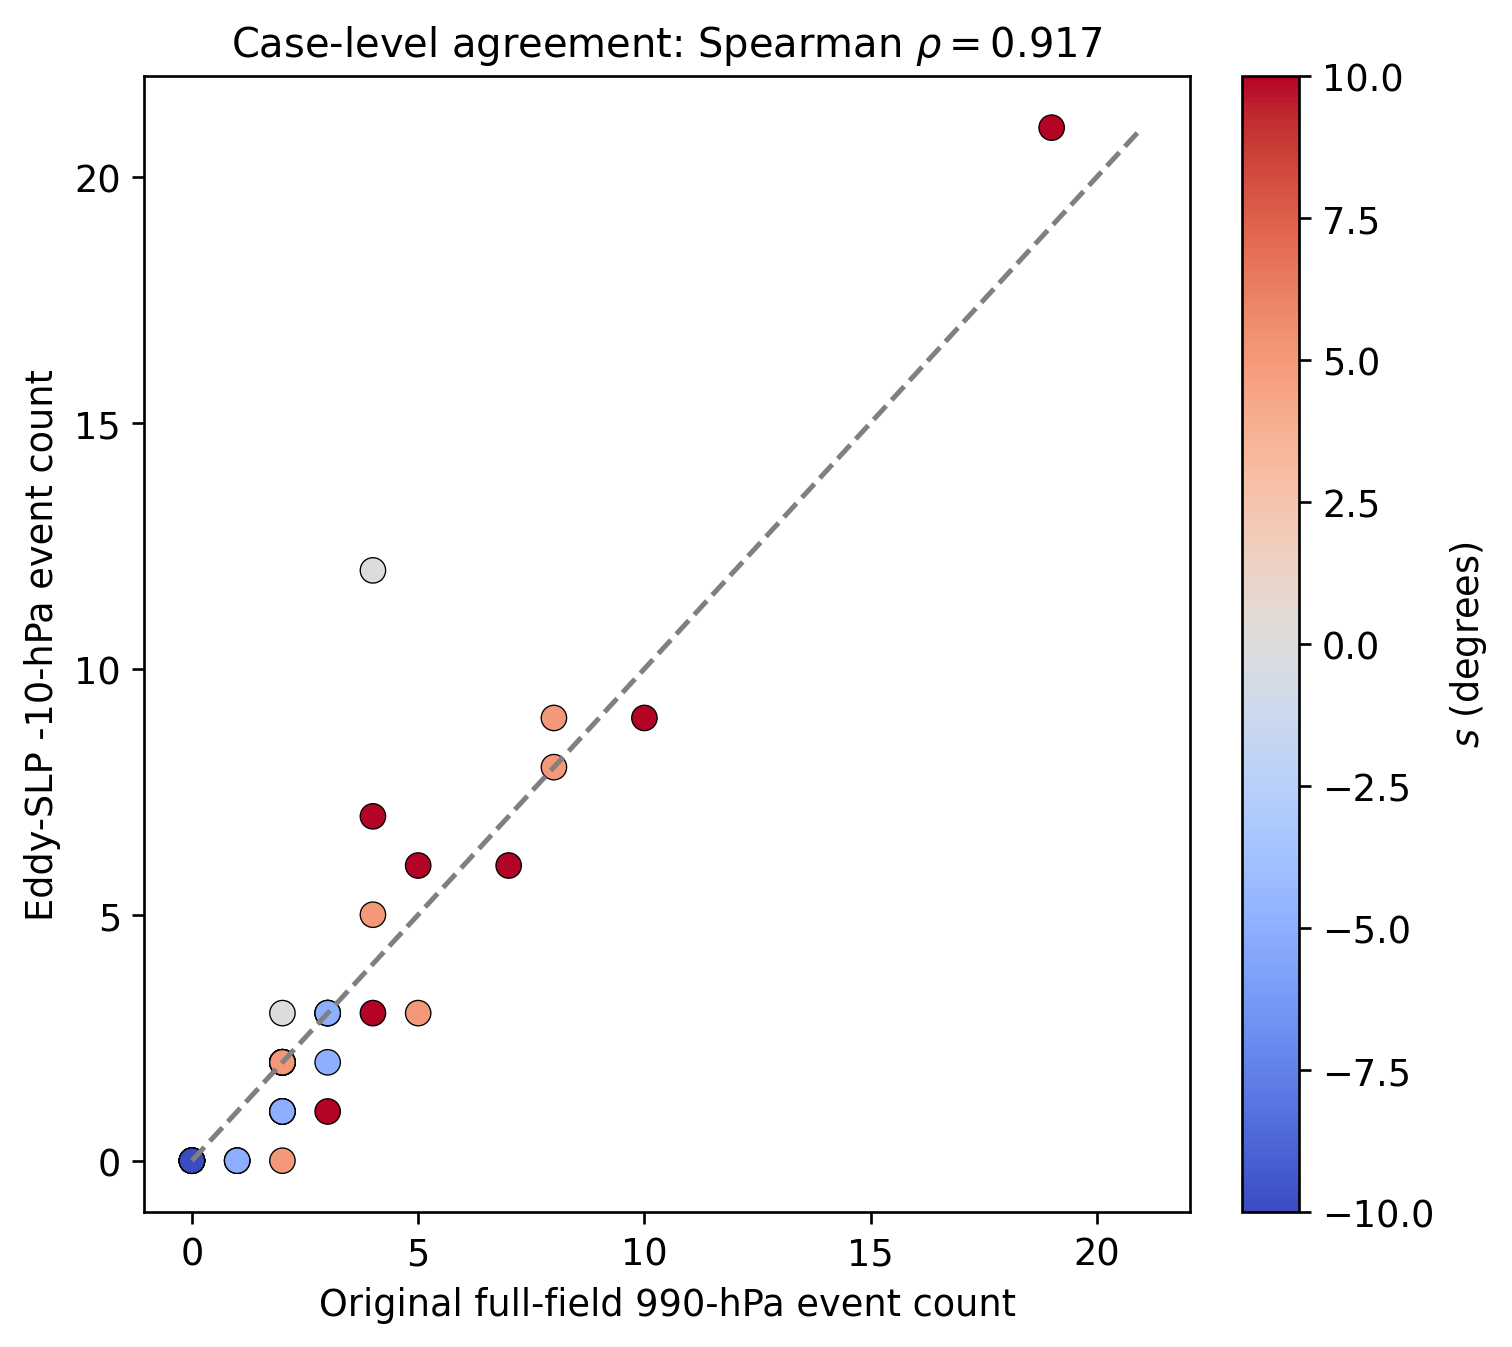

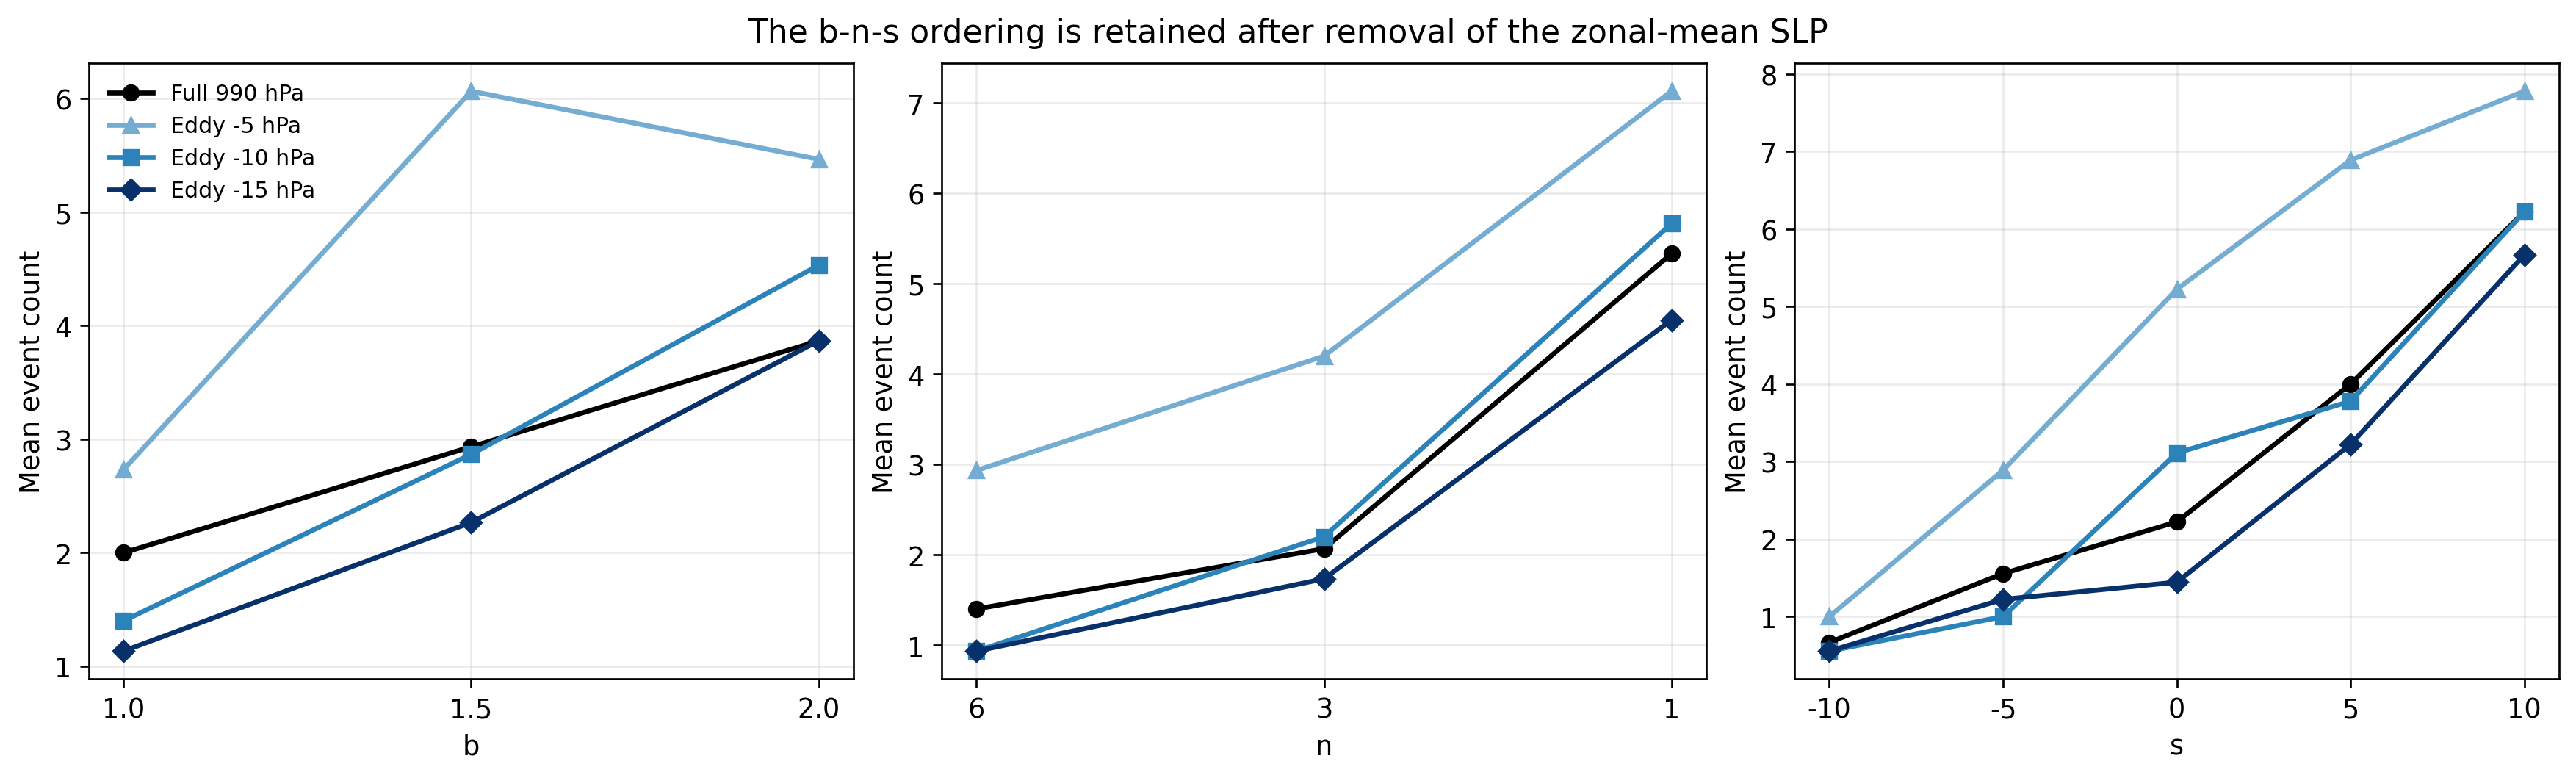

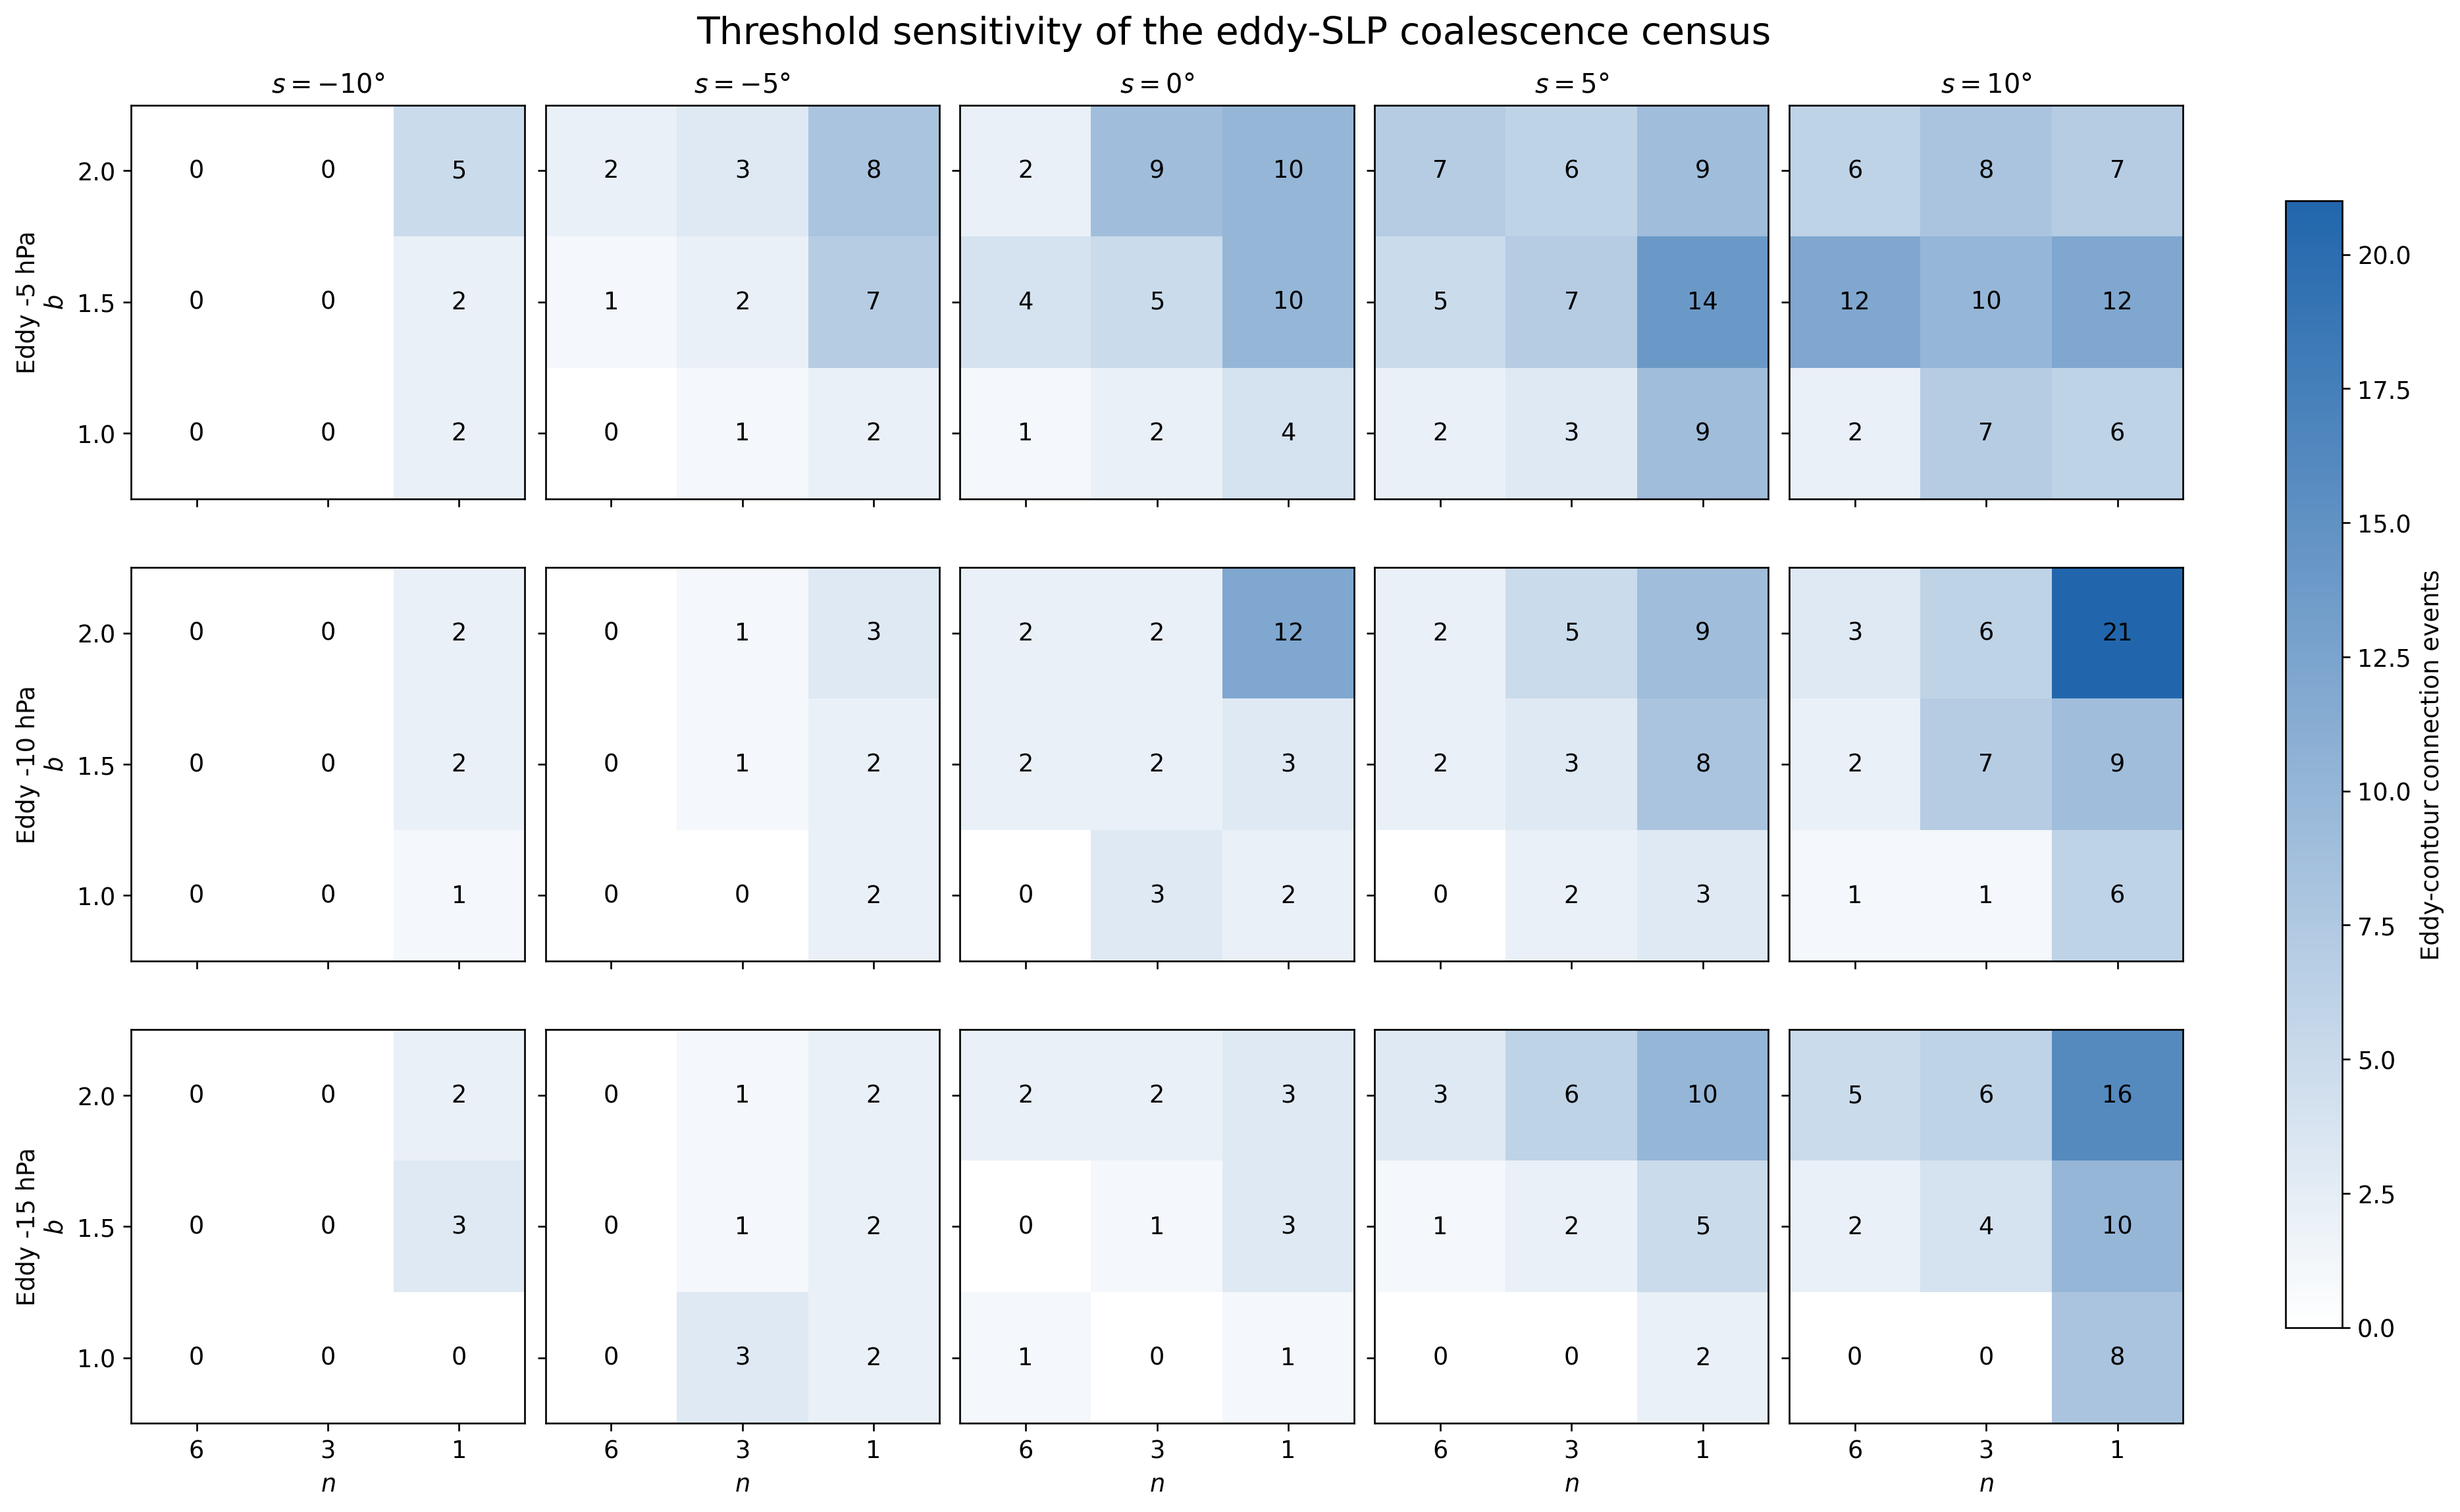

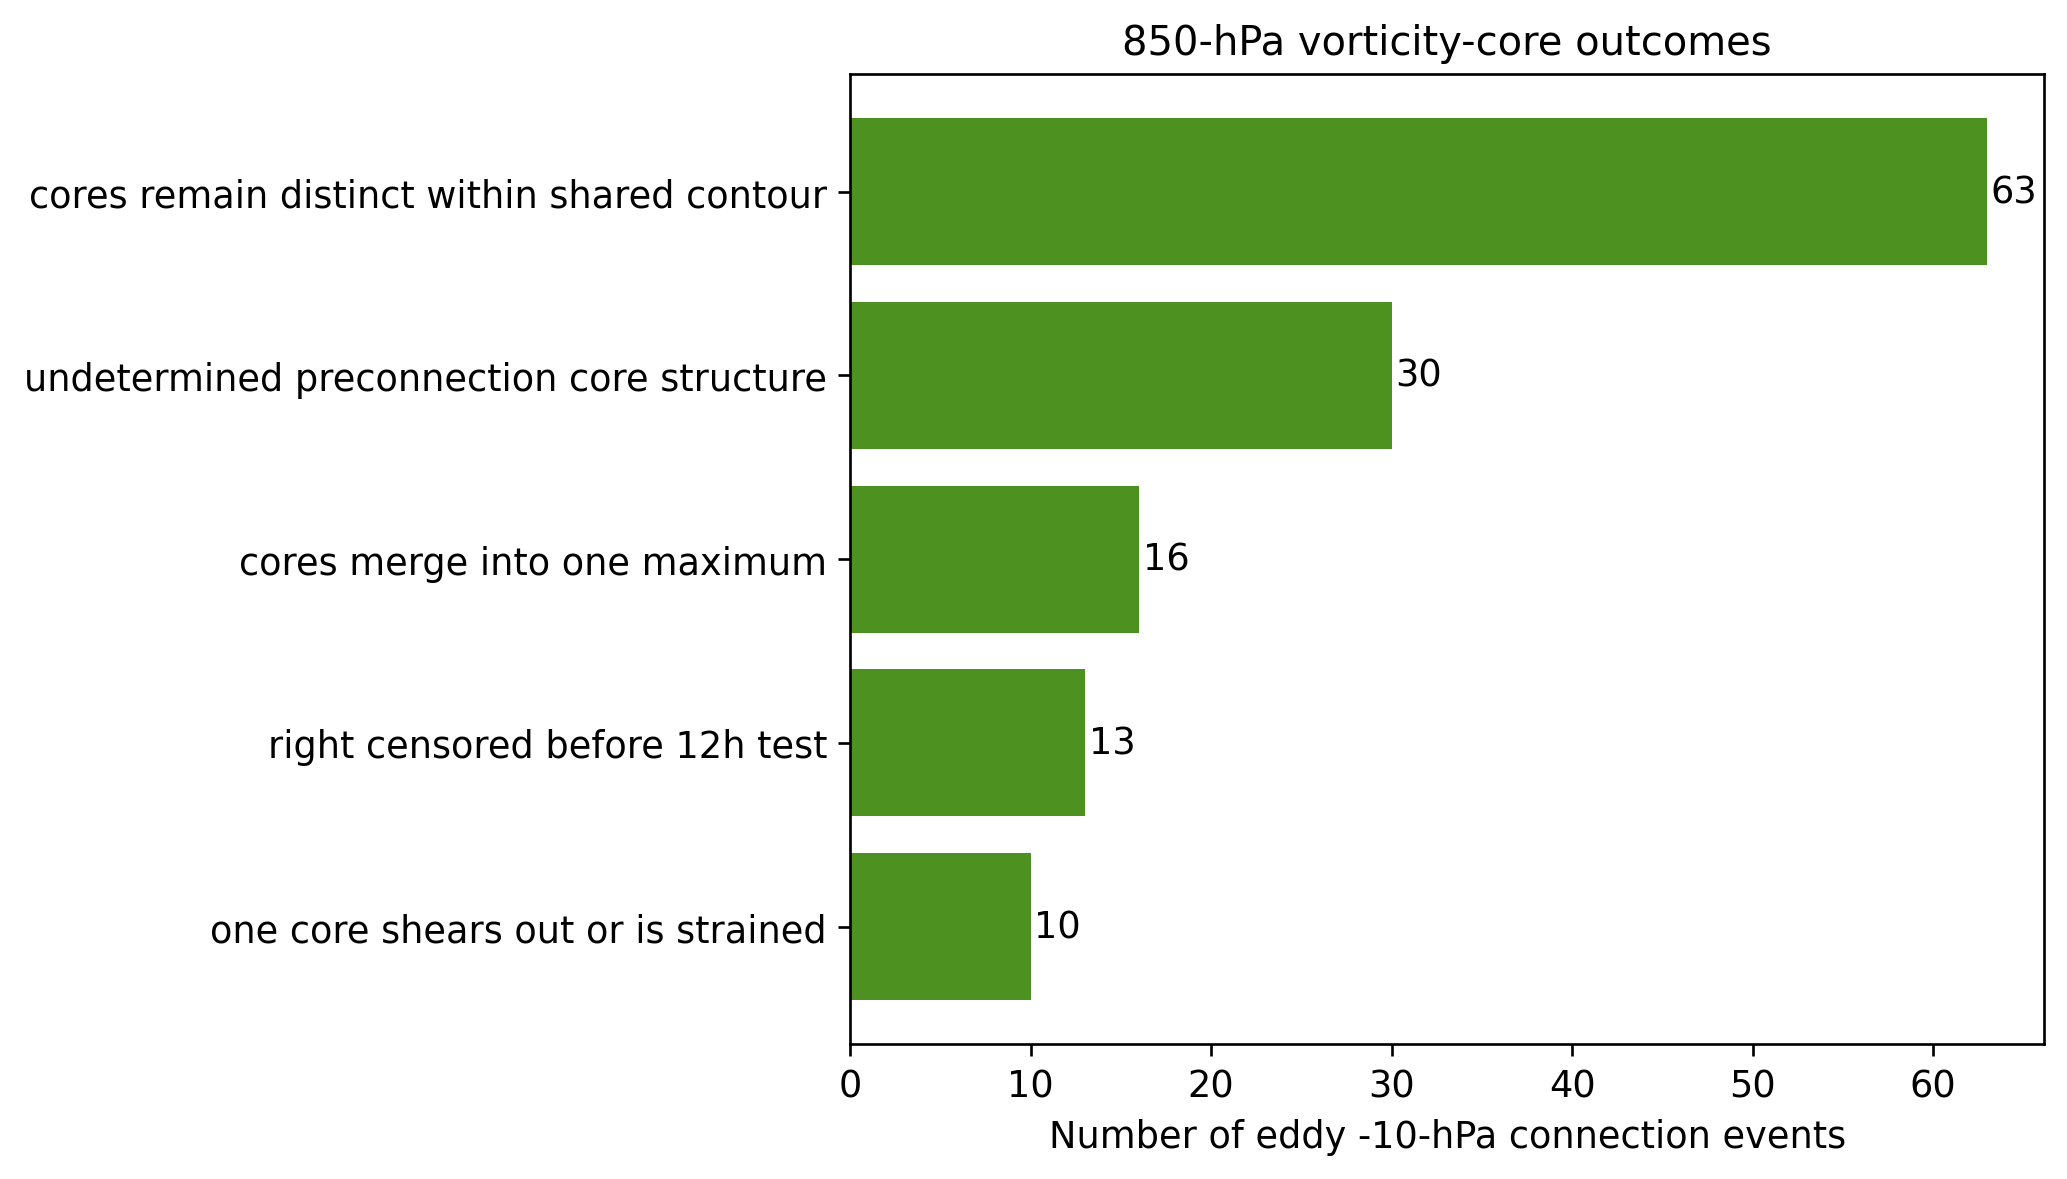

In [9]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            main()
finally:
    sys.argv = _original_argv
show_files(['eddy/eddy_full_coalescence_review_analysis_20260723/figures/figure06_case_level_full_eddy_scatter.png', 'eddy/eddy_full_coalescence_review_analysis_20260723/figures/figure03_full_eddy_group_trends.png', 'eddy/eddy_full_coalescence_review_analysis_20260723/figures/figure02_eddy_threshold_sensitivity_heatmaps.png', 'eddy/eddy_full_coalescence_review_analysis_20260723/figures/figure07_eddy_vorticity_core_outcomes.png'])


## Figures B5–B6

Original source: `eddy/eddy_full_coalescence_review_analysis_20260723/scripts/aggregate_controlled_full_eddy.py`


In [10]:
# Consolidated from eddy/eddy_full_coalescence_review_analysis_20260723/scripts/aggregate_controlled_full_eddy.py
REPO_ROOT = ROOT
__file__ = str(ROOT / 'eddy/eddy_full_coalescence_review_analysis_20260723/scripts/aggregate_controlled_full_eddy.py')

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
ROOT = REPO_ROOT
BASE = ROOT / 'eddy/eddy_full_coalescence_review_analysis_20260723'
RESULTS, TABLES, FIGURES = (BASE / 'case_results_controlled', BASE / 'tables', BASE / 'figures')
REFERENCE = ROOT / 'eddy/controlled_umax30_bns_analysis_20260722/original_style_comparison/tables/Figure10_controlled_exact_original_event_counts.csv'
B_VALUES, N_VALUES, S_VALUES = ([1.0, 1.5, 2.0], [6, 3, 1], [-10, -5, 0, 5, 10])

def load_outputs():
    summary_files = sorted(RESULTS.glob('*_summary.csv'))
    event_files = sorted(RESULTS.glob('*_events.csv'))
    partition_files = sorted(RESULTS.glob('*_full_to_eddy_partition.csv'))
    if (len(summary_files), len(event_files), len(partition_files)) != (45, 45, 45):
        raise RuntimeError(f'Incomplete: summary={len(summary_files)}, events={len(event_files)}, partition={len(partition_files)}')
    summaries = pd.concat([pd.read_csv(path) for path in summary_files], ignore_index=True)
    events = pd.concat([pd.read_csv(path) for path in event_files], ignore_index=True)
    partitions = pd.concat([pd.read_csv(path) for path in partition_files if path.stat().st_size], ignore_index=True)
    return (summaries, events, partitions)

def case_metrics(summaries, events):
    data = summaries.pivot_table(index=['case', 'b', 'n', 's'], columns=['mode', 'threshold_hpa'], values='event_count').reset_index()
    data.columns = ['case', 'b', 'n', 's', 'eddy_minus15_count', 'eddy_minus10_count', 'eddy_minus5_count', 'full_990_count']
    for threshold, column in [(-5.0, 'eddy_minus5_count'), (-10.0, 'eddy_minus10_count'), (-15.0, 'eddy_minus15_count')]:
        data[column + '_all_threshold_regions'] = data[column]
        selected = events[(events['mode'] == 'eddy') & np.isclose(events['threshold_hpa'], threshold)]
        open_boundary = selected['child_touches_south_boundary'].fillna(False).astype(bool) | selected['child_touches_north_boundary'].fillna(False).astype(bool)
        counts = selected.loc[~open_boundary].groupby('case').size()
        data[column] = data.case.map(counts).fillna(0).astype(int)
    return data

def statistics(data):
    responses = ['full_990_count', 'eddy_minus5_count', 'eddy_minus10_count', 'eddy_minus15_count']
    means_rows, rank_rows = ([], [])
    for grouping in ['b', 'n', 's']:
        means = data.groupby(grouping)[responses].mean().reset_index()
        for _, row in means.iterrows():
            for response in responses:
                means_rows.append({'grouping': grouping, 'group_value': row[grouping], 'response': response, 'mean_event_count': row[response]})
        for response in responses[1:]:
            rho, p = spearmanr(means.full_990_count, means[response])
            rank_rows.append({'grouping': grouping, 'eddy_response': response, 'spearman_rho': rho, 'p_value': p, 'n_groups': len(means)})
    for response in responses[1:]:
        rho, p = spearmanr(data.full_990_count, data[response])
        rank_rows.append({'grouping': 'case_level_45', 'eddy_response': response, 'spearman_rho': rho, 'p_value': p, 'n_groups': 45})
    group_means, ranks = (pd.DataFrame(means_rows), pd.DataFrame(rank_rows))
    group_means.to_csv(TABLES / 'controlled_full_eddy_group_means.csv', index=False)
    ranks.to_csv(TABLES / 'controlled_full_eddy_rank_agreement.csv', index=False)
    return (group_means, ranks)

def array(data, value, shift):
    return data[data.s == shift].pivot(index='b', columns='n', values=value).reindex(index=B_VALUES, columns=N_VALUES).to_numpy(float)

def plot_rows(rows, stem, title, cmap):
    vmax = max((float(data[value].max()) for _, data, value in rows))
    fig, axes = plt.subplots(len(rows), 5, figsize=(15.8, 3.0 * len(rows) + 0.9), sharex=True, sharey=True, constrained_layout=True)
    if len(rows) == 1:
        axes = axes[np.newaxis, :]
    image = None
    for r, (label, data, value) in enumerate(rows):
        for c, shift in enumerate(S_VALUES):
            values = array(data, value, shift)
            image = axes[r, c].imshow(values, origin='lower', cmap=cmap, vmin=0, vmax=vmax, aspect='equal')
            for y in range(3):
                for x in range(3):
                    axes[r, c].text(x, y, f'{values[y, x]:.0f}', ha='center', va='center', fontsize=11)
            if r == 0:
                axes[r, c].set_title(f'$s={shift}°$', fontsize=14)
            axes[r, c].set_xticks(range(3), N_VALUES)
            axes[r, c].set_yticks(range(3), ['1.0', '1.5', '2.0'])
            if r == len(rows) - 1:
                axes[r, c].set_xlabel('$n$ (wider jet →)')
            if c == 0:
                axes[r, c].set_ylabel(label + '\n$b$')
    fig.colorbar(image, ax=axes, label='Connection events per simulation', shrink=0.88)
    fig.suptitle(title, fontsize=17)
    fig.savefig(FIGURES / (stem + '.png'), dpi=240, bbox_inches='tight')
    fig.savefig(FIGURES / (stem + '.pdf'), bbox_inches='tight')
    plt.close(fig)

def main():
    TABLES.mkdir(exist_ok=True)
    FIGURES.mkdir(exist_ok=True)
    summaries, events, partitions = load_outputs()
    data = case_metrics(summaries, events)
    data.to_csv(TABLES / 'controlled_full_eddy_case_metrics.csv', index=False)
    reference = pd.read_csv(REFERENCE)
    verify = data.merge(reference[['case', 'figure10_coalescence_event_count']], on='case', how='left')
    verify['difference'] = verify.full_990_count - verify.figure10_coalescence_event_count
    verify.to_csv(TABLES / 'controlled_full_990_exact_verification.csv', index=False)
    if len(verify) != 45 or not (verify.difference == 0).all():
        raise RuntimeError('Controlled full-field validation failed')
    _, ranks = statistics(data)
    case_partitions = []
    for _, case in data.iterrows():
        selected = partitions[partitions.case == case.case]
        matched = int(selected.matched_eddy_event.sum()) if len(selected) else 0
        full = int(case.full_990_count)
        case_partitions.append({'case': case.case, 'b': case.b, 'n': case.n, 's': case.s, 'full_990_count': full, 'matched_by_eddy_minus10': matched, 'full_only_count': full - matched, 'matched_fraction': matched / full if full else np.nan})
    case_partitions = pd.DataFrame(case_partitions)
    case_partitions.to_csv(TABLES / 'controlled_full_to_eddy_partition_by_case.csv', index=False)
    archive = pd.read_csv(TABLES / 'full_eddy_case_metrics.csv')
    red = LinearSegmentedColormap.from_list('white_red_controlled', ['#fff', '#f00'])
    blue = LinearSegmentedColormap.from_list('white_blue_controlled', ['#fff', '#2166ac'])
    plot_rows([('Controlled full field, 990 hPa', data, 'full_990_count'), ('Controlled eddy SLP, -10 hPa', data, 'eddy_minus10_count')], 'figure10_controlled_full990_vs_eddy_minus10_direct_comparison', 'Fixed-$U_{max}=30$ m s$^{-1}$: full-field versus eddy-SLP census', red)
    plot_rows([('Archive full field, 990 hPa', archive, 'full_990_count'), ('Archive eddy SLP, -10 hPa', archive, 'eddy_minus10_count'), ('Controlled full field, 990 hPa', data, 'full_990_count'), ('Controlled eddy SLP, -10 hPa', data, 'eddy_minus10_count')], 'figure11_archive_controlled_full_eddy_four_row_comparison', 'Archive and fixed-$U_{max}$ ensembles: full-field and eddy-SLP comparison', red)
    plot_rows([('Controlled eddy -5 hPa', data, 'eddy_minus5_count'), ('Controlled eddy -10 hPa', data, 'eddy_minus10_count'), ('Controlled eddy -15 hPa', data, 'eddy_minus15_count')], 'figure12_controlled_eddy_threshold_sensitivity', 'Fixed-$U_{max}$ controlled ensemble: eddy-SLP threshold sensitivity', blue)
    rho = ranks[(ranks.grouping == 'case_level_45') & (ranks.eddy_response == 'eddy_minus10_count')].spearman_rho.iloc[0]
    lines = [f'Controlled full 990-hPa total events: {int(data.full_990_count.sum())}', f'Controlled closed eddy totals (-5, -10, -15 hPa): {int(data.eddy_minus5_count.sum())}, {int(data.eddy_minus10_count.sum())}, {int(data.eddy_minus15_count.sum())}', 'Controlled full exact-reference mismatches: 0/45', f'Controlled case-level full versus eddy -10 Spearman rho: {rho:.6f}', f'Controlled full-event partition: matched={int(case_partitions.matched_by_eddy_minus10.sum())}/{int(case_partitions.full_990_count.sum())}; full-only={int(case_partitions.full_only_count.sum())}']
    (TABLES / 'controlled_analysis_summary.txt').write_text('\n'.join(lines) + '\n')
    print('\n'.join(lines))


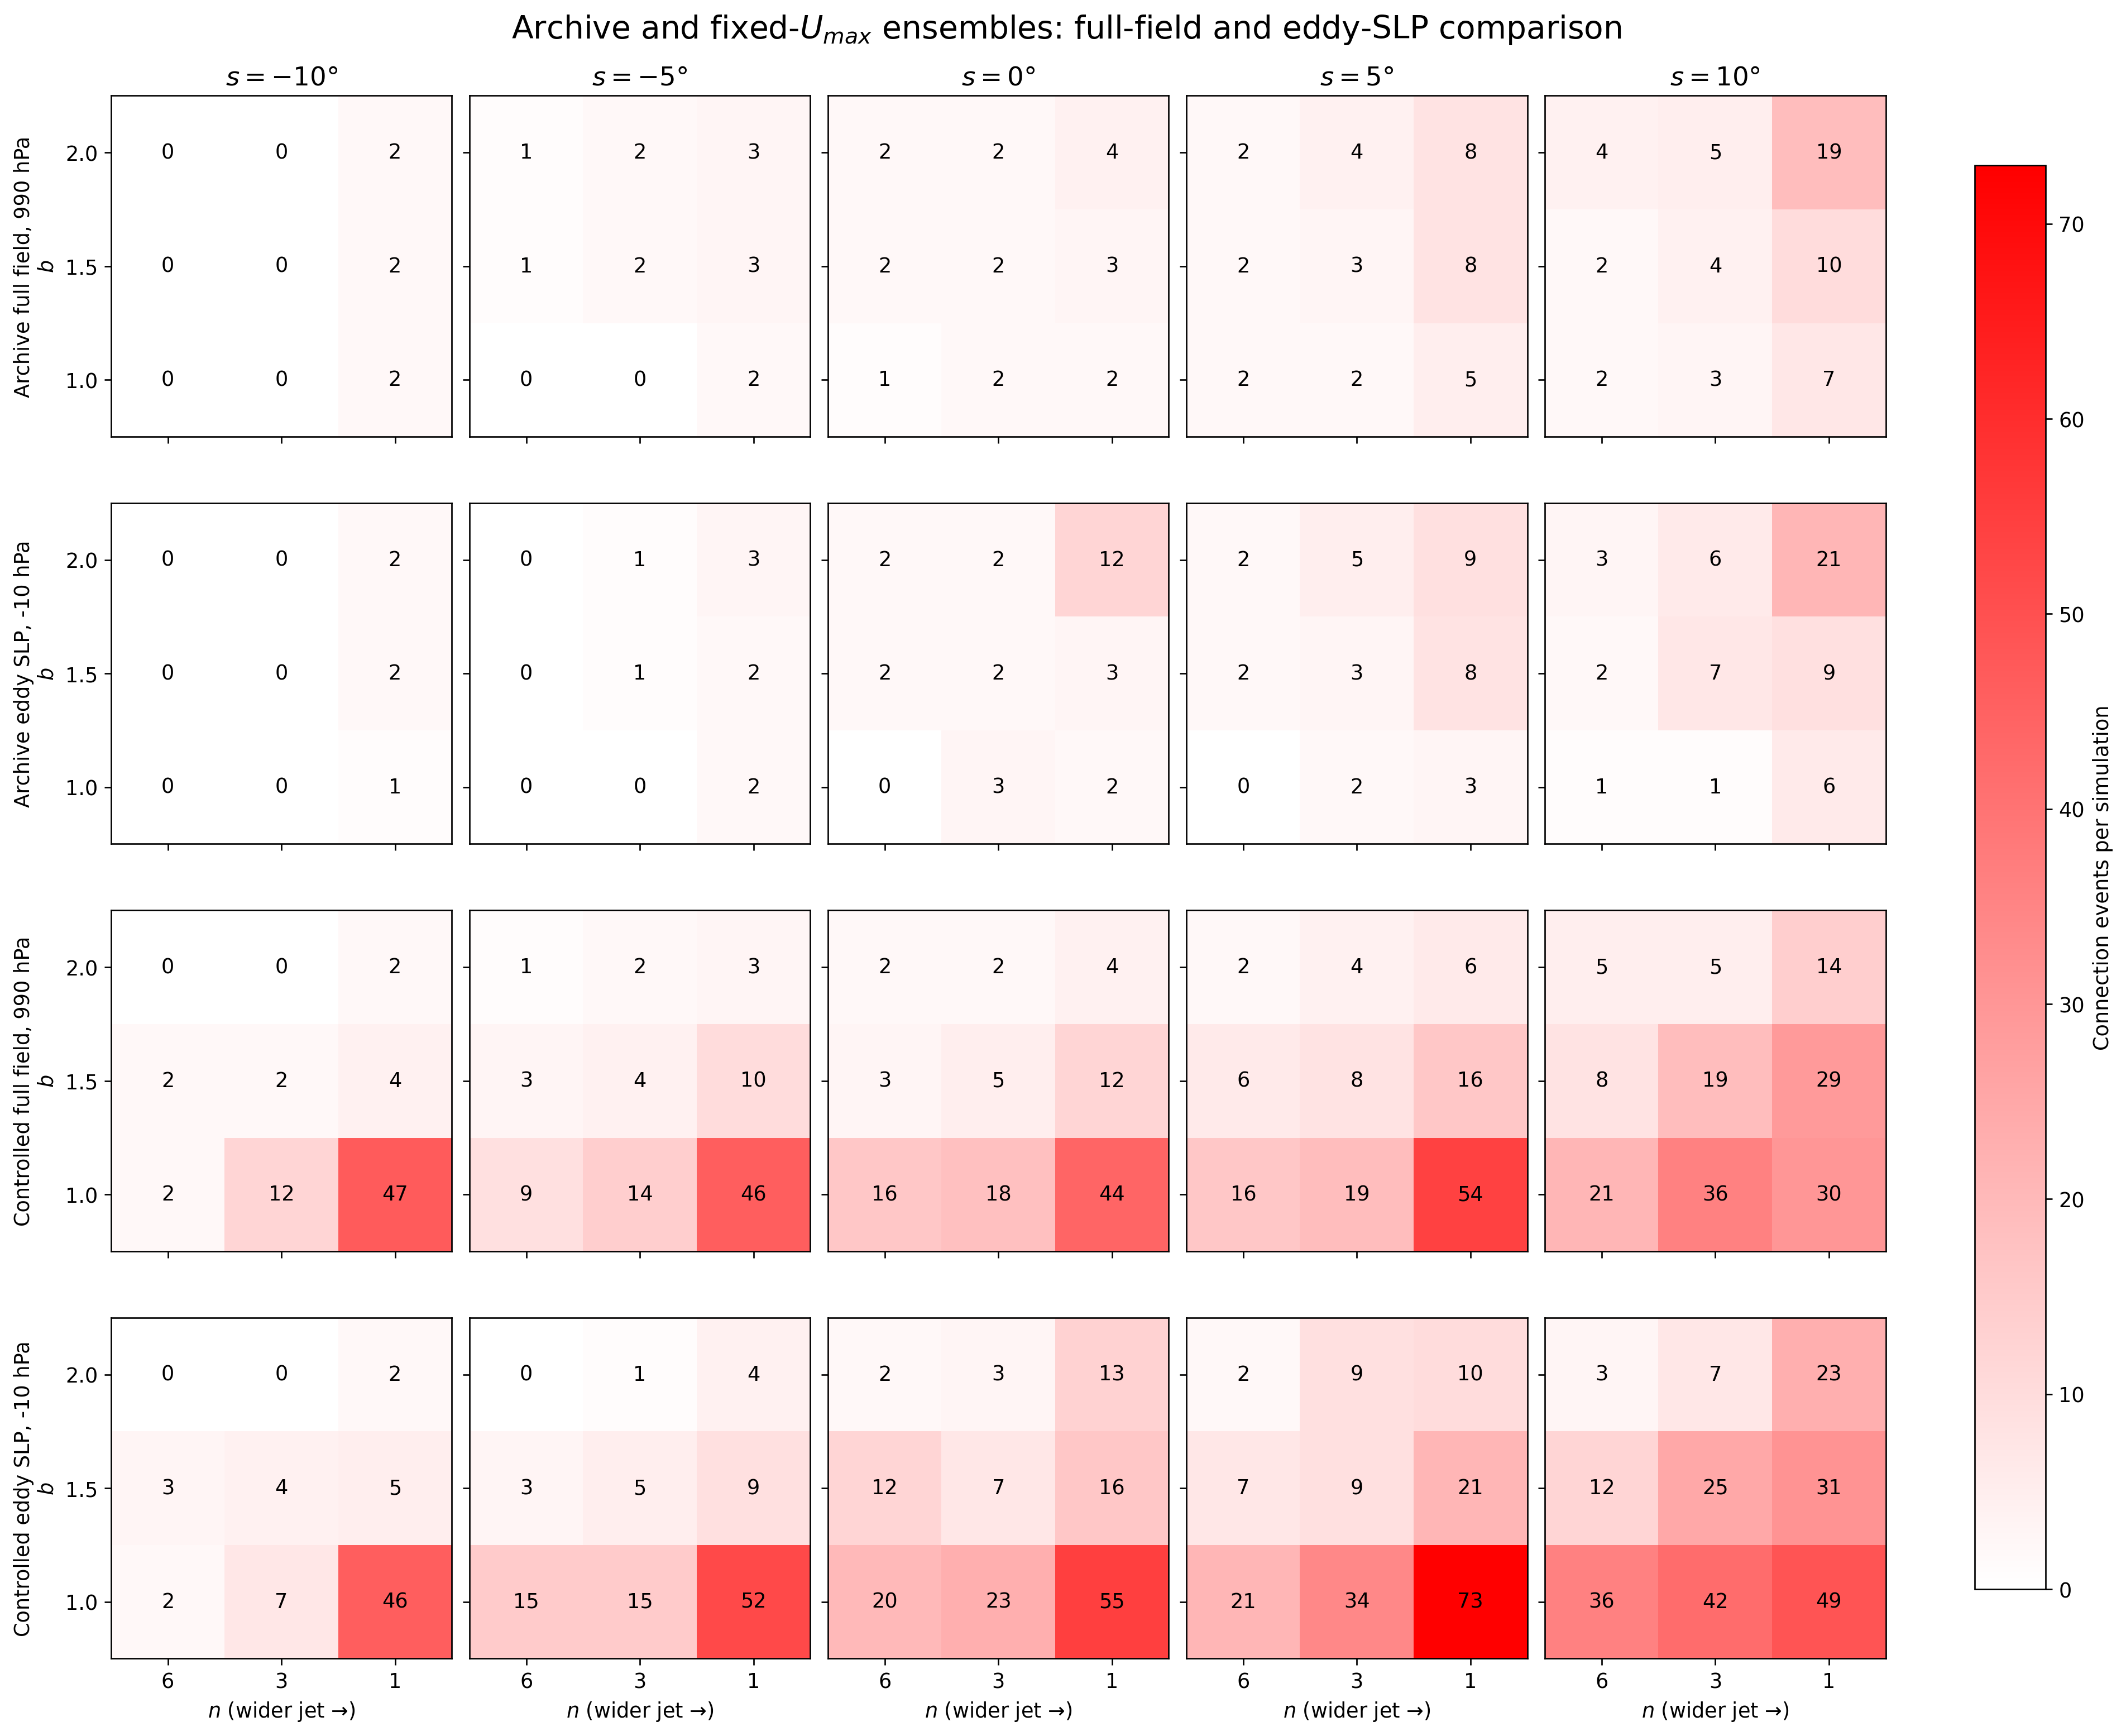

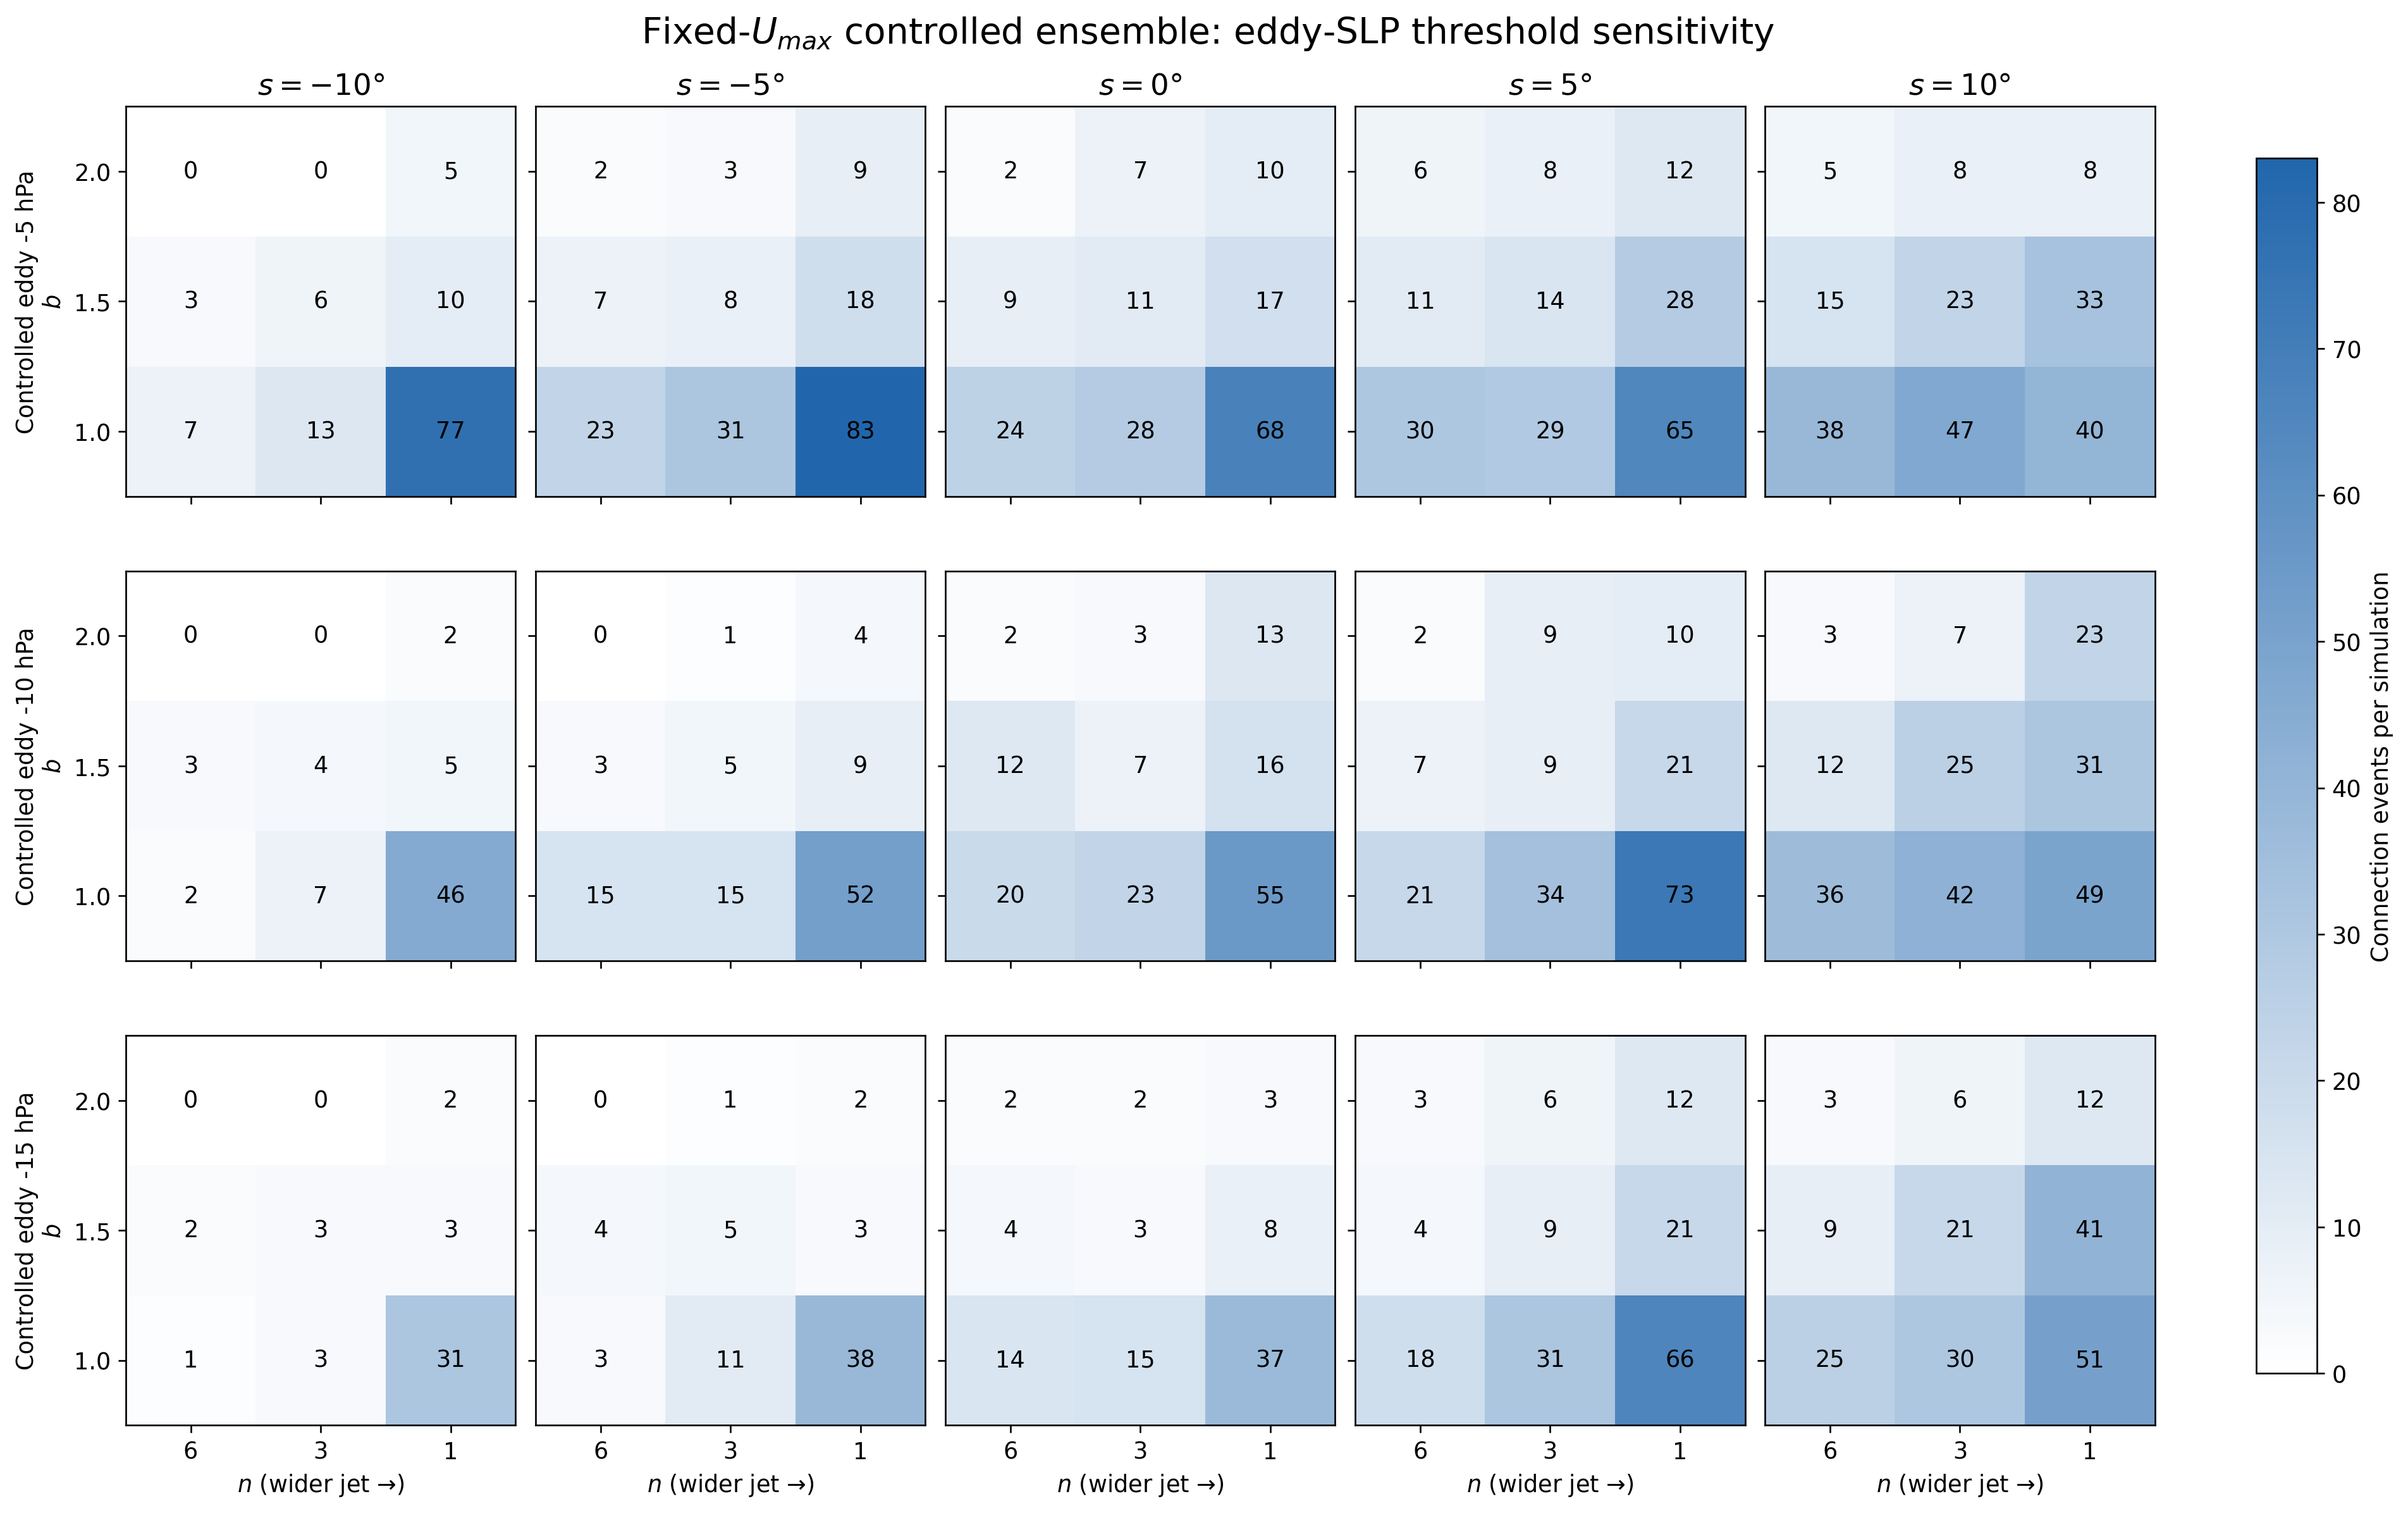

In [11]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            main()
finally:
    sys.argv = _original_argv
show_files(['eddy/eddy_full_coalescence_review_analysis_20260723/figures/figure11_archive_controlled_full_eddy_four_row_comparison.png', 'eddy/eddy_full_coalescence_review_analysis_20260723/figures/figure12_controlled_eddy_threshold_sensitivity.png'])


## Figures C1–C2

Original source: `eddy/rwb_post_onset_analysis_20260722/scripts/build_rwb_post_onset_analysis.py`


In [12]:
# Consolidated from eddy/rwb_post_onset_analysis_20260722/scripts/build_rwb_post_onset_analysis.py
REPO_ROOT = ROOT
__file__ = str(ROOT / 'eddy/rwb_post_onset_analysis_20260722/scripts/build_rwb_post_onset_analysis.py')

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
ROOT = Path(__file__).resolve().parents[3]
OUT = ROOT / 'eddy' / 'rwb_post_onset_analysis_20260722'
FIGURES = OUT / 'figures'
TABLES = OUT / 'tables'
SOURCE_TABLES = ROOT / 'priority_revision_analysis_20260720' / 'tables'
TRACK_SUMMARY = ROOT / 'paper_revision' / 'supplemental_analysis' / 'rwb_linked_track_vs_object_time_by_case.csv'
PARAMETERS = [('s', [-10, -5, 0, 5, 10], 'Jet-latitude shift, $s$ (°)'), ('n', [1, 3, 6], 'Jet-width parameter, $n$'), ('b', [1.0, 1.5, 2.0], 'Vertical-profile parameter, $b$')]
METRICS = [('full_window_object_time_detections', 'Full-window detections', 'Object-time detections'), ('post_onset_duration_hours', 'Available post-onset duration', 'Hours'), ('post_onset_rwb_rate_per_day', 'Post-onset occurrence rate', 'Detections day$^{-1}$')]

def load_case_table() -> pd.DataFrame:
    raw = pd.read_csv(TRACK_SUMMARY)
    post = pd.read_csv(SOURCE_TABLES / 'rwb_post_onset_by_case.csv')
    by_track = pd.read_csv(SOURCE_TABLES / 'rwb_track_post_onset_by_track.csv')
    post_unique = by_track.assign(has_post=lambda frame: frame['post_onset_object_time_detections'].gt(0)).groupby('case', as_index=False)['has_post'].sum().rename(columns={'has_post': 'post_onset_unique_tracks'})
    data = raw[['case', 'b', 'n', 's', 'n_unique_linked_tracks', 'n_object_time_detections']].merge(post, on='case', how='inner', validate='one_to_one')
    data = data.merge(post_unique, on='case', how='left', validate='one_to_one')
    data = data.rename(columns={'n_object_time_detections': 'full_window_object_time_detections', 'n_unique_linked_tracks': 'full_window_unique_tracks', 'post_onset_steps': 'post_onset_duration_hours', 'post_onset_rwb_rate': 'post_onset_rwb_rate_per_hour'})
    data['post_onset_unique_tracks'] = data['post_onset_unique_tracks'].fillna(0).astype(int)
    data['post_onset_rwb_rate_per_day'] = 24.0 * data['post_onset_rwb_rate_per_hour']
    data['growth_onset_index'] = 360.0 - data['post_onset_duration_hours']
    data = data.sort_values(['b', 'n', 's', 'case']).reset_index(drop=True)
    if len(data) != 44:
        raise RuntimeError(f'Expected 44 archive cases with RWB tracks, found {len(data)}')
    if data['case'].duplicated().any():
        raise RuntimeError('Duplicate cases found in merged RWB table')
    if not np.allclose(data['post_onset_rwb_rate_per_hour'], data['post_onset_object_time_detections'] / data['post_onset_duration_hours']):
        raise RuntimeError('Stored occurrence rates do not match count/duration')
    return data

def grouped_summary(data: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for parameter, values, _ in PARAMETERS:
        for value in values:
            group = data[np.isclose(data[parameter].astype(float), float(value))]
            rows.append({'parameter': parameter, 'value': value, 'n_cases': len(group), 'mean_full_window_detections': group['full_window_object_time_detections'].mean(), 'mean_post_onset_detections': group['post_onset_object_time_detections'].mean(), 'mean_post_onset_duration_hours': group['post_onset_duration_hours'].mean(), 'mean_post_onset_unique_tracks': group['post_onset_unique_tracks'].mean(), 'mean_post_onset_rate_per_hour': group['post_onset_rwb_rate_per_hour'].mean(), 'mean_post_onset_rate_per_day': group['post_onset_rwb_rate_per_day'].mean(), 'median_post_onset_rate_per_day': group['post_onset_rwb_rate_per_day'].median()})
    return pd.DataFrame(rows)

def jitter_positions(count: int, width: float=0.12) -> np.ndarray:
    if count <= 1:
        return np.zeros(count)
    return np.linspace(-width, width, count)

def make_grouped_figure(data: pd.DataFrame) -> None:
    figure, axes = plt.subplots(3, 3, figsize=(11.2, 9.1), constrained_layout=True)
    colors = ['#4C78A8', '#72B7B2', '#E45756']
    for column, (parameter, values, xlabel) in enumerate(PARAMETERS):
        for row, (metric, title, ylabel) in enumerate(METRICS):
            axis = axes[row, column]
            means = []
            for position, value in enumerate(values):
                subset = data[np.isclose(data[parameter].astype(float), float(value))].sort_values('case')
                y = subset[metric].to_numpy(dtype=float)
                x = position + jitter_positions(len(y))
                axis.scatter(x, y, s=24, color=colors[row], alpha=0.48, edgecolor='none', zorder=2)
                means.append(float(np.mean(y)))
            axis.plot(range(len(values)), means, 'o-', color='#222222', linewidth=1.8, markersize=5, zorder=3)
            axis.set_xticks(range(len(values)), [f'{value:g}' for value in values])
            axis.grid(axis='y', alpha=0.22)
            if row == 0:
                axis.set_title(f'Grouped by ${parameter}$')
            if column == 0:
                axis.set_ylabel(ylabel)
            if row == 2:
                axis.set_xlabel(xlabel)
            axis.text(0.03, 0.94, title, transform=axis.transAxes, va='top', fontsize=9, fontweight='bold')
    figure.suptitle('RWB object-time detections, available post-onset duration, and normalized occurrence rate', fontsize=13)
    figure.savefig(FIGURES / 'rwb_full_post_onset_and_rate_by_parameters.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'rwb_full_post_onset_and_rate_by_parameters.pdf', bbox_inches='tight')
    plt.close(figure)

def make_rate_heatmaps(data: pd.DataFrame) -> None:
    s_values = [-10, -5, 0, 5, 10]
    n_values = [1, 3, 6]
    b_values = [2.0, 1.5, 1.0]
    arrays = []
    for s_value in s_values:
        subset = data[np.isclose(data['s'], s_value)]
        arrays.append(subset.pivot(index='b', columns='n', values='post_onset_rwb_rate_per_day').reindex(index=b_values, columns=n_values).to_numpy(dtype=float))
    finite = np.concatenate([array[np.isfinite(array)] for array in arrays])
    vmax = float(np.nanpercentile(finite, 95))
    figure, axes = plt.subplots(1, 5, figsize=(12.3, 3.2), sharex=True, sharey=True, constrained_layout=True)
    image = None
    for axis, s_value, array in zip(axes, s_values, arrays):
        image = axis.imshow(array, cmap='YlOrRd', vmin=0.0, vmax=vmax, aspect='auto')
        for i in range(array.shape[0]):
            for j in range(array.shape[1]):
                value = array[i, j]
                label = 'NA' if not np.isfinite(value) else f'{value:.1f}'
                color = 'black' if not np.isfinite(value) or value < 0.62 * vmax else 'white'
                axis.text(j, i, label, ha='center', va='center', fontsize=8, color=color)
        axis.set_title(f'$s={s_value:g}°$')
        axis.set_xticks(range(len(n_values)), [str(value) for value in n_values])
        axis.set_xlabel('$n$')
    axes[0].set_yticks(range(len(b_values)), [f'{value:g}' for value in b_values])
    axes[0].set_ylabel('$b$')
    figure.colorbar(image, ax=axes, label='Post-onset RWB detections day$^{-1}$', shrink=0.86)
    figure.suptitle('Case-level post-onset RWB occurrence rate', fontsize=13)
    figure.savefig(FIGURES / 'rwb_post_onset_rate_heatmaps.png', dpi=240, bbox_inches='tight')
    figure.savefig(FIGURES / 'rwb_post_onset_rate_heatmaps.pdf', bbox_inches='tight')
    plt.close(figure)

def write_key_statistics(data: pd.DataFrame, grouped: pd.DataFrame) -> None:
    raw_rate_rho, raw_rate_p = spearmanr(data['full_window_object_time_detections'], data['post_onset_rwb_rate_per_hour'])
    post_rate_rho, post_rate_p = spearmanr(data['post_onset_object_time_detections'], data['post_onset_rwb_rate_per_hour'])
    onset_rate_rho, onset_rate_p = spearmanr(data['growth_onset_index'], data['post_onset_rwb_rate_per_hour'])
    lines = ['# Key RWB post-onset statistics', '', f'- Archive coverage: {len(data)}/45 cases; `BCwave_b1n6s-10` lacks an archived linked-track product.', f"- Mean post-onset duration: {data['post_onset_duration_hours'].mean():.1f} h (range {data['post_onset_duration_hours'].min():.0f}–{data['post_onset_duration_hours'].max():.0f} h).", f'- Full-window detections versus post-onset rate: Spearman rho={raw_rate_rho:.2f}, p={raw_rate_p:.3g}.', f'- Post-onset detections versus post-onset rate: Spearman rho={post_rate_rho:.2f}, p={post_rate_p:.3g}.', f'- Growth-onset index versus post-onset rate: Spearman rho={onset_rate_rho:.2f}, p={onset_rate_p:.3g}.', '', '## Group means', '']
    for parameter in ['n', 'b', 's']:
        lines.append(f'### {parameter}')
        lines.append('')
        lines.append('| Value | Cases | Full-window detections | Post-onset detections | Post-onset duration (h) | Unique post-onset tracks | Rate (h^-1) | Rate (day^-1) |')
        lines.append('|---:|---:|---:|---:|---:|---:|---:|---:|')
        subset = grouped[grouped['parameter'].eq(parameter)]
        for row in subset.to_dict('records'):
            lines.append(f"| {row['value']:g} | {int(row['n_cases'])} | {row['mean_full_window_detections']:.1f} | {row['mean_post_onset_detections']:.1f} | {row['mean_post_onset_duration_hours']:.1f} | {row['mean_post_onset_unique_tracks']:.1f} | {row['mean_post_onset_rate_per_hour']:.3f} | {row['mean_post_onset_rate_per_day']:.2f} |")
        lines.append('')
    (TABLES / 'rwb_post_onset_key_statistics.md').write_text('\n'.join(lines) + '\n', encoding='utf-8')

def main() -> None:
    FIGURES.mkdir(parents=True, exist_ok=True)
    TABLES.mkdir(parents=True, exist_ok=True)
    data = load_case_table()
    grouped = grouped_summary(data)
    data.to_csv(TABLES / 'rwb_post_onset_case_summary.csv', index=False)
    grouped.to_csv(TABLES / 'rwb_post_onset_grouped_summary.csv', index=False)
    make_grouped_figure(data)
    make_rate_heatmaps(data)
    write_key_statistics(data, grouped)
    print(data[['case', 'post_onset_duration_hours', 'post_onset_unique_tracks', 'post_onset_rwb_rate_per_day']].to_string(index=False))


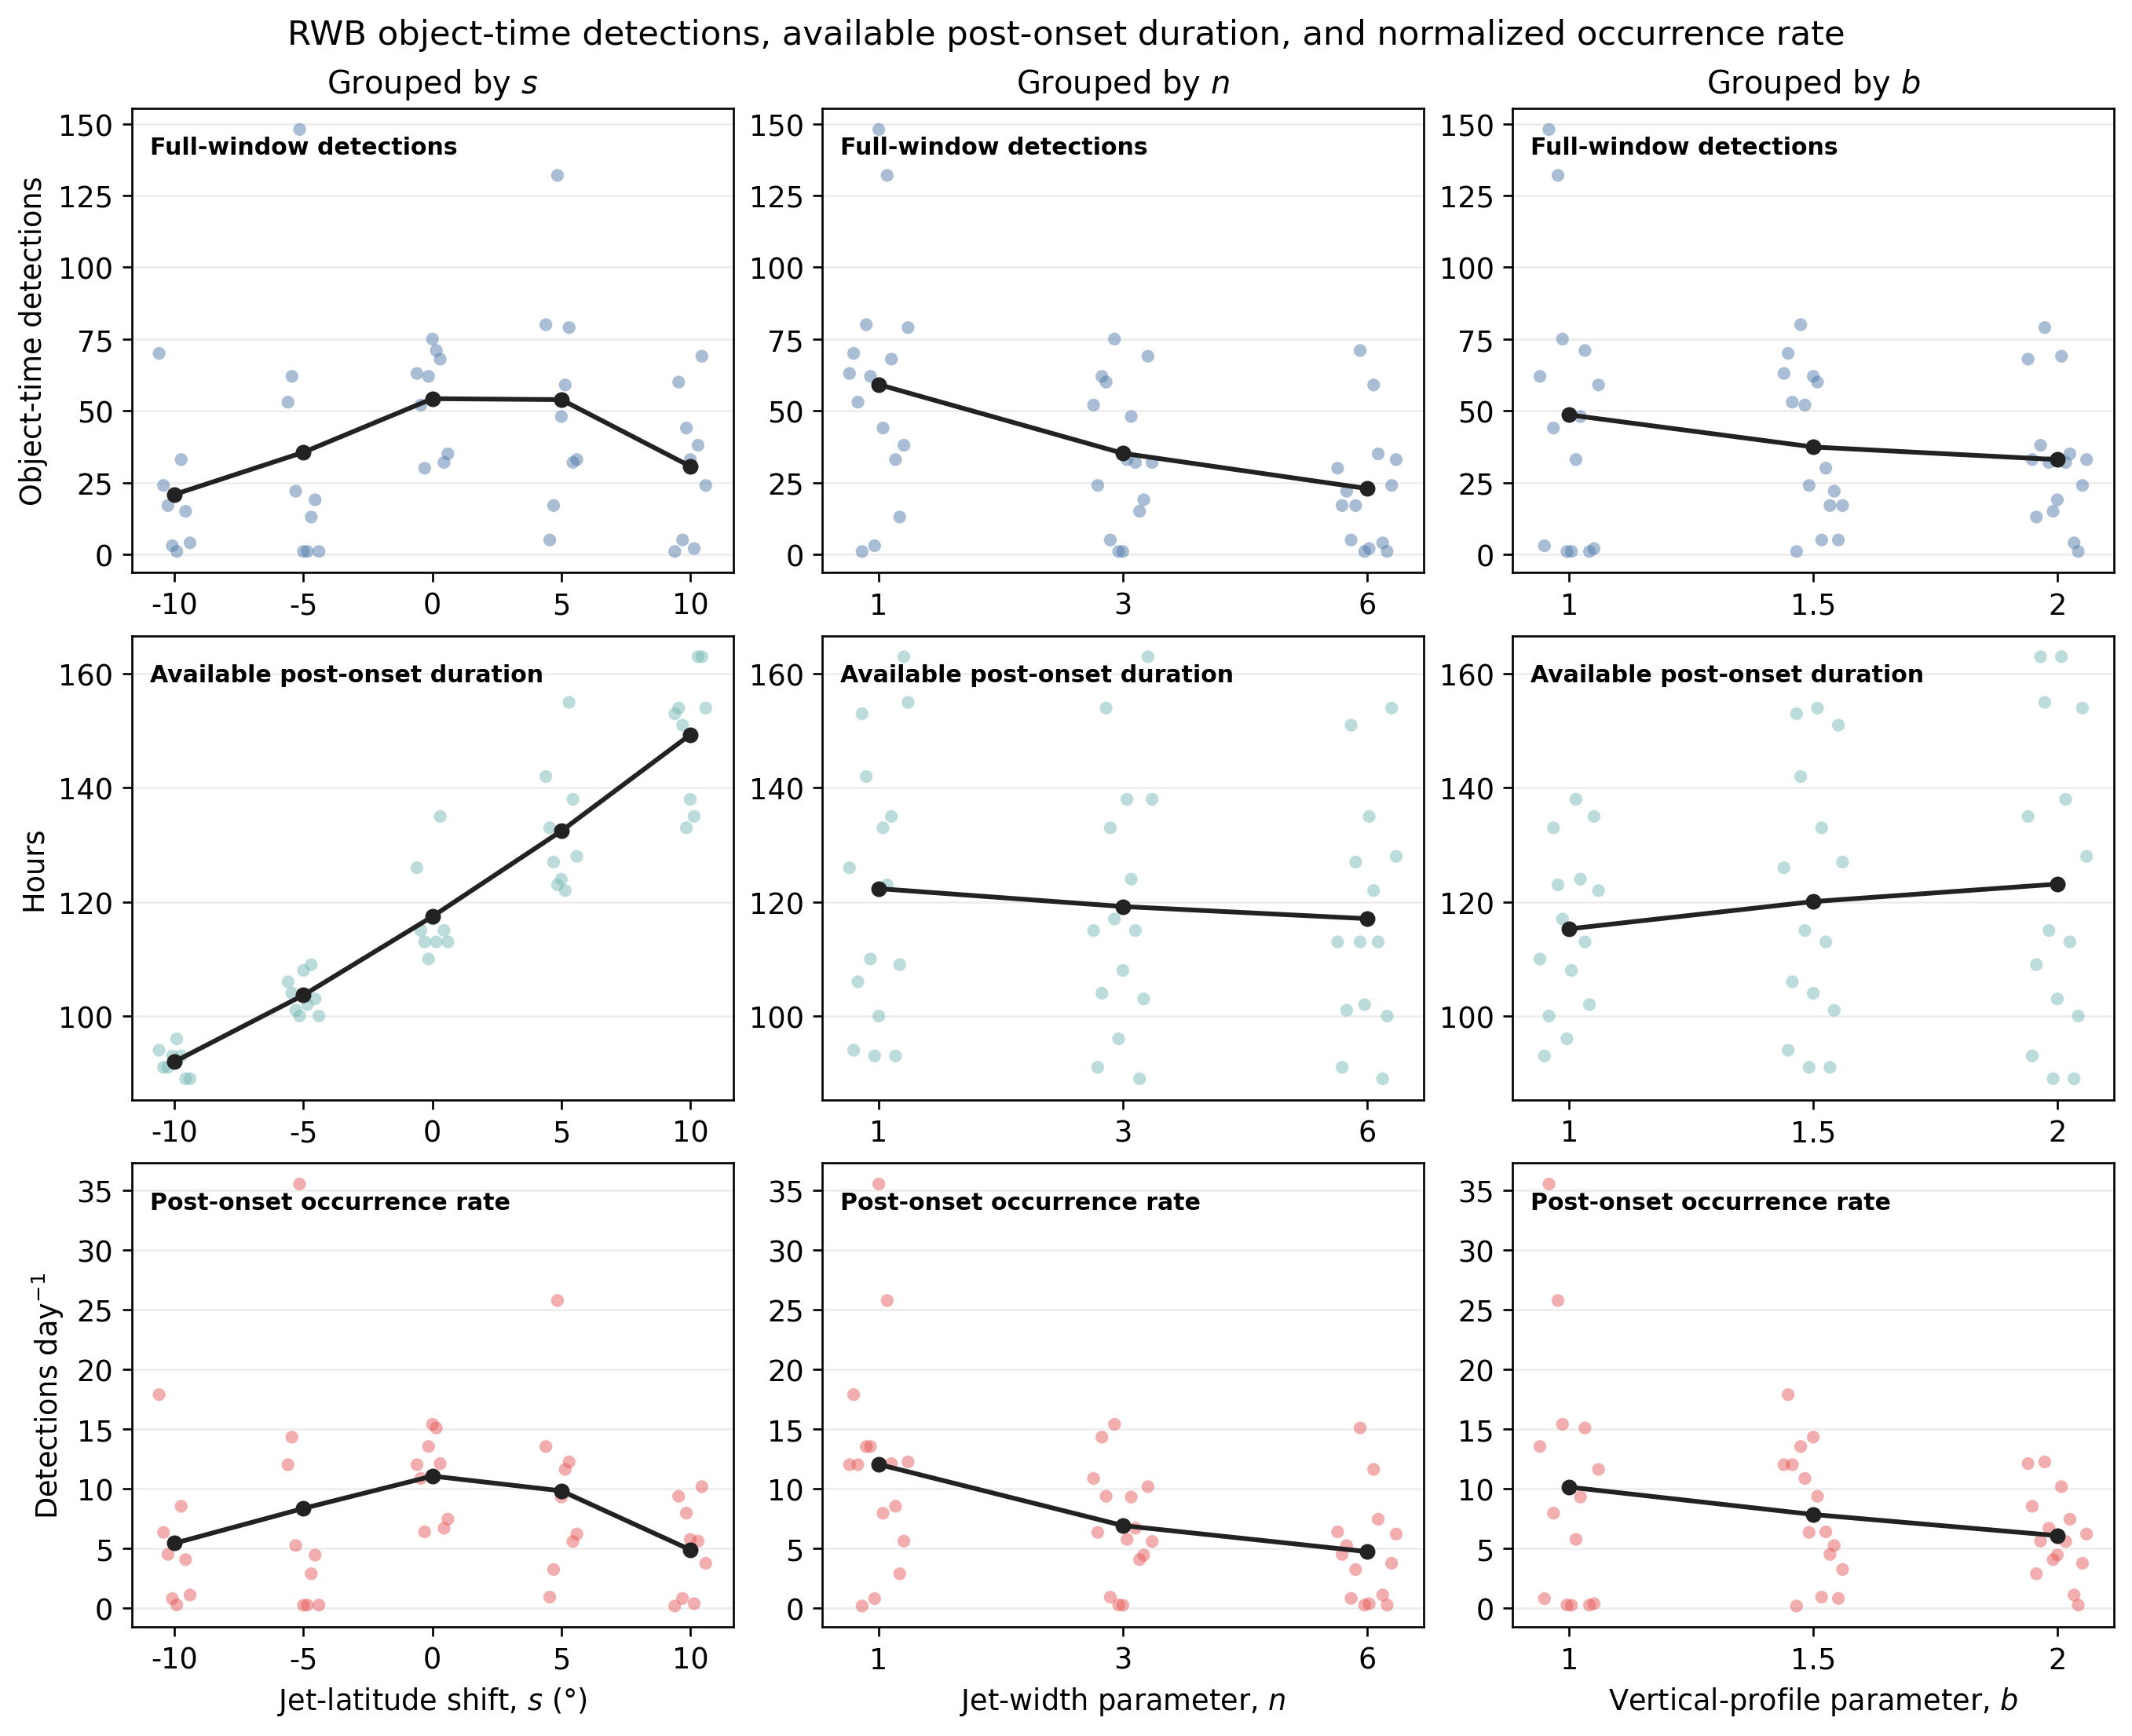

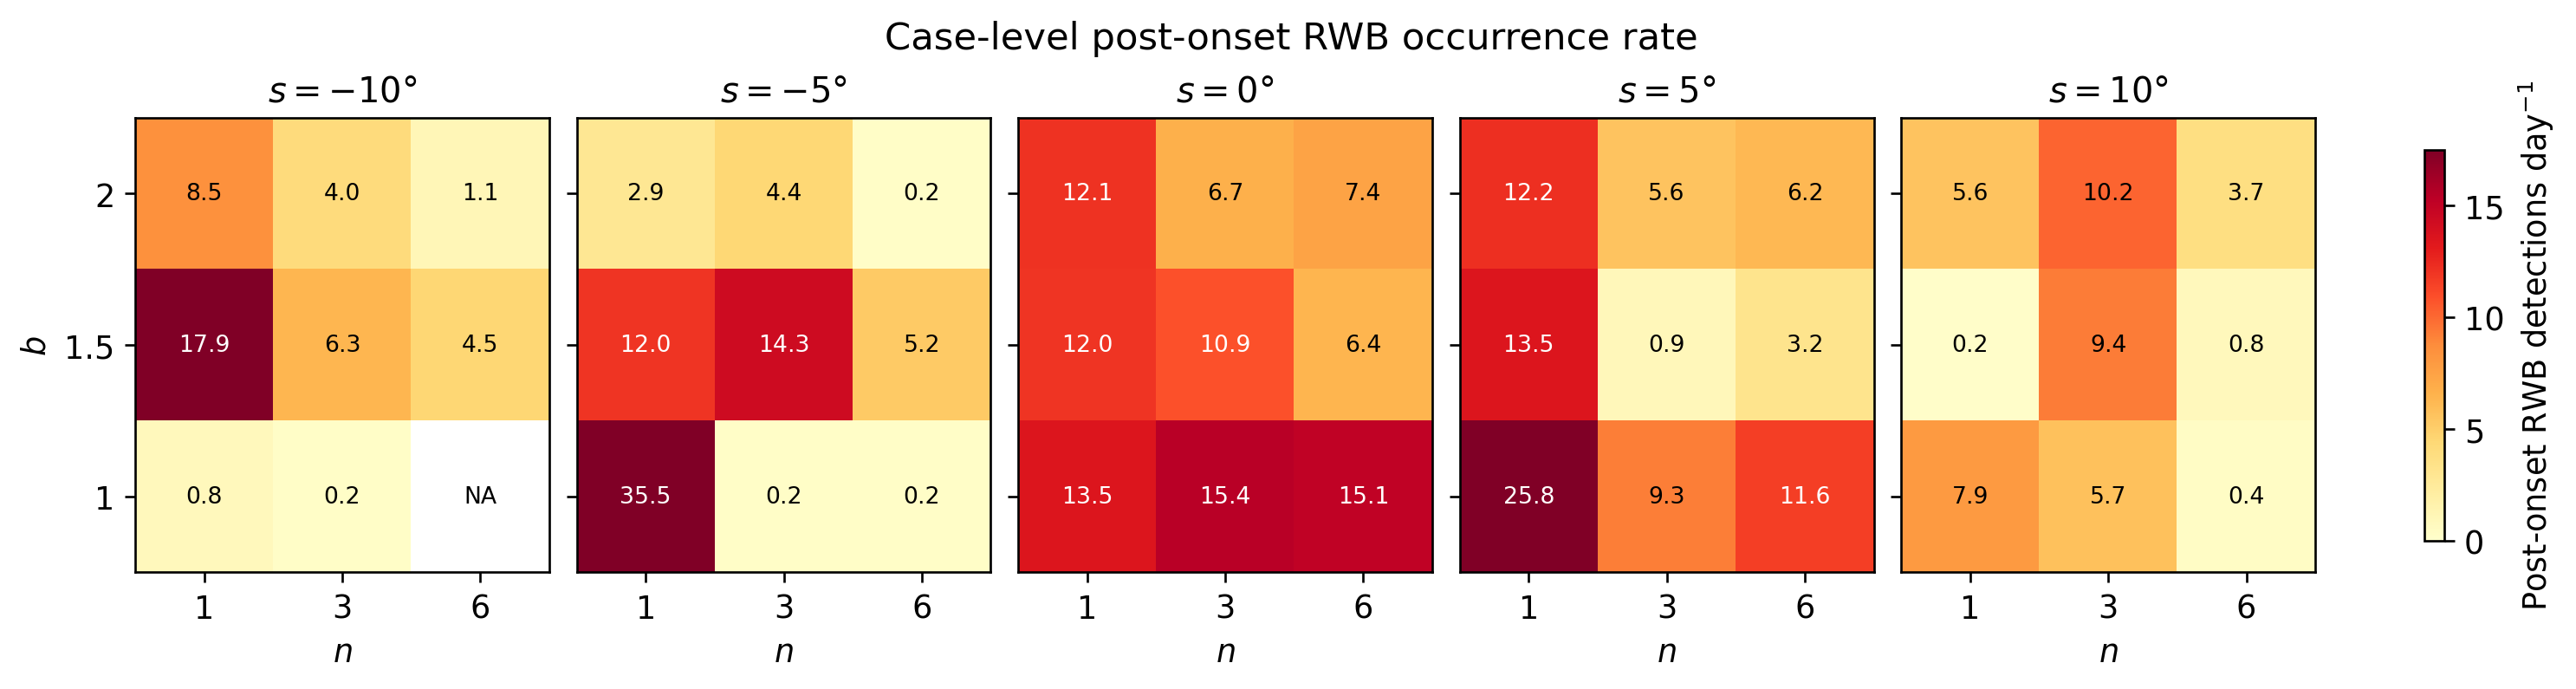

In [13]:
# Diagnostic stdout/stderr is hidden so saved notebook output contains only publication figures.
_diagnostic_output = io.StringIO()
_original_argv = sys.argv[:]
sys.argv = ['publication_notebook']
try:
    if REBUILD_FIGURES:
        with redirect_stdout(_diagnostic_output), redirect_stderr(_diagnostic_output):
            main()
finally:
    sys.argv = _original_argv
show_files(['eddy/rwb_post_onset_analysis_20260722/figures/rwb_full_post_onset_and_rate_by_parameters.png', 'eddy/rwb_post_onset_analysis_20260722/figures/rwb_post_onset_rate_heatmaps.png'])
